# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


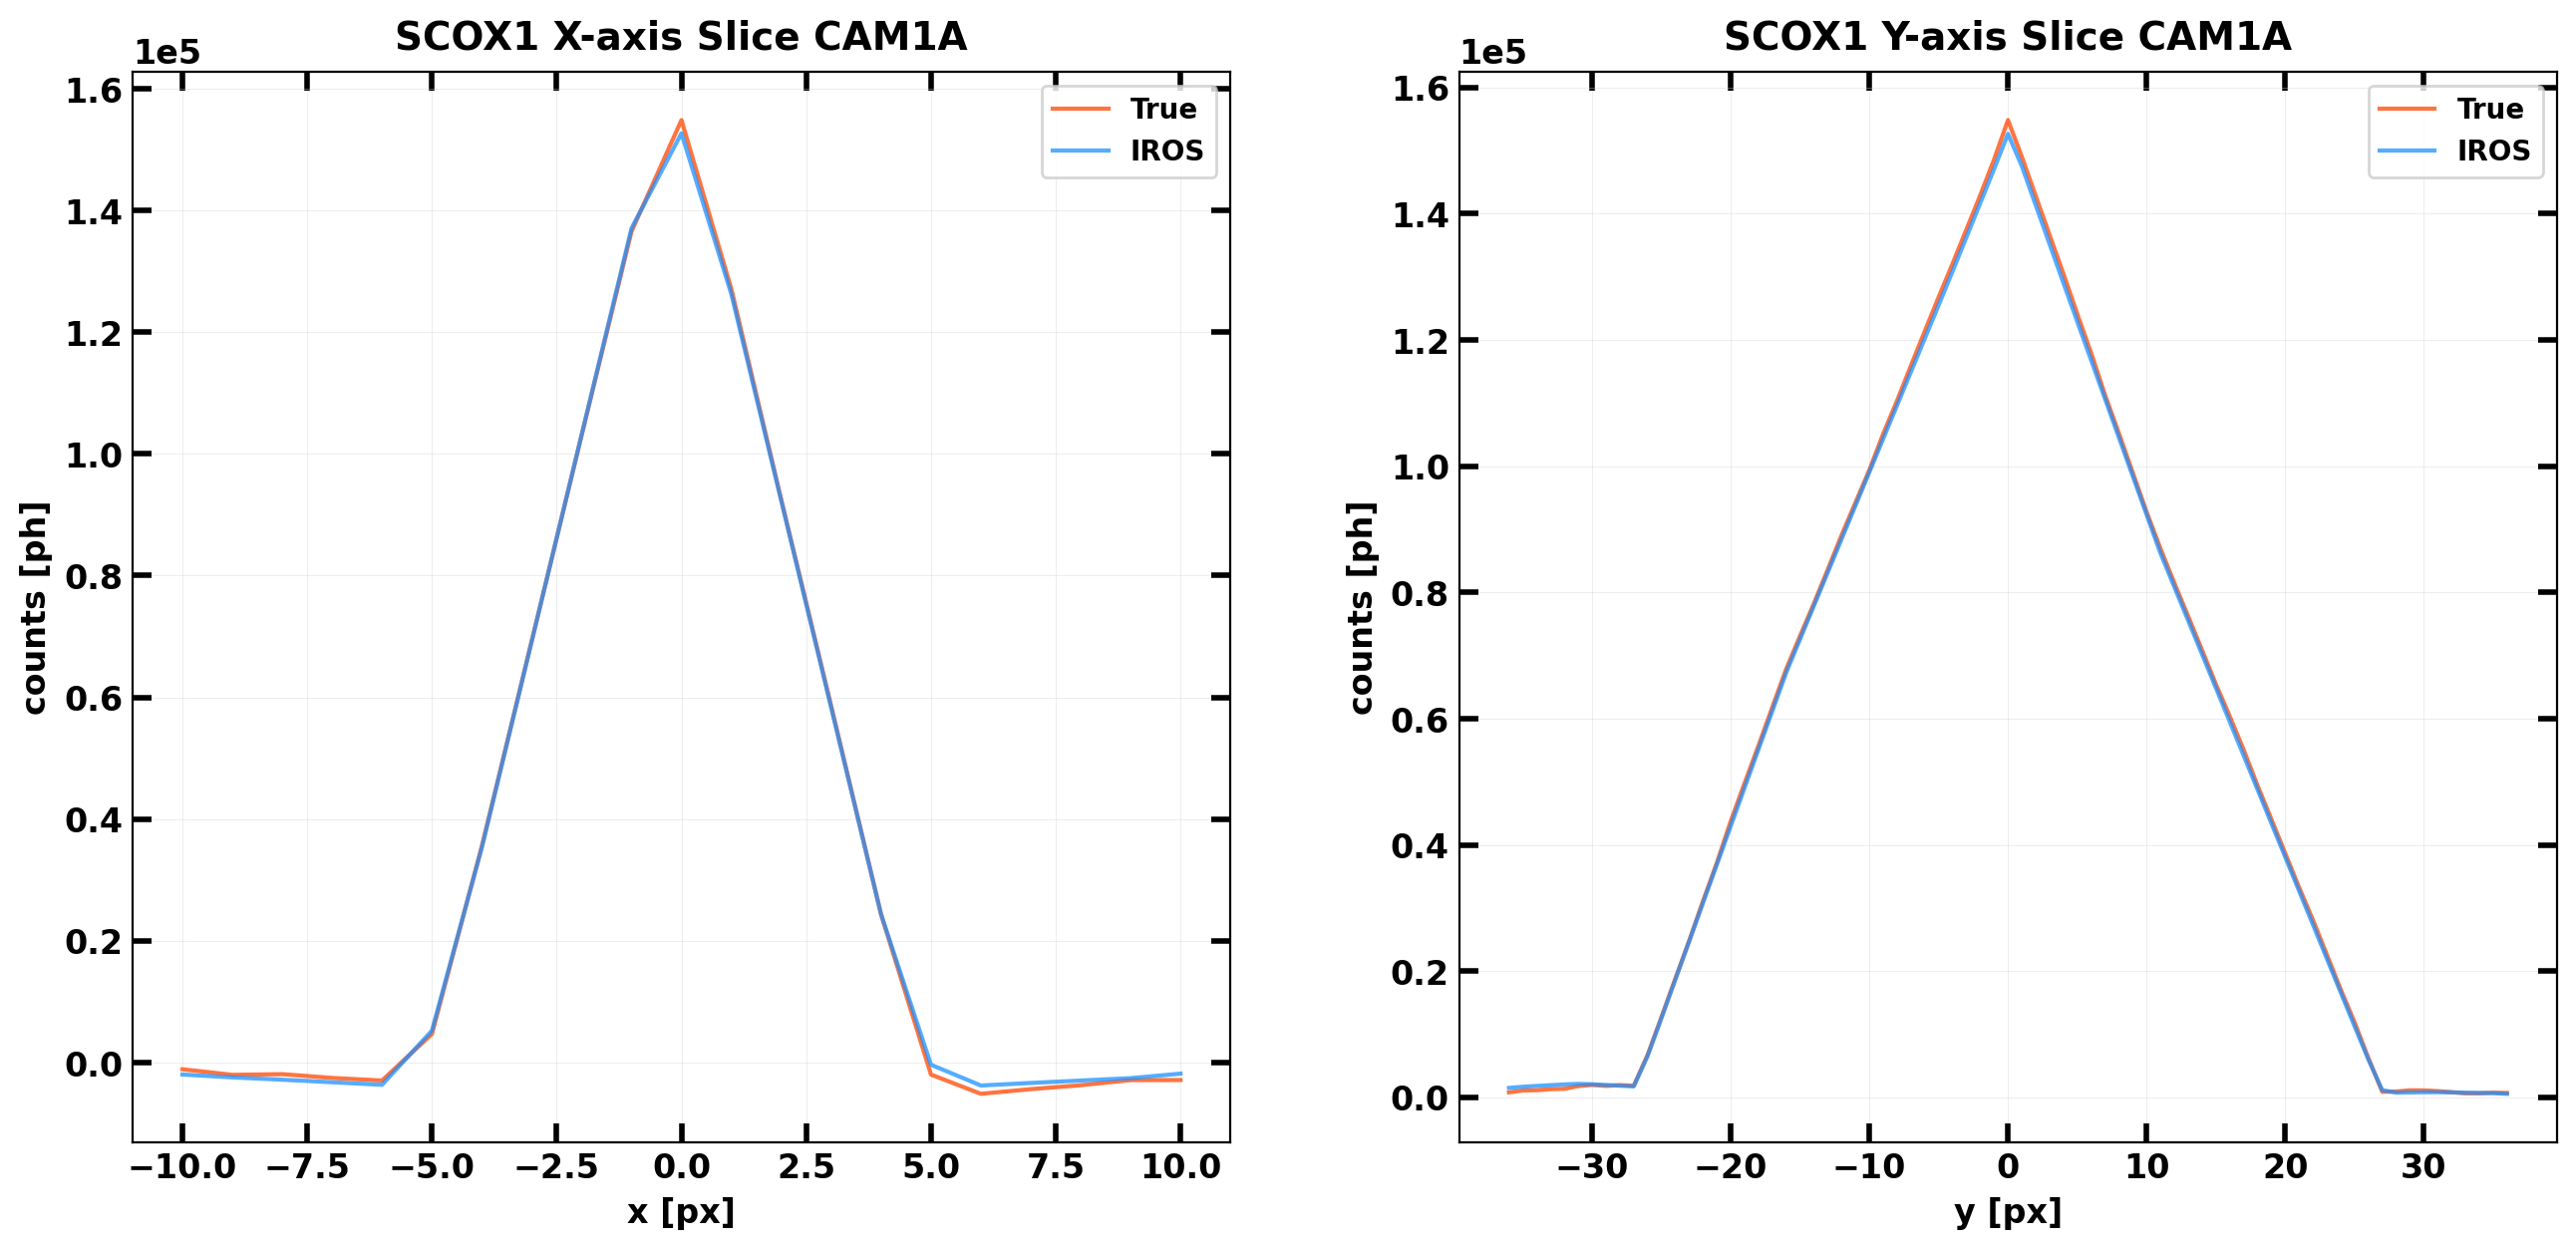

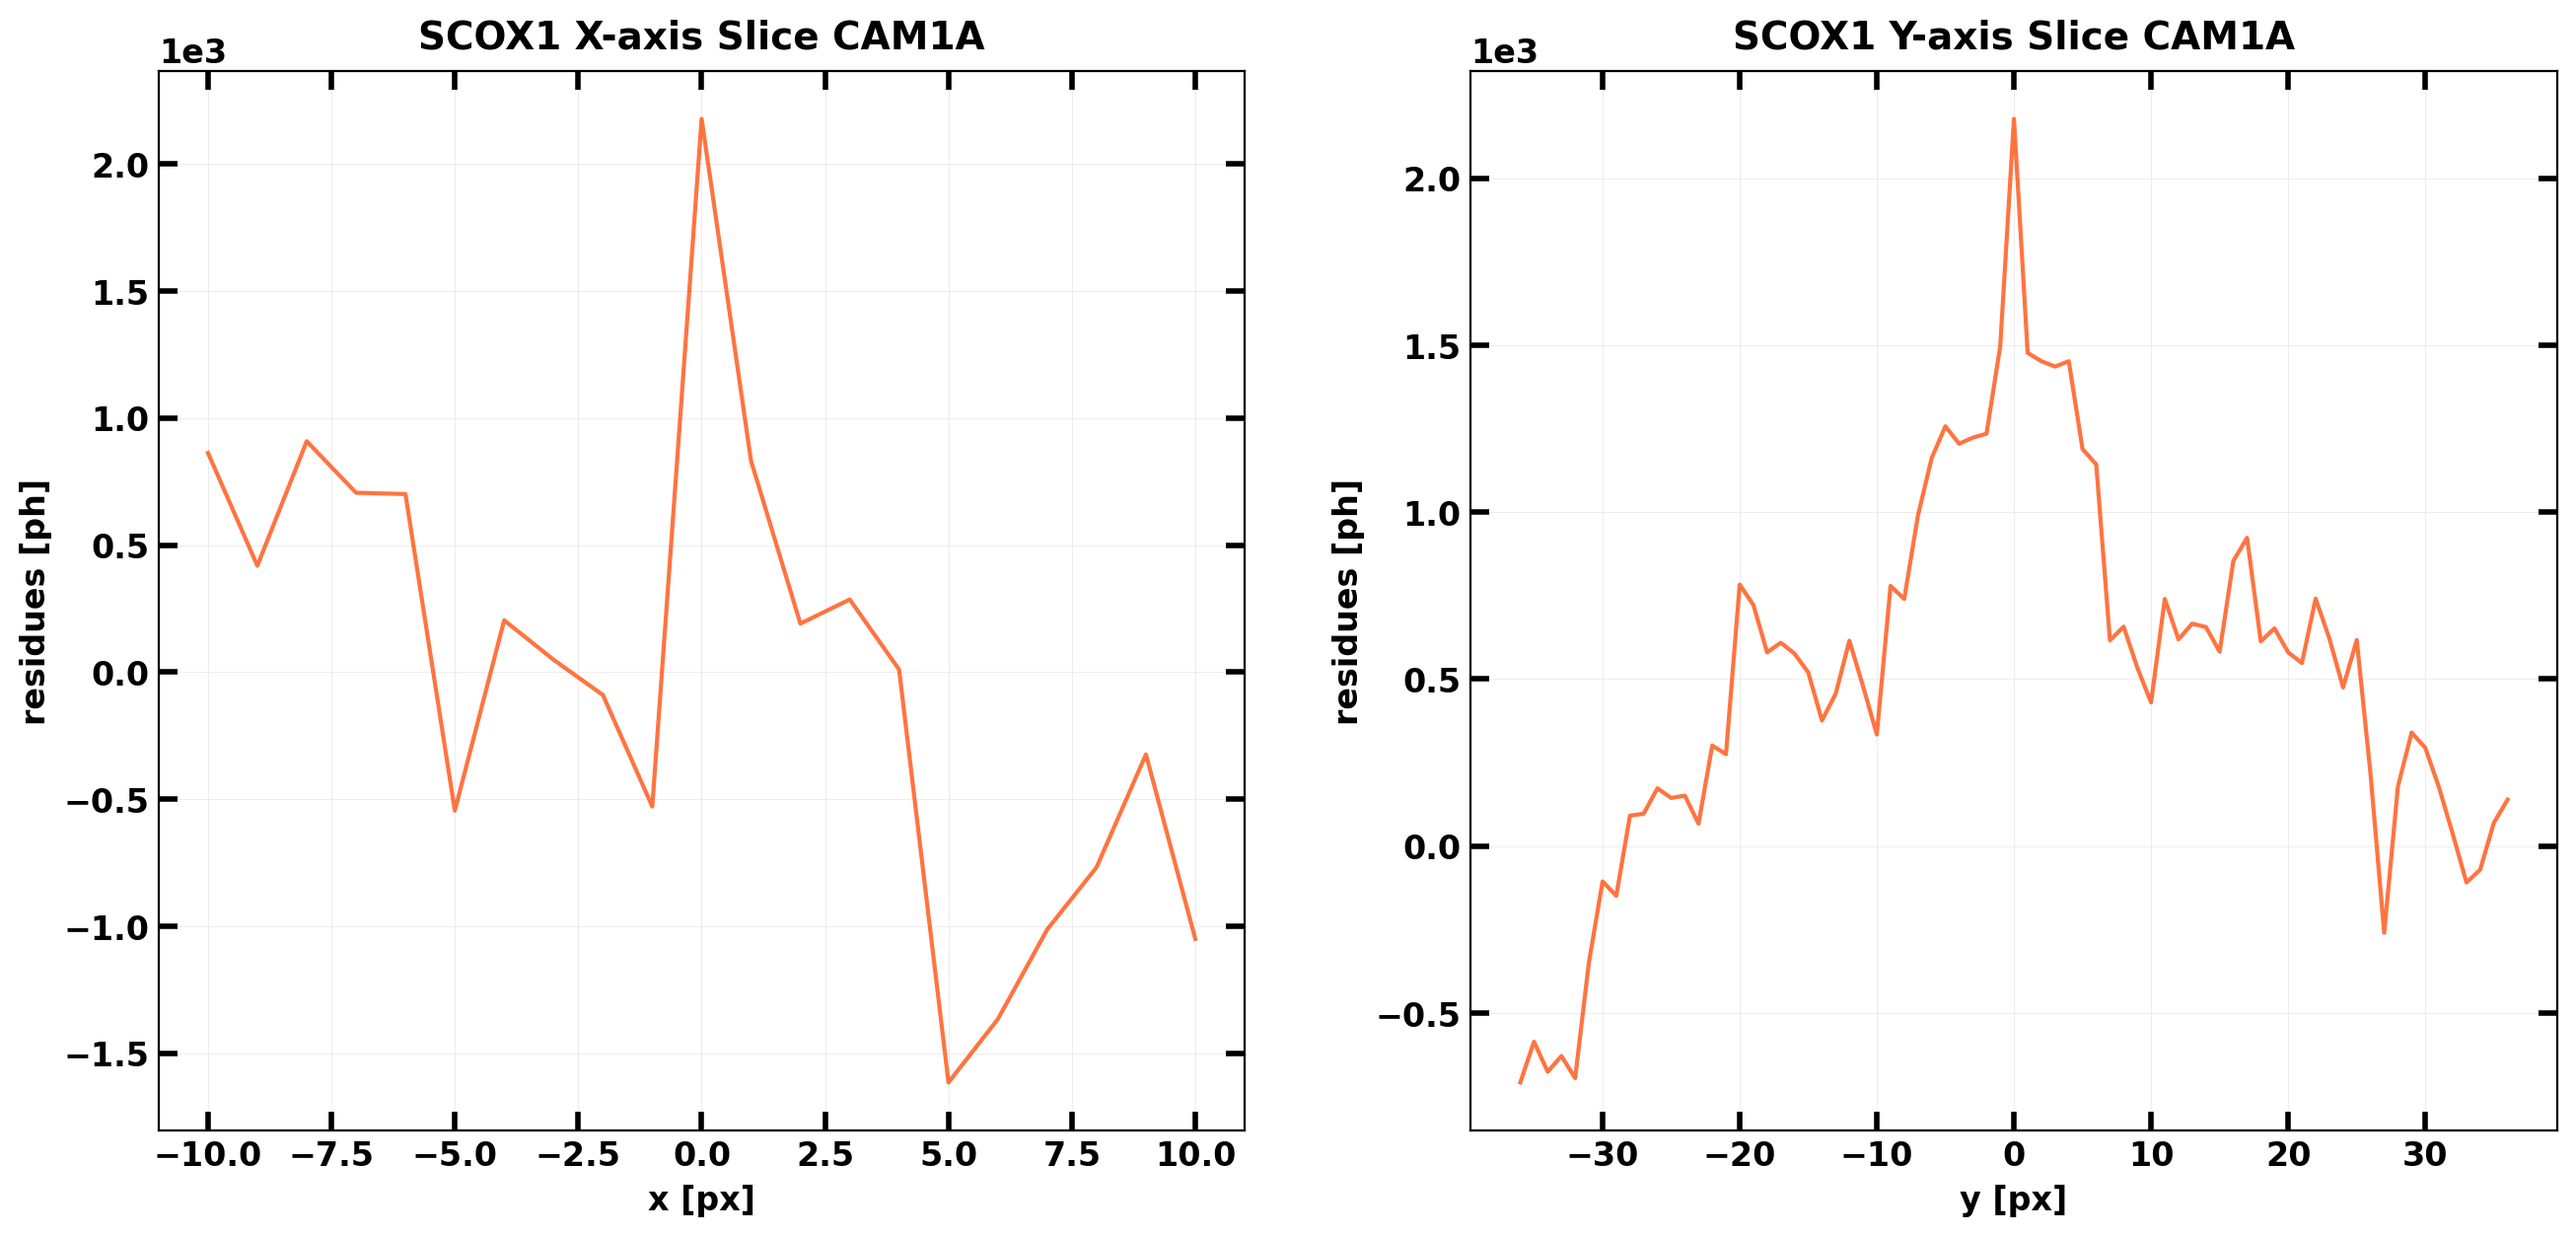

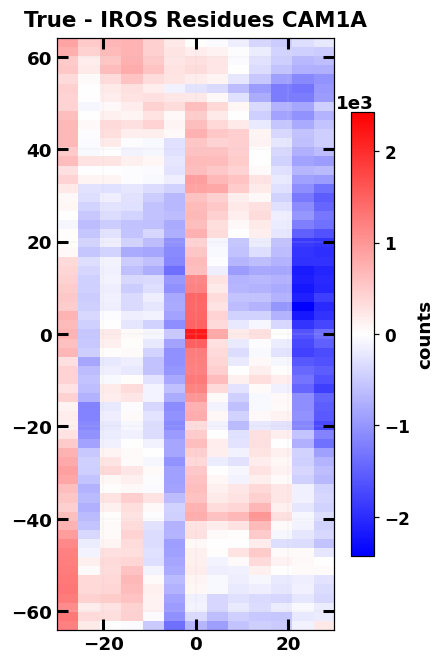

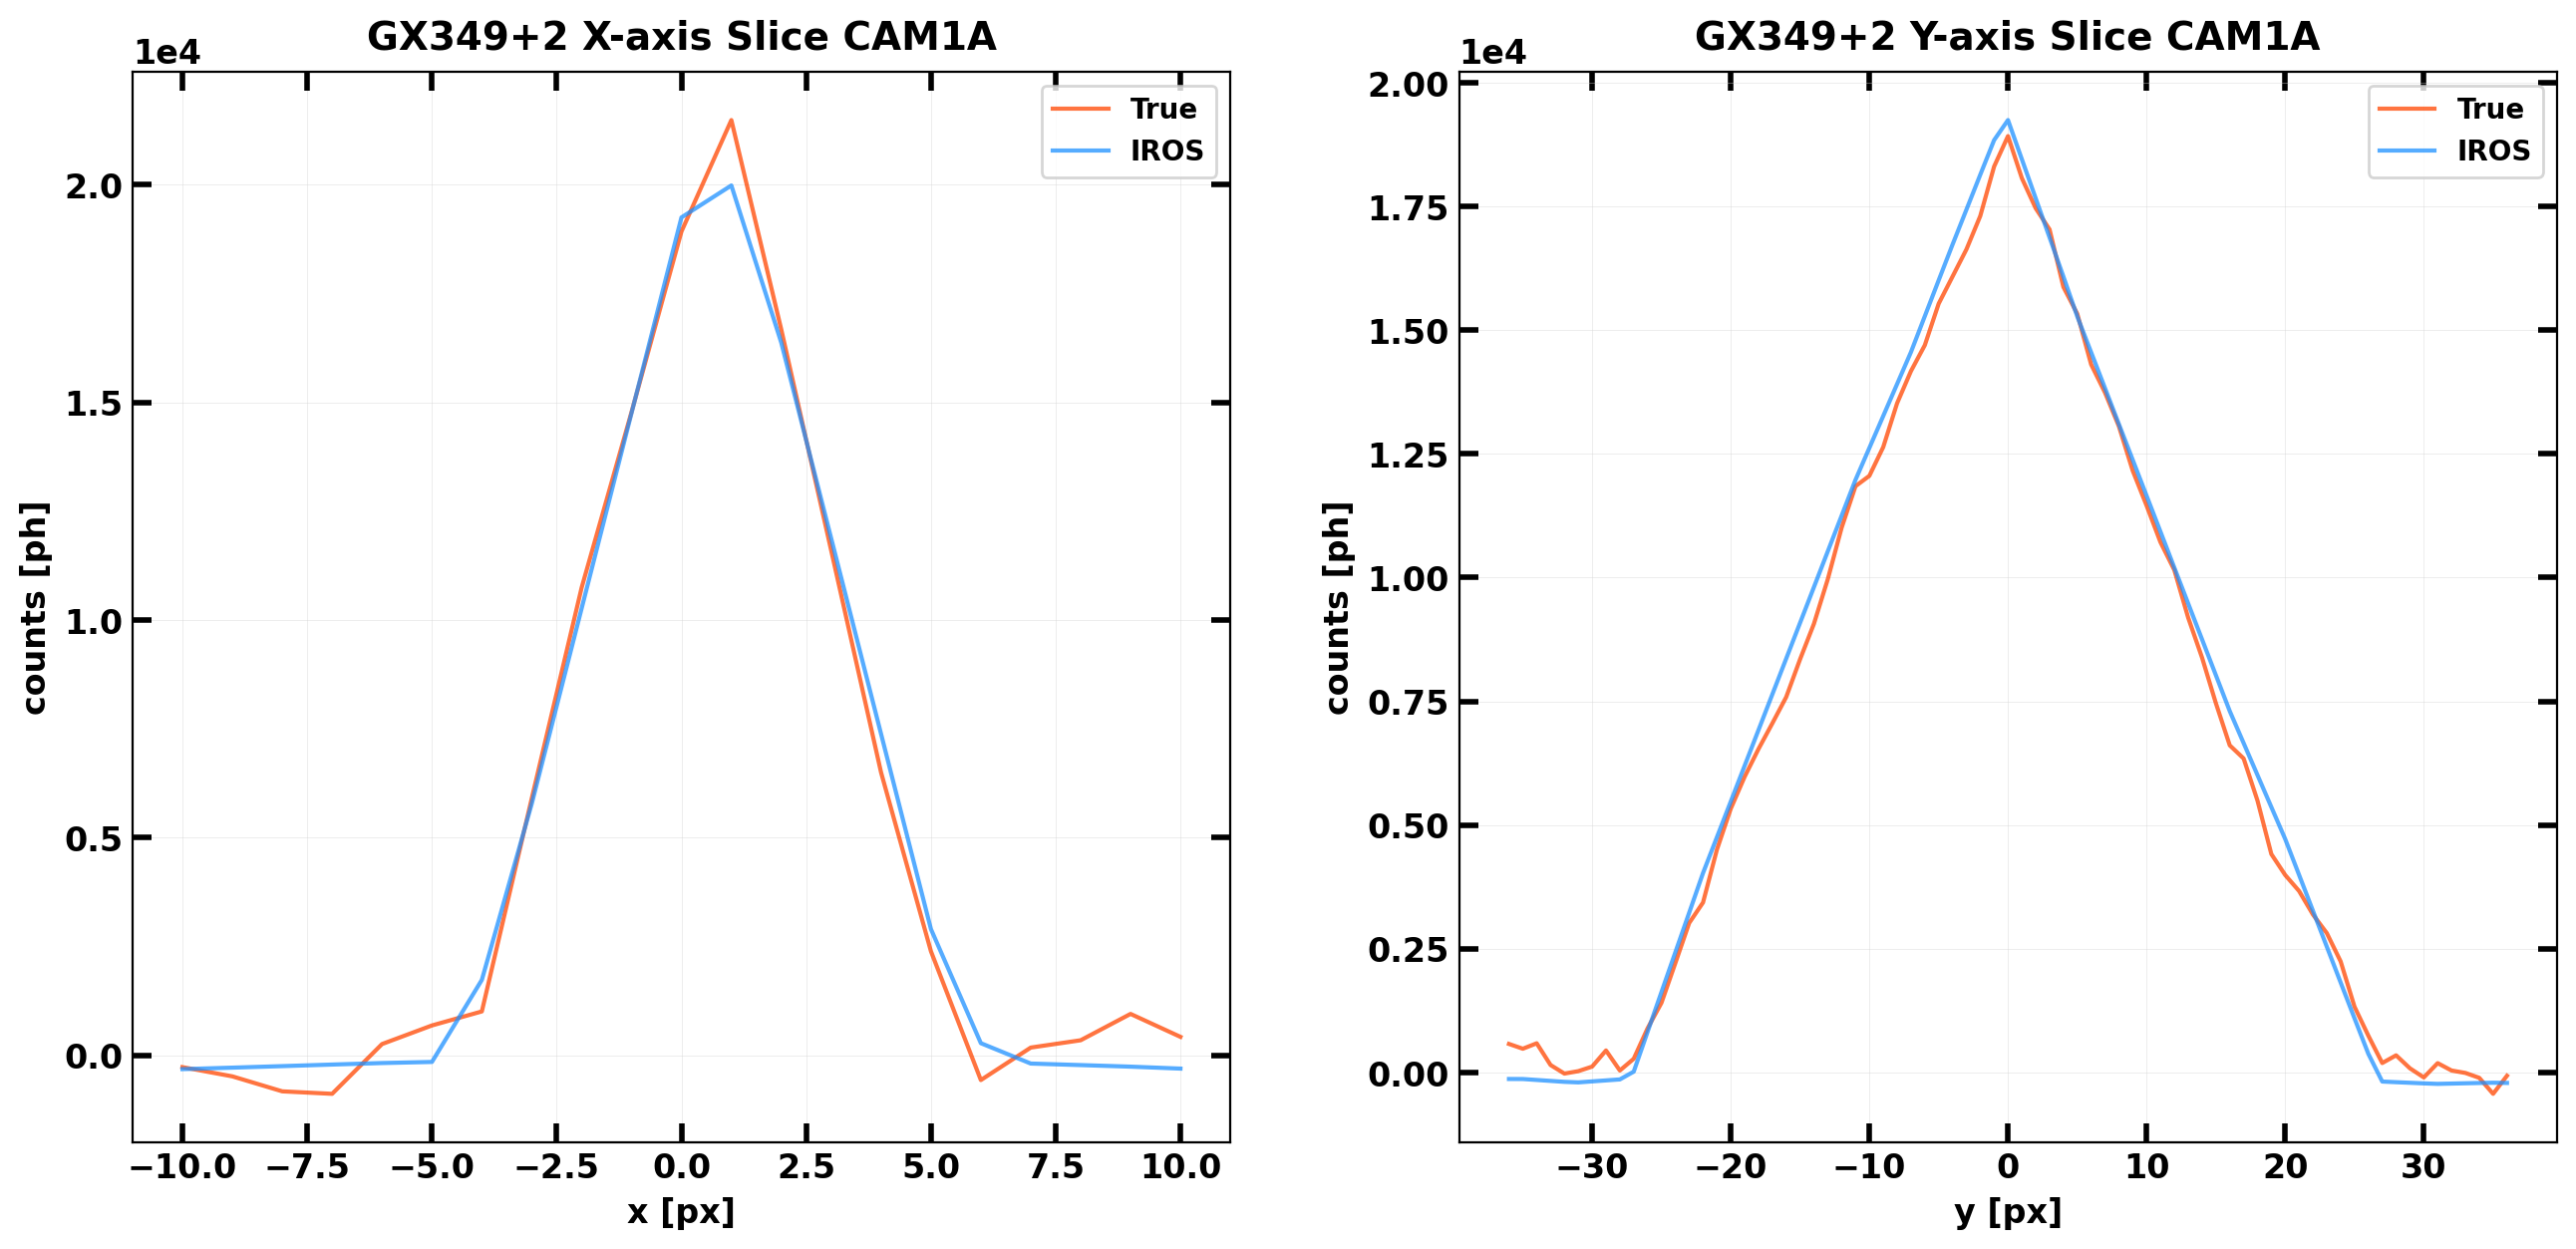

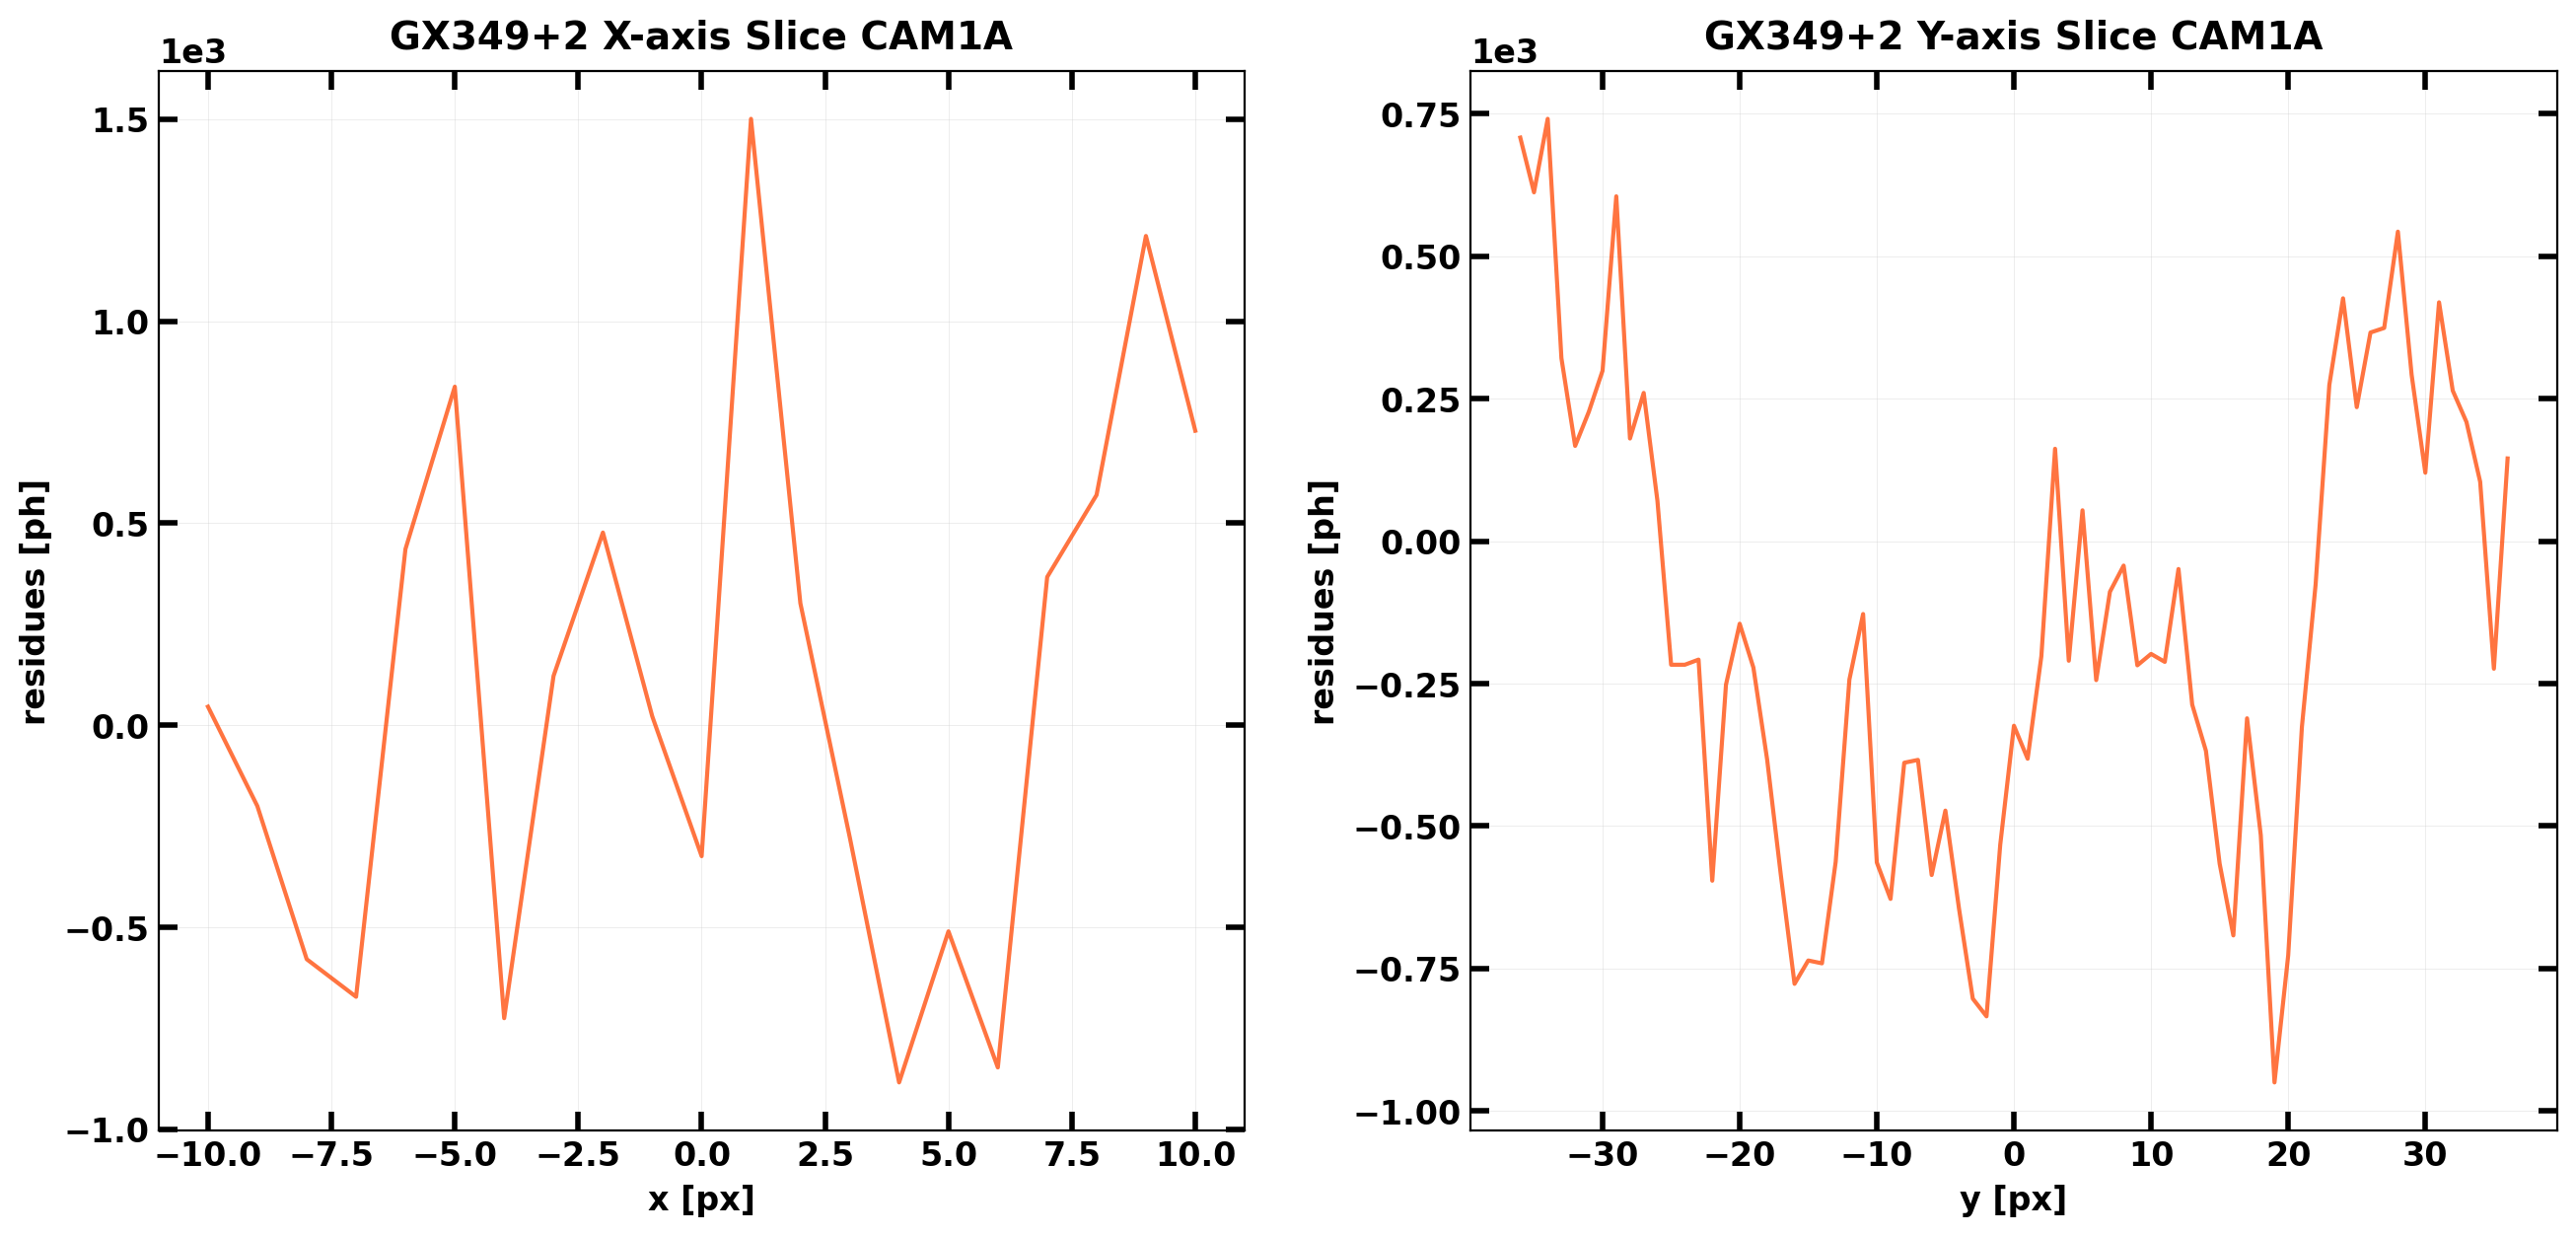

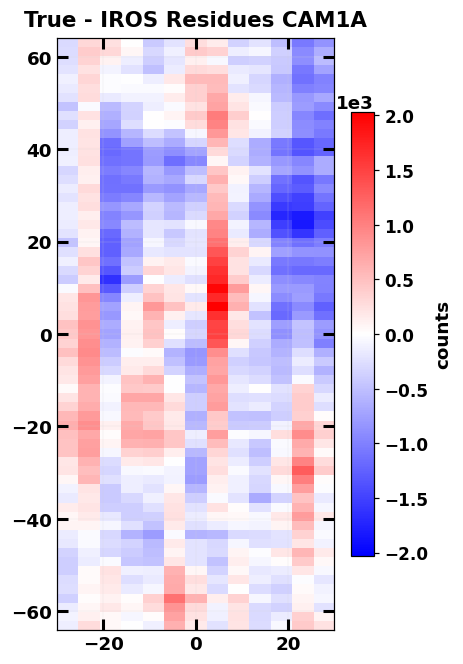

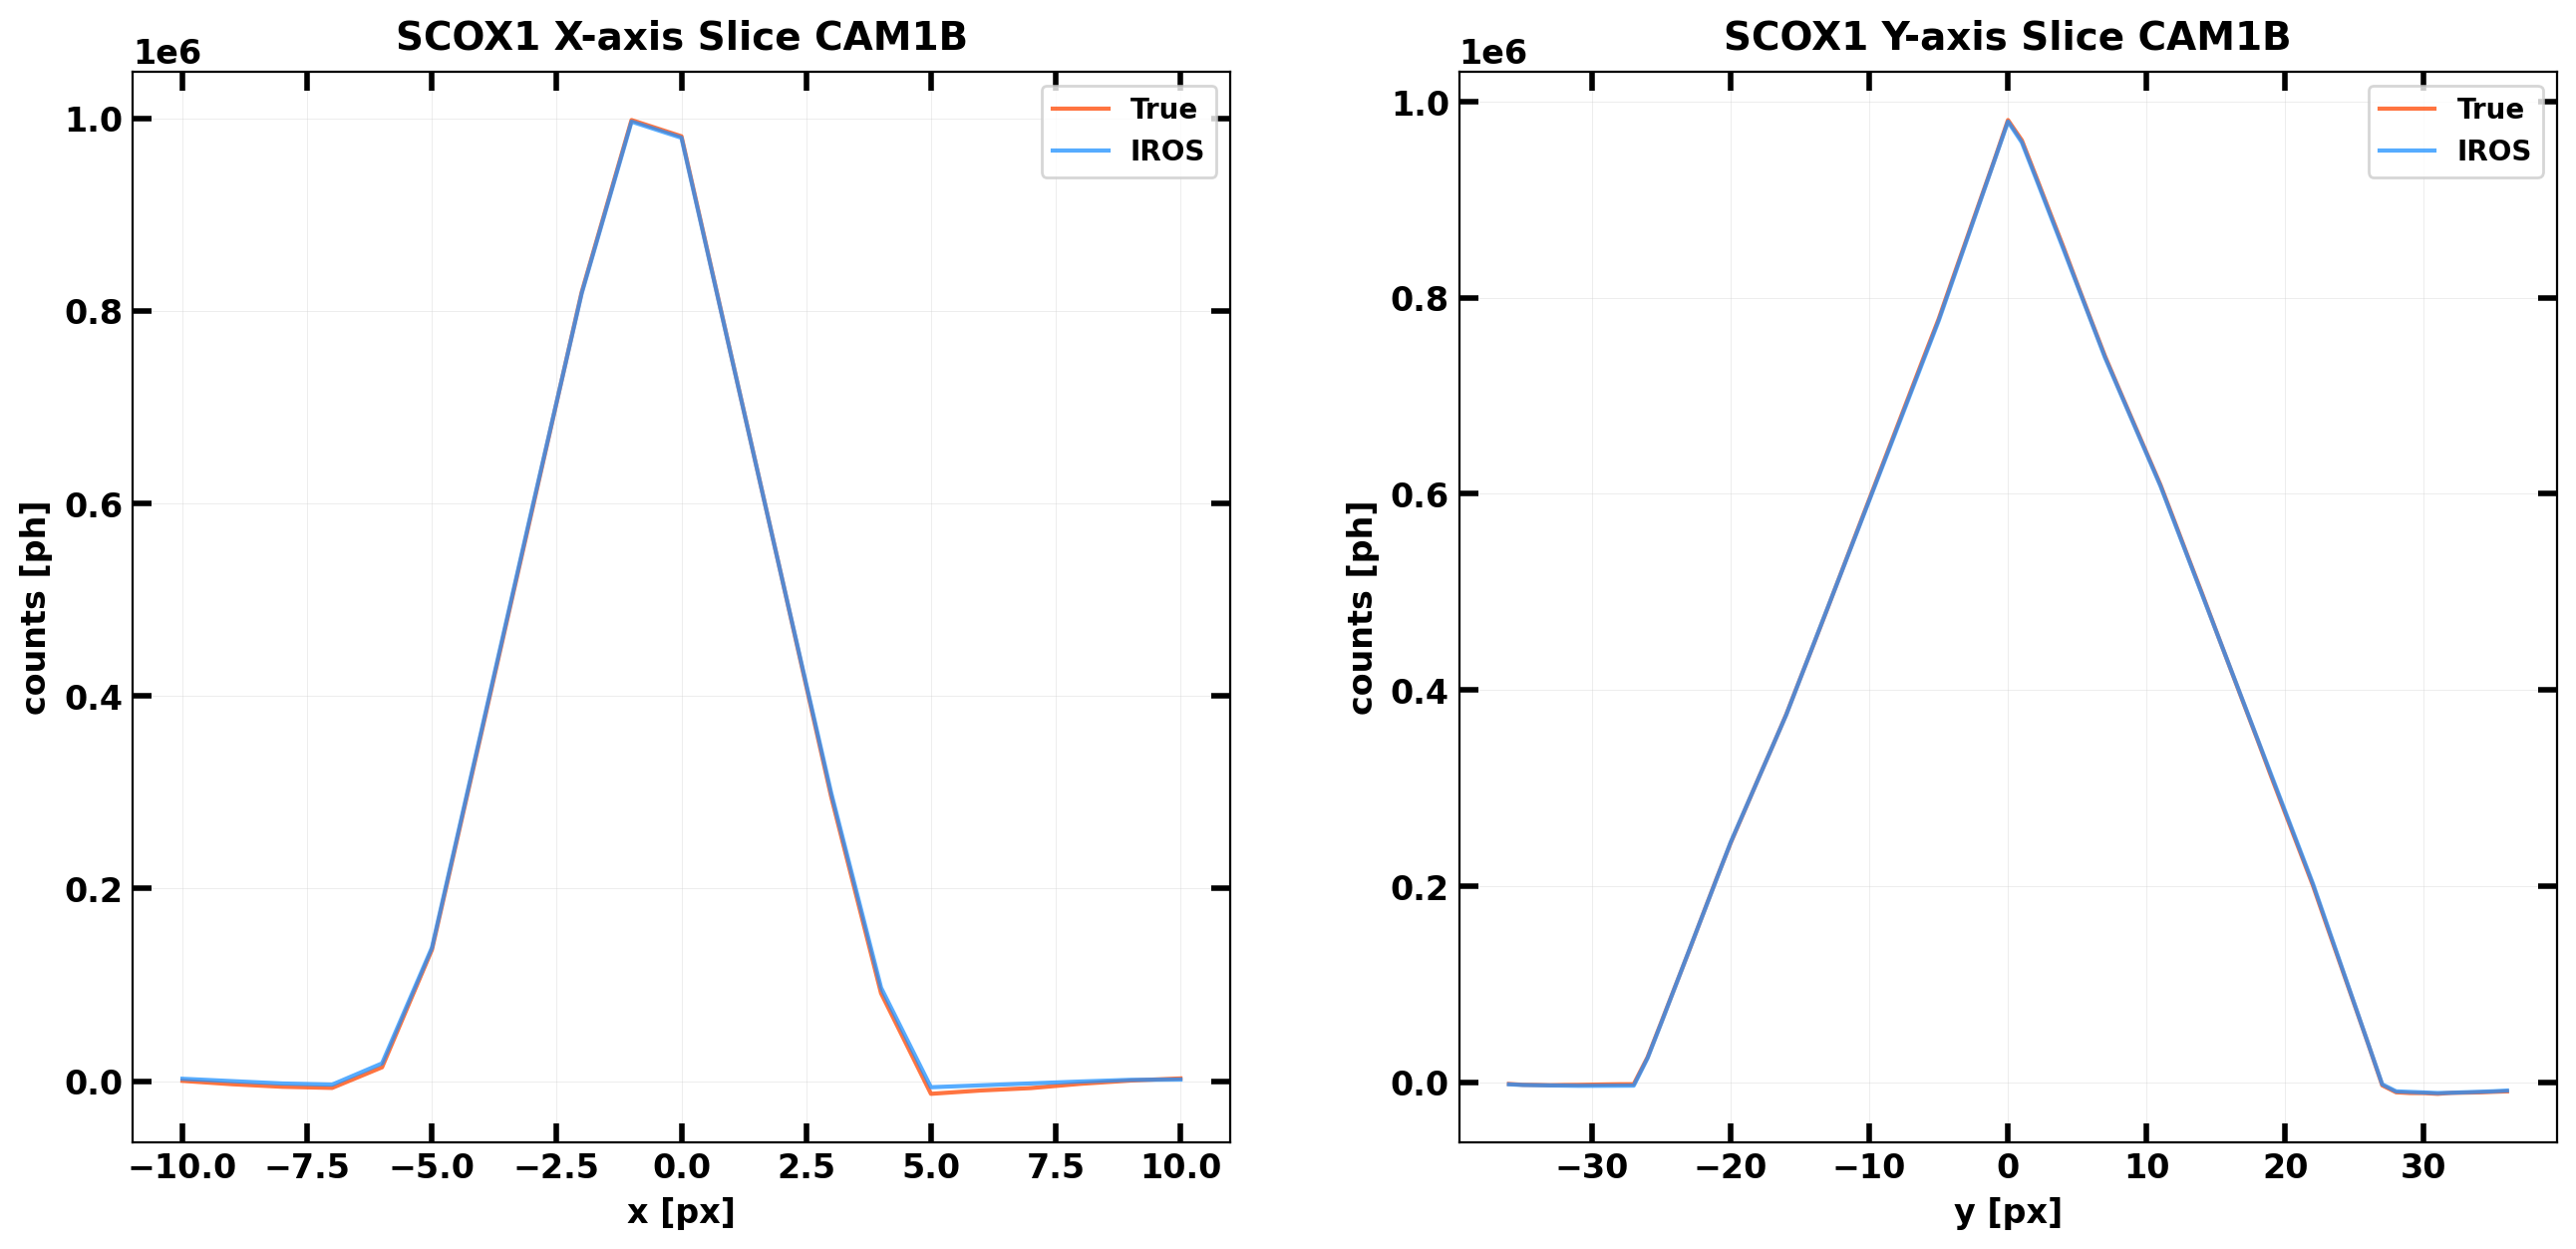

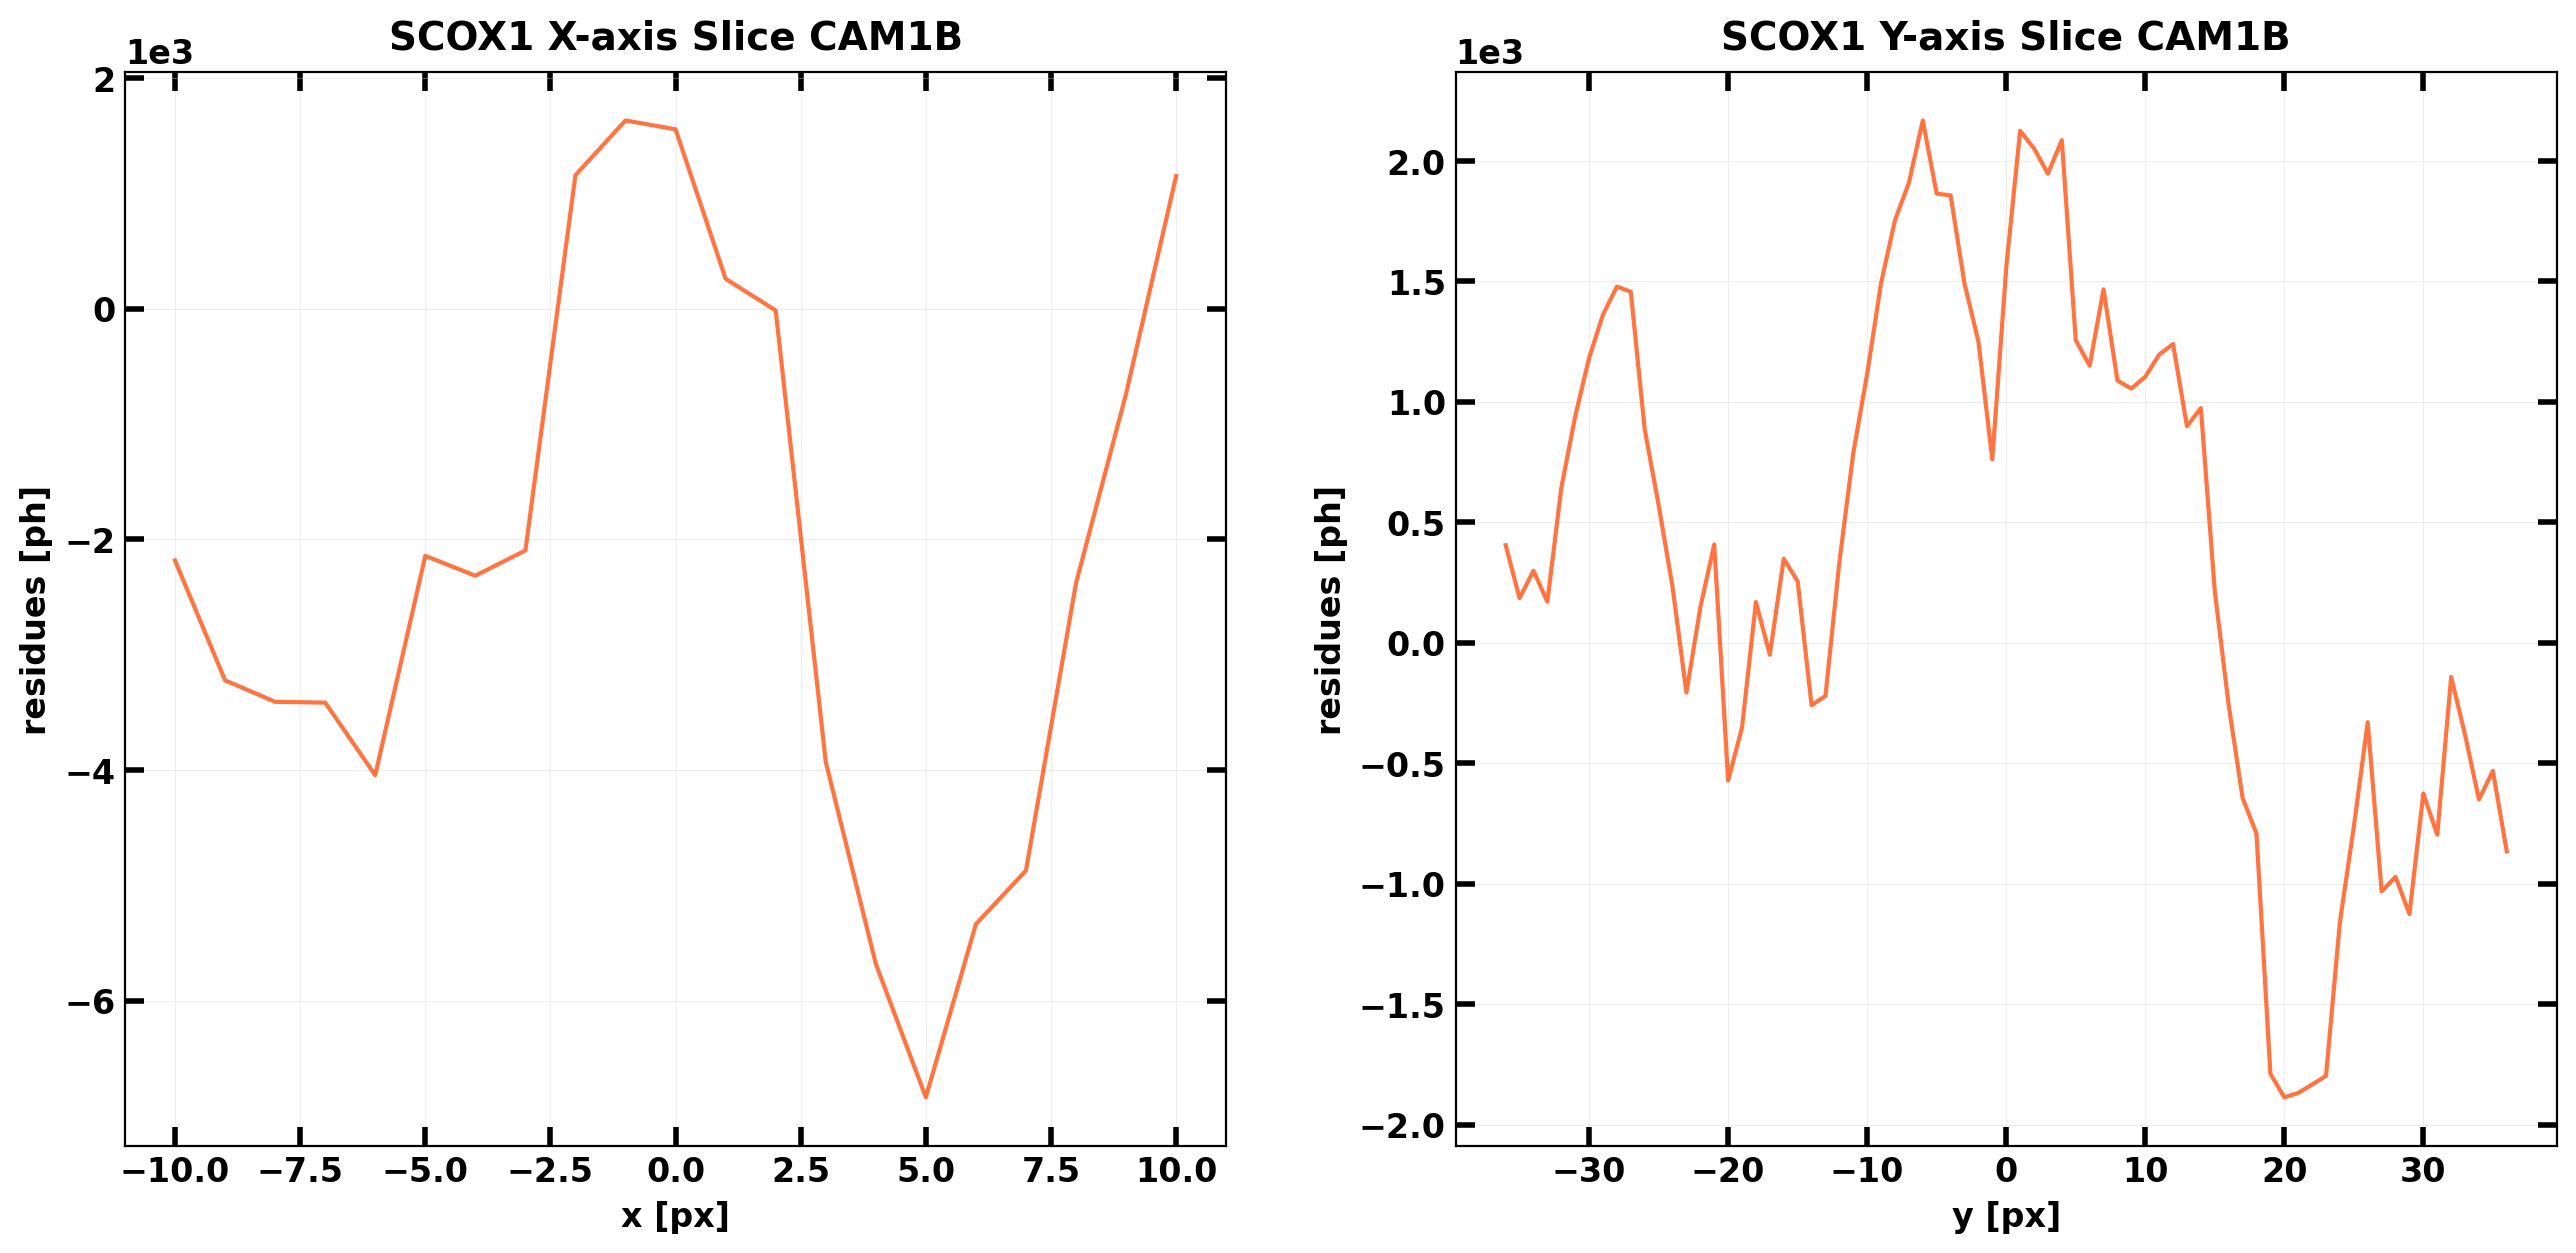

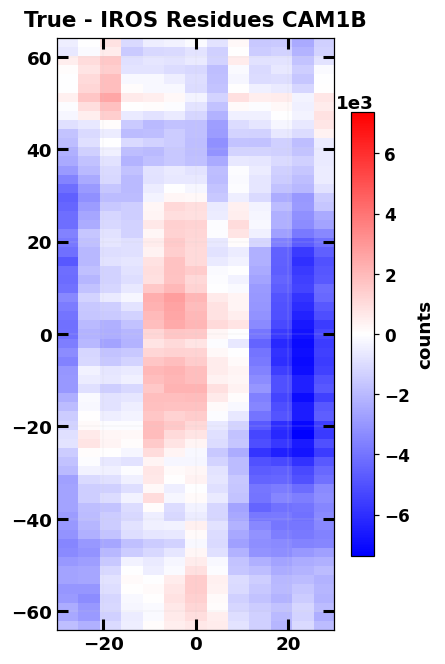

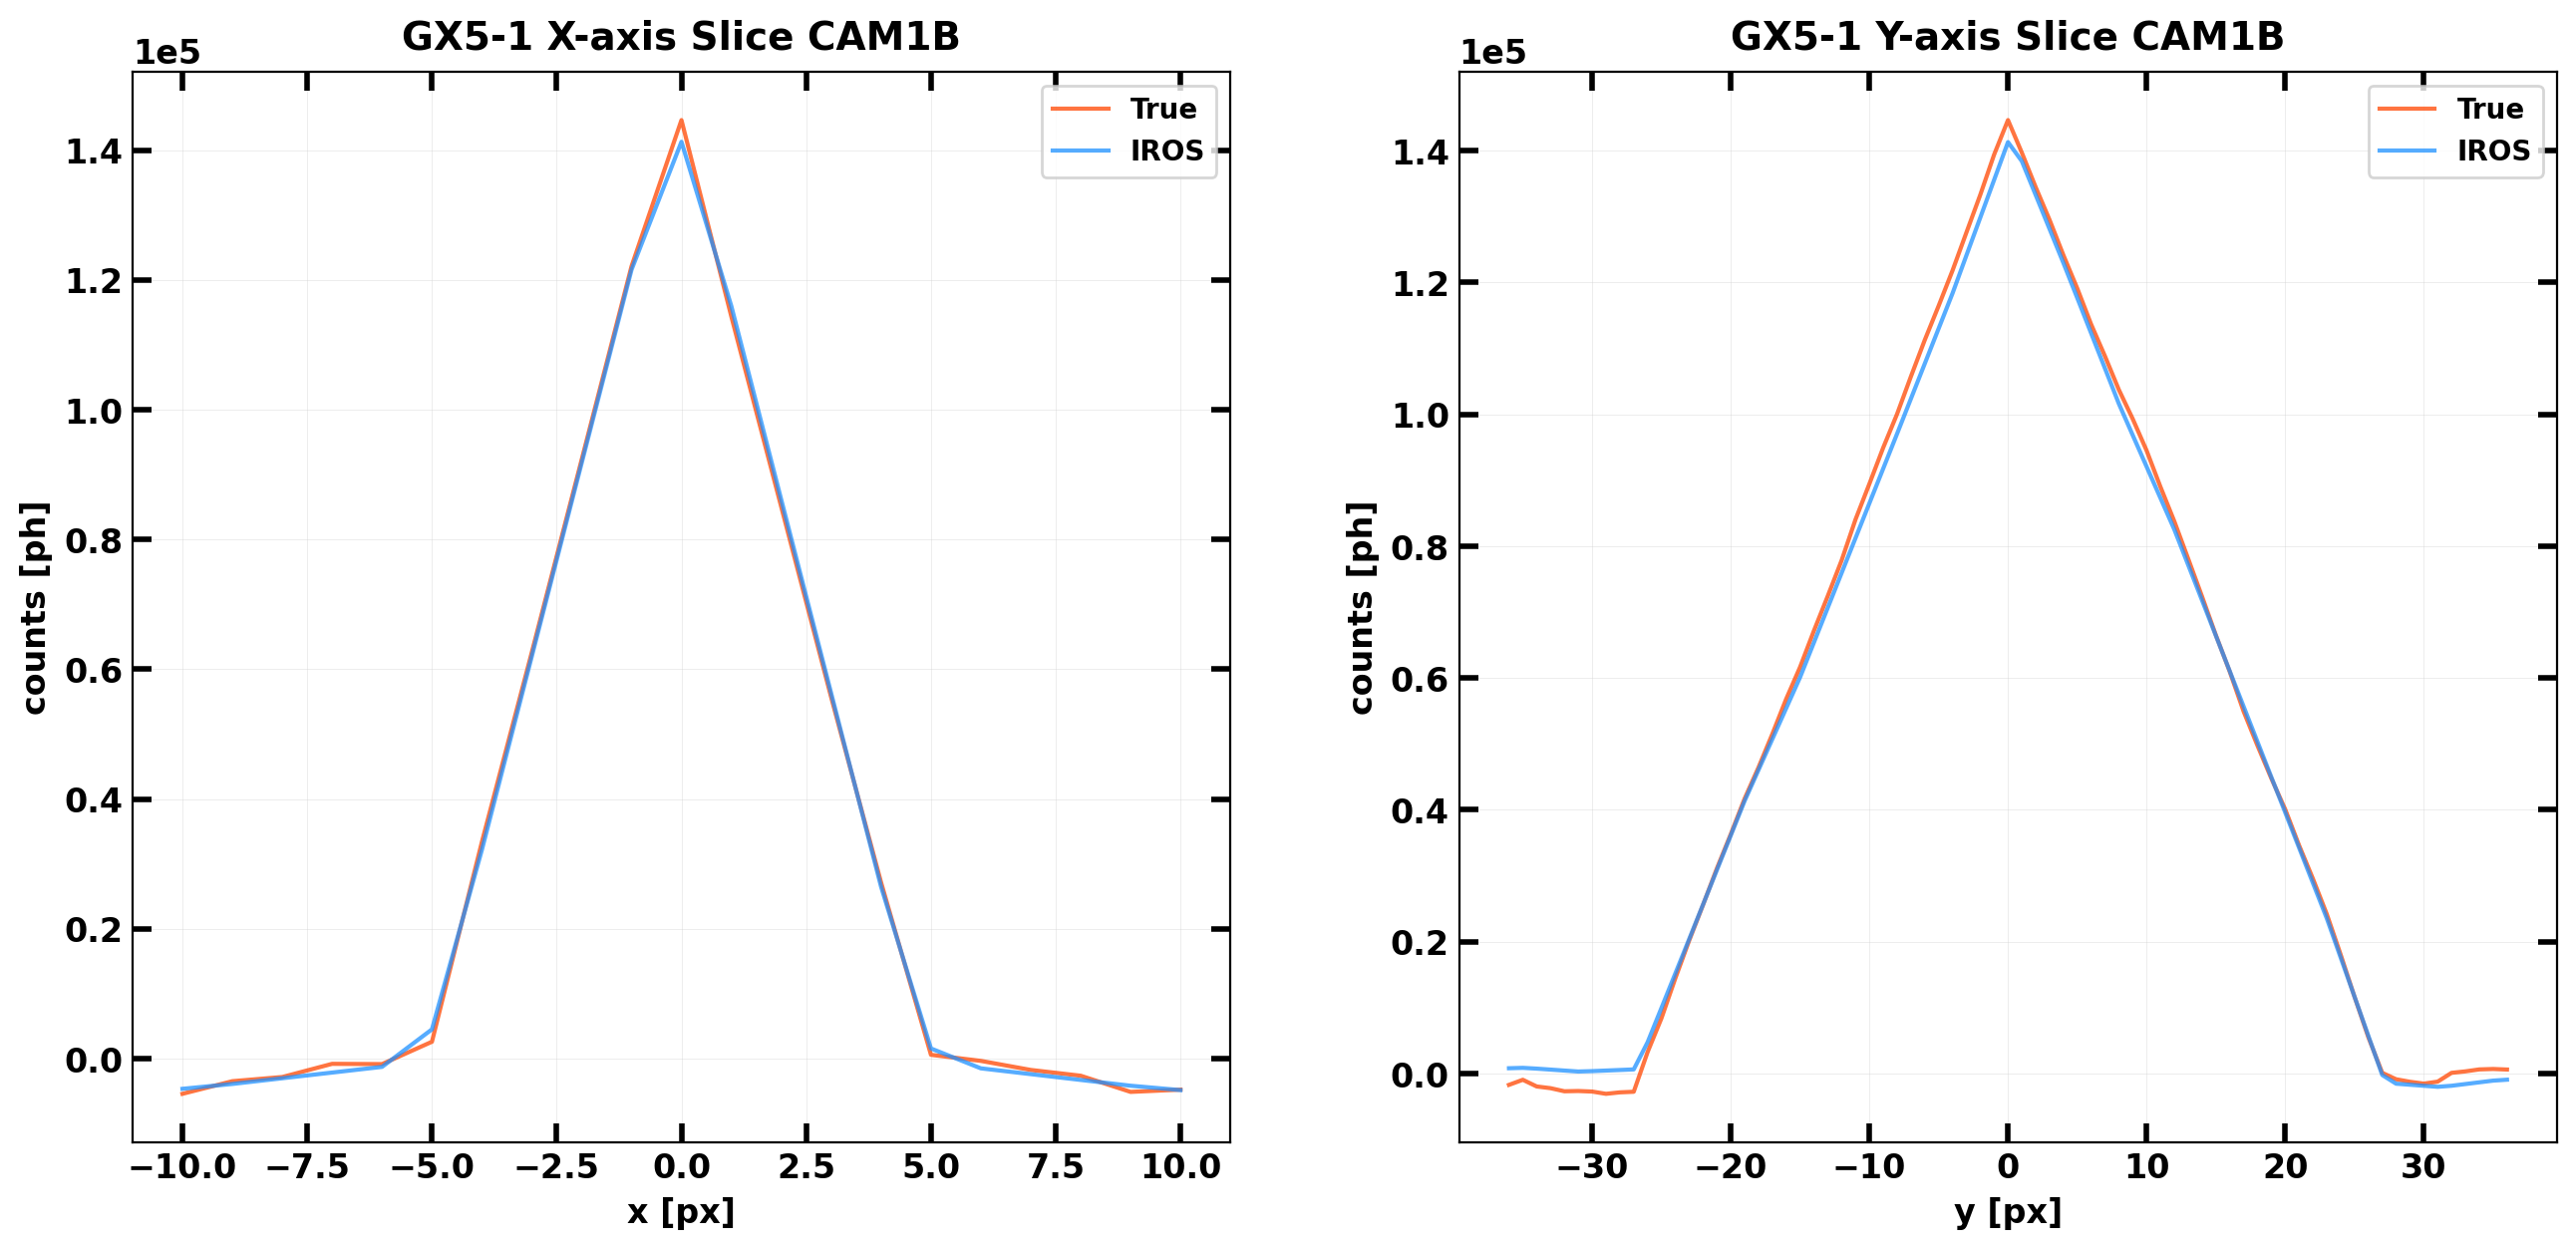

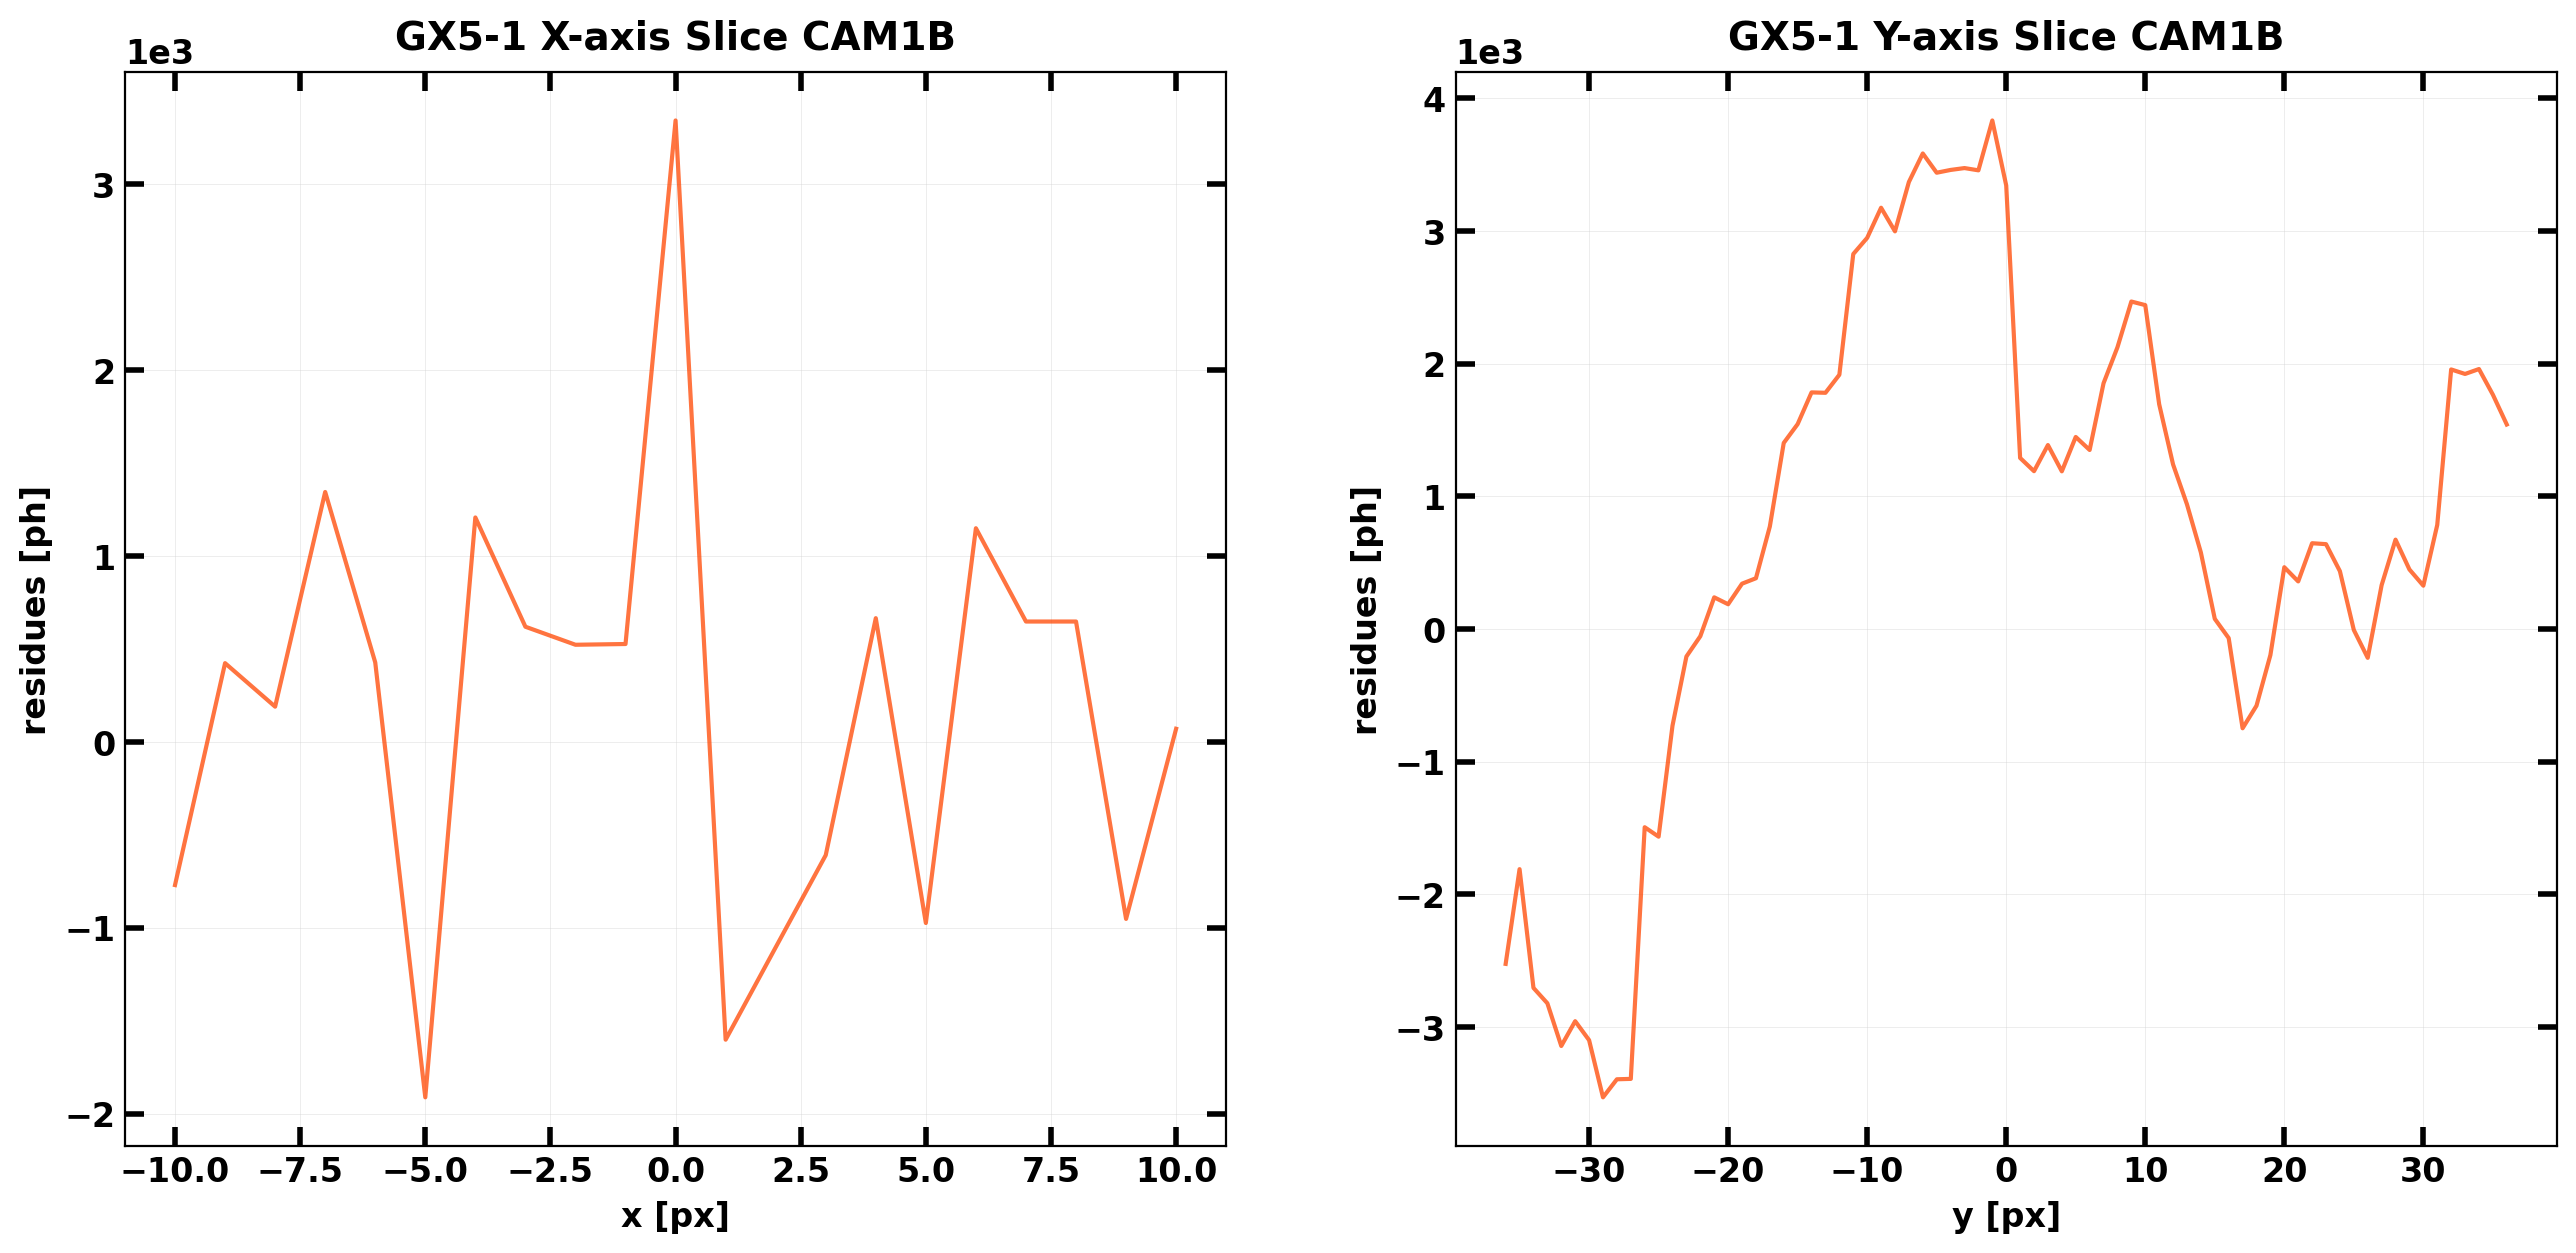

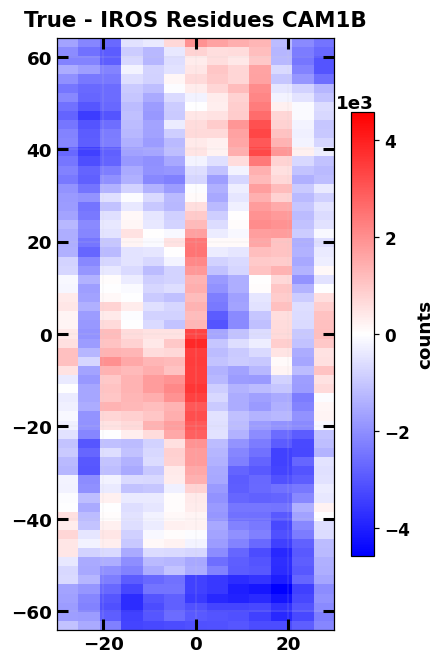

In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths
from bloodmoon.mask import codedmask
import darksun as ds


skyfield = "GalacticCentre"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_opaquemask_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing_optimizerNoPeak"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

#filepaths = simulation_files(simul_data)
#sdlA = ds.get_data(filepaths[cam_a][dataset])
#catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=crp,
    camera=wfm,
    vignetting=True,
    psfy=False,
    #savepath=is_img,
)
ds.reconstruction_plot(
    true_sky=simul_sky_camB,
    log=log_camB,
    crp=crp,
    camera=wfm,
    vignetting=True,
    psfy=False,
    #savepath=is_img,
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


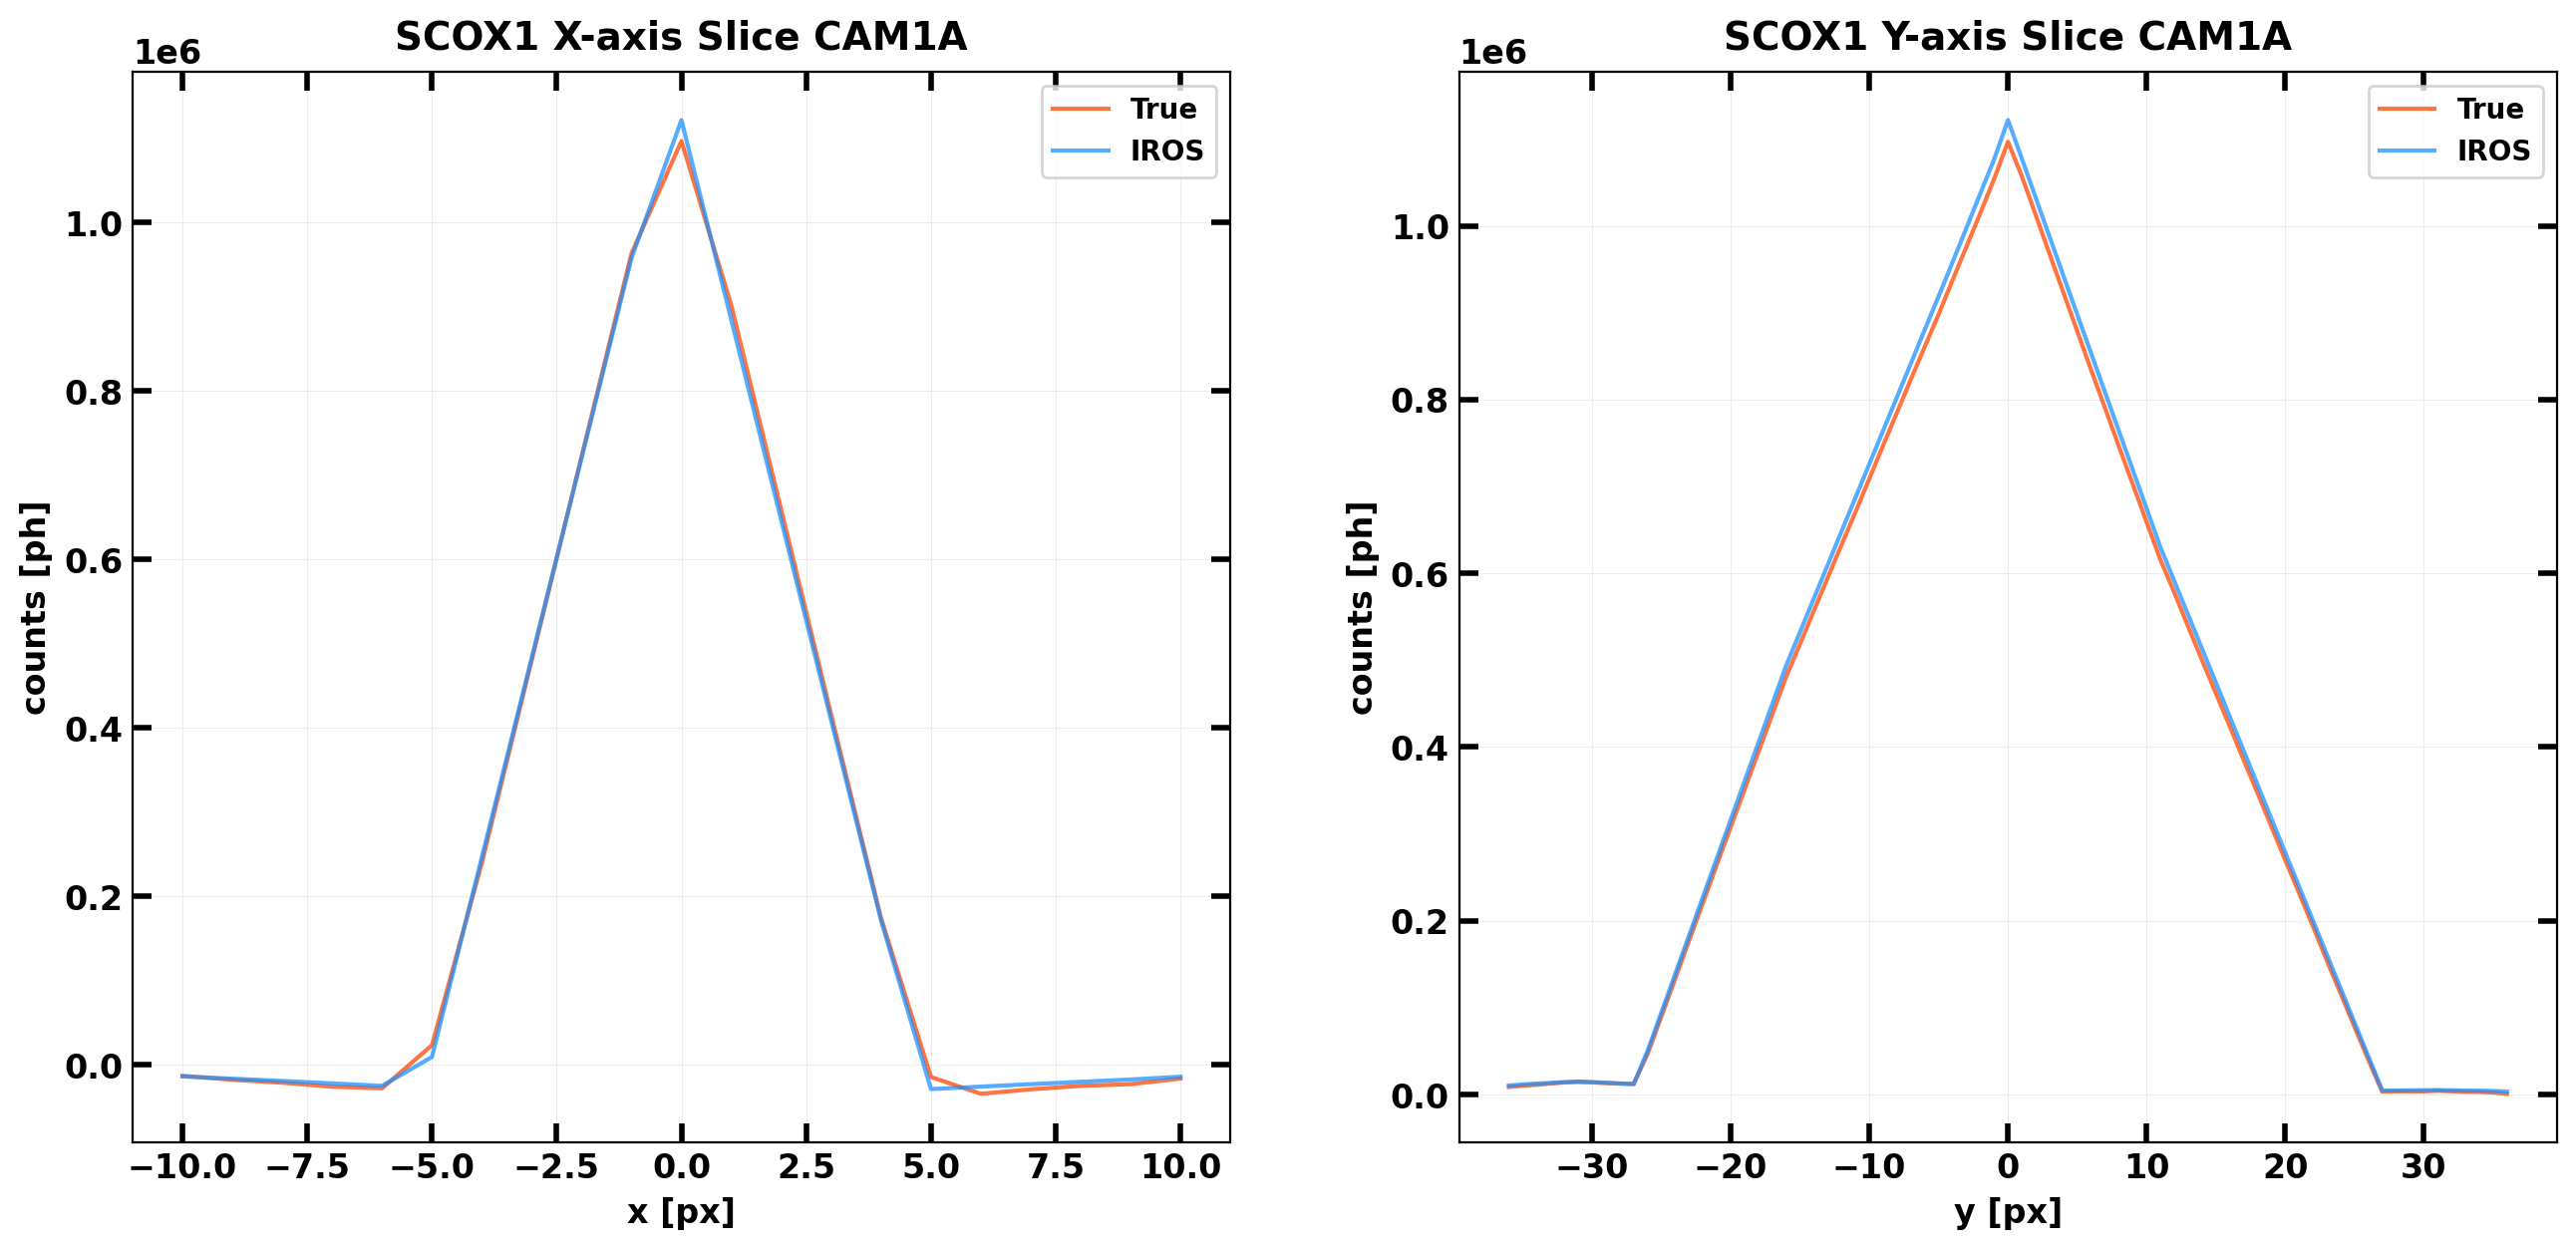

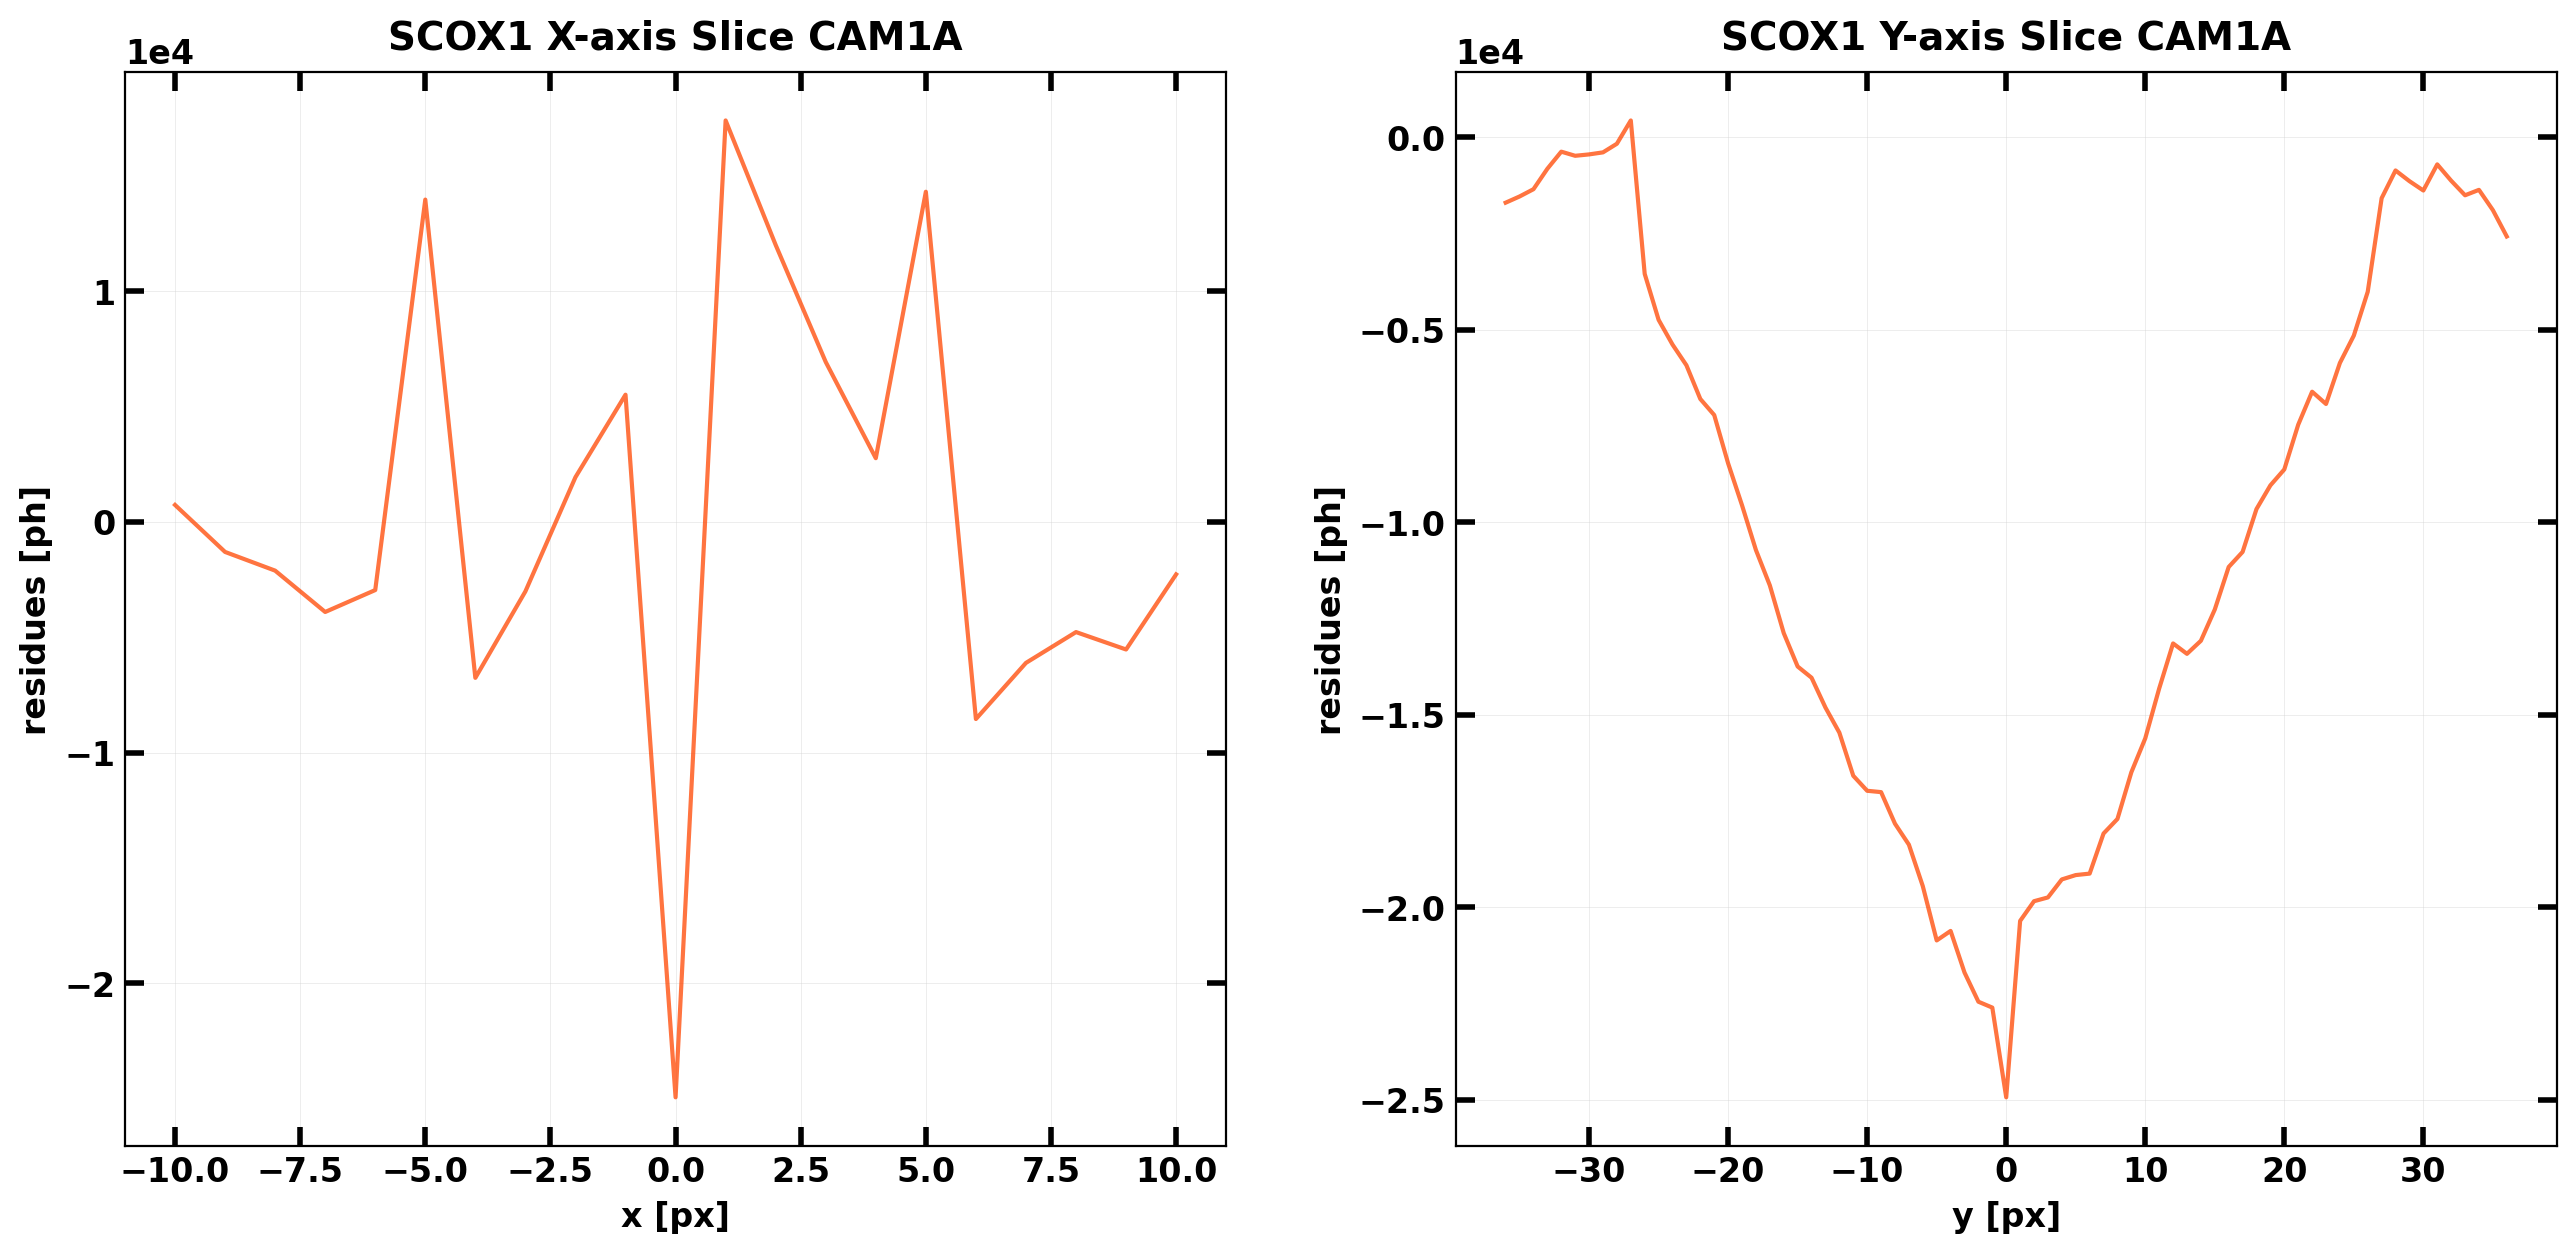

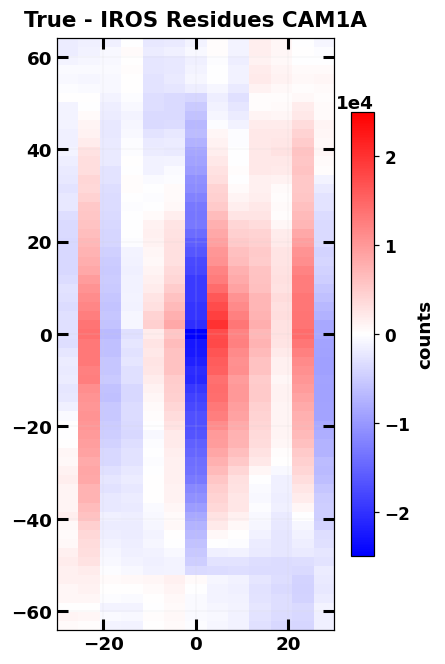

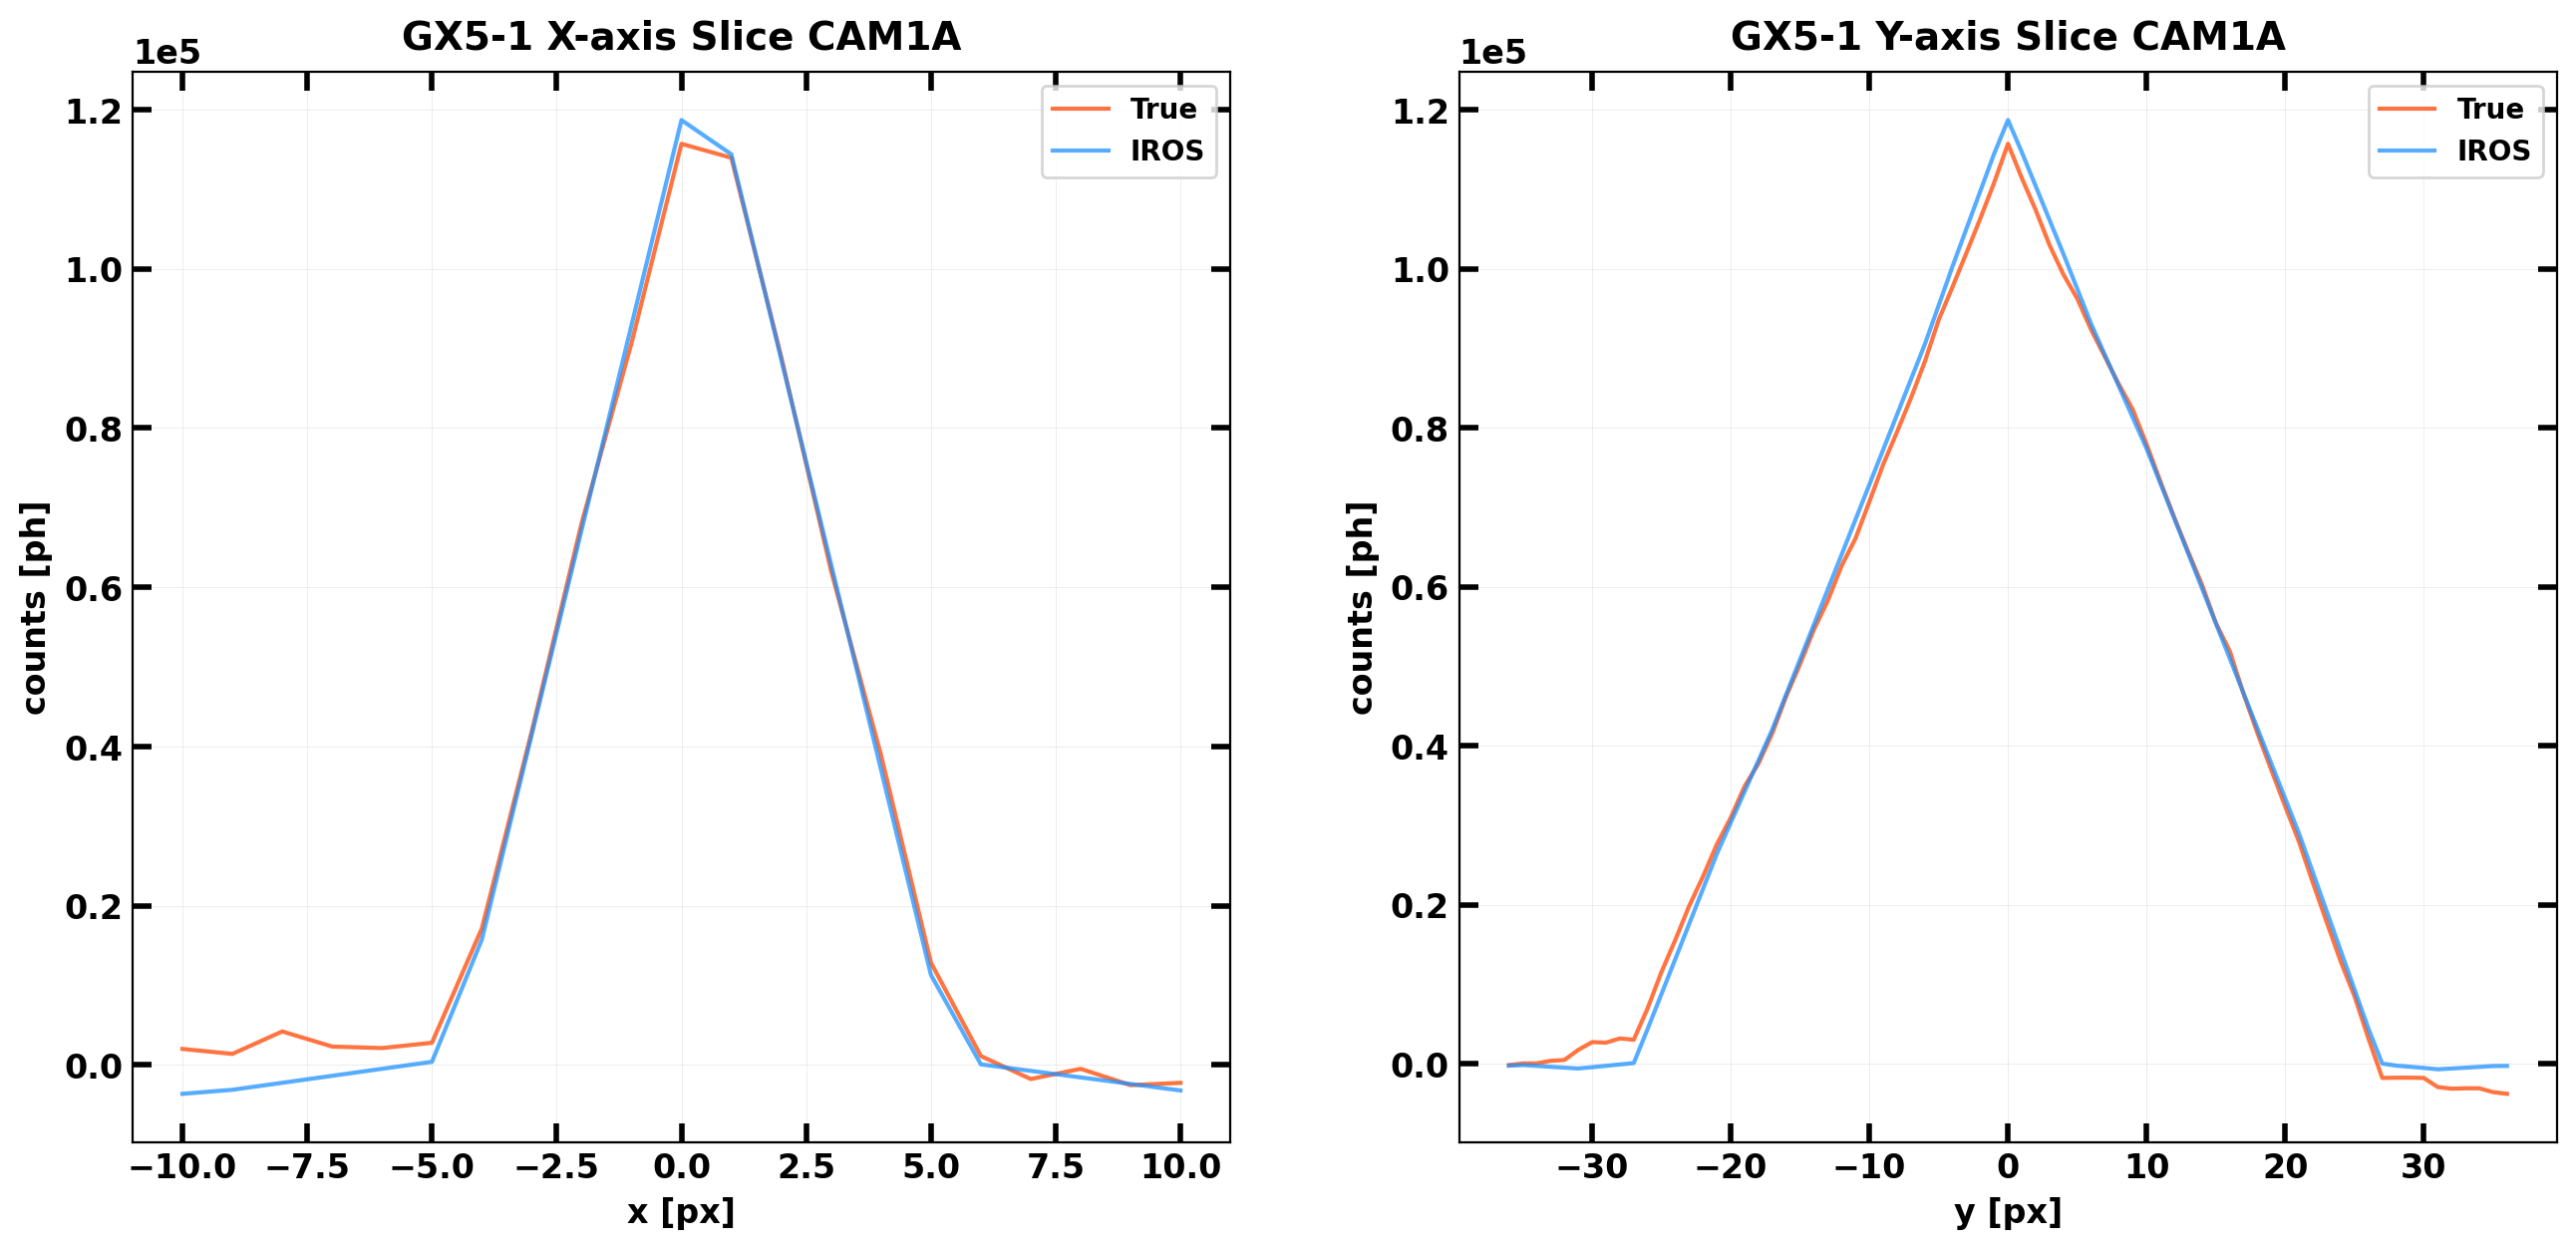

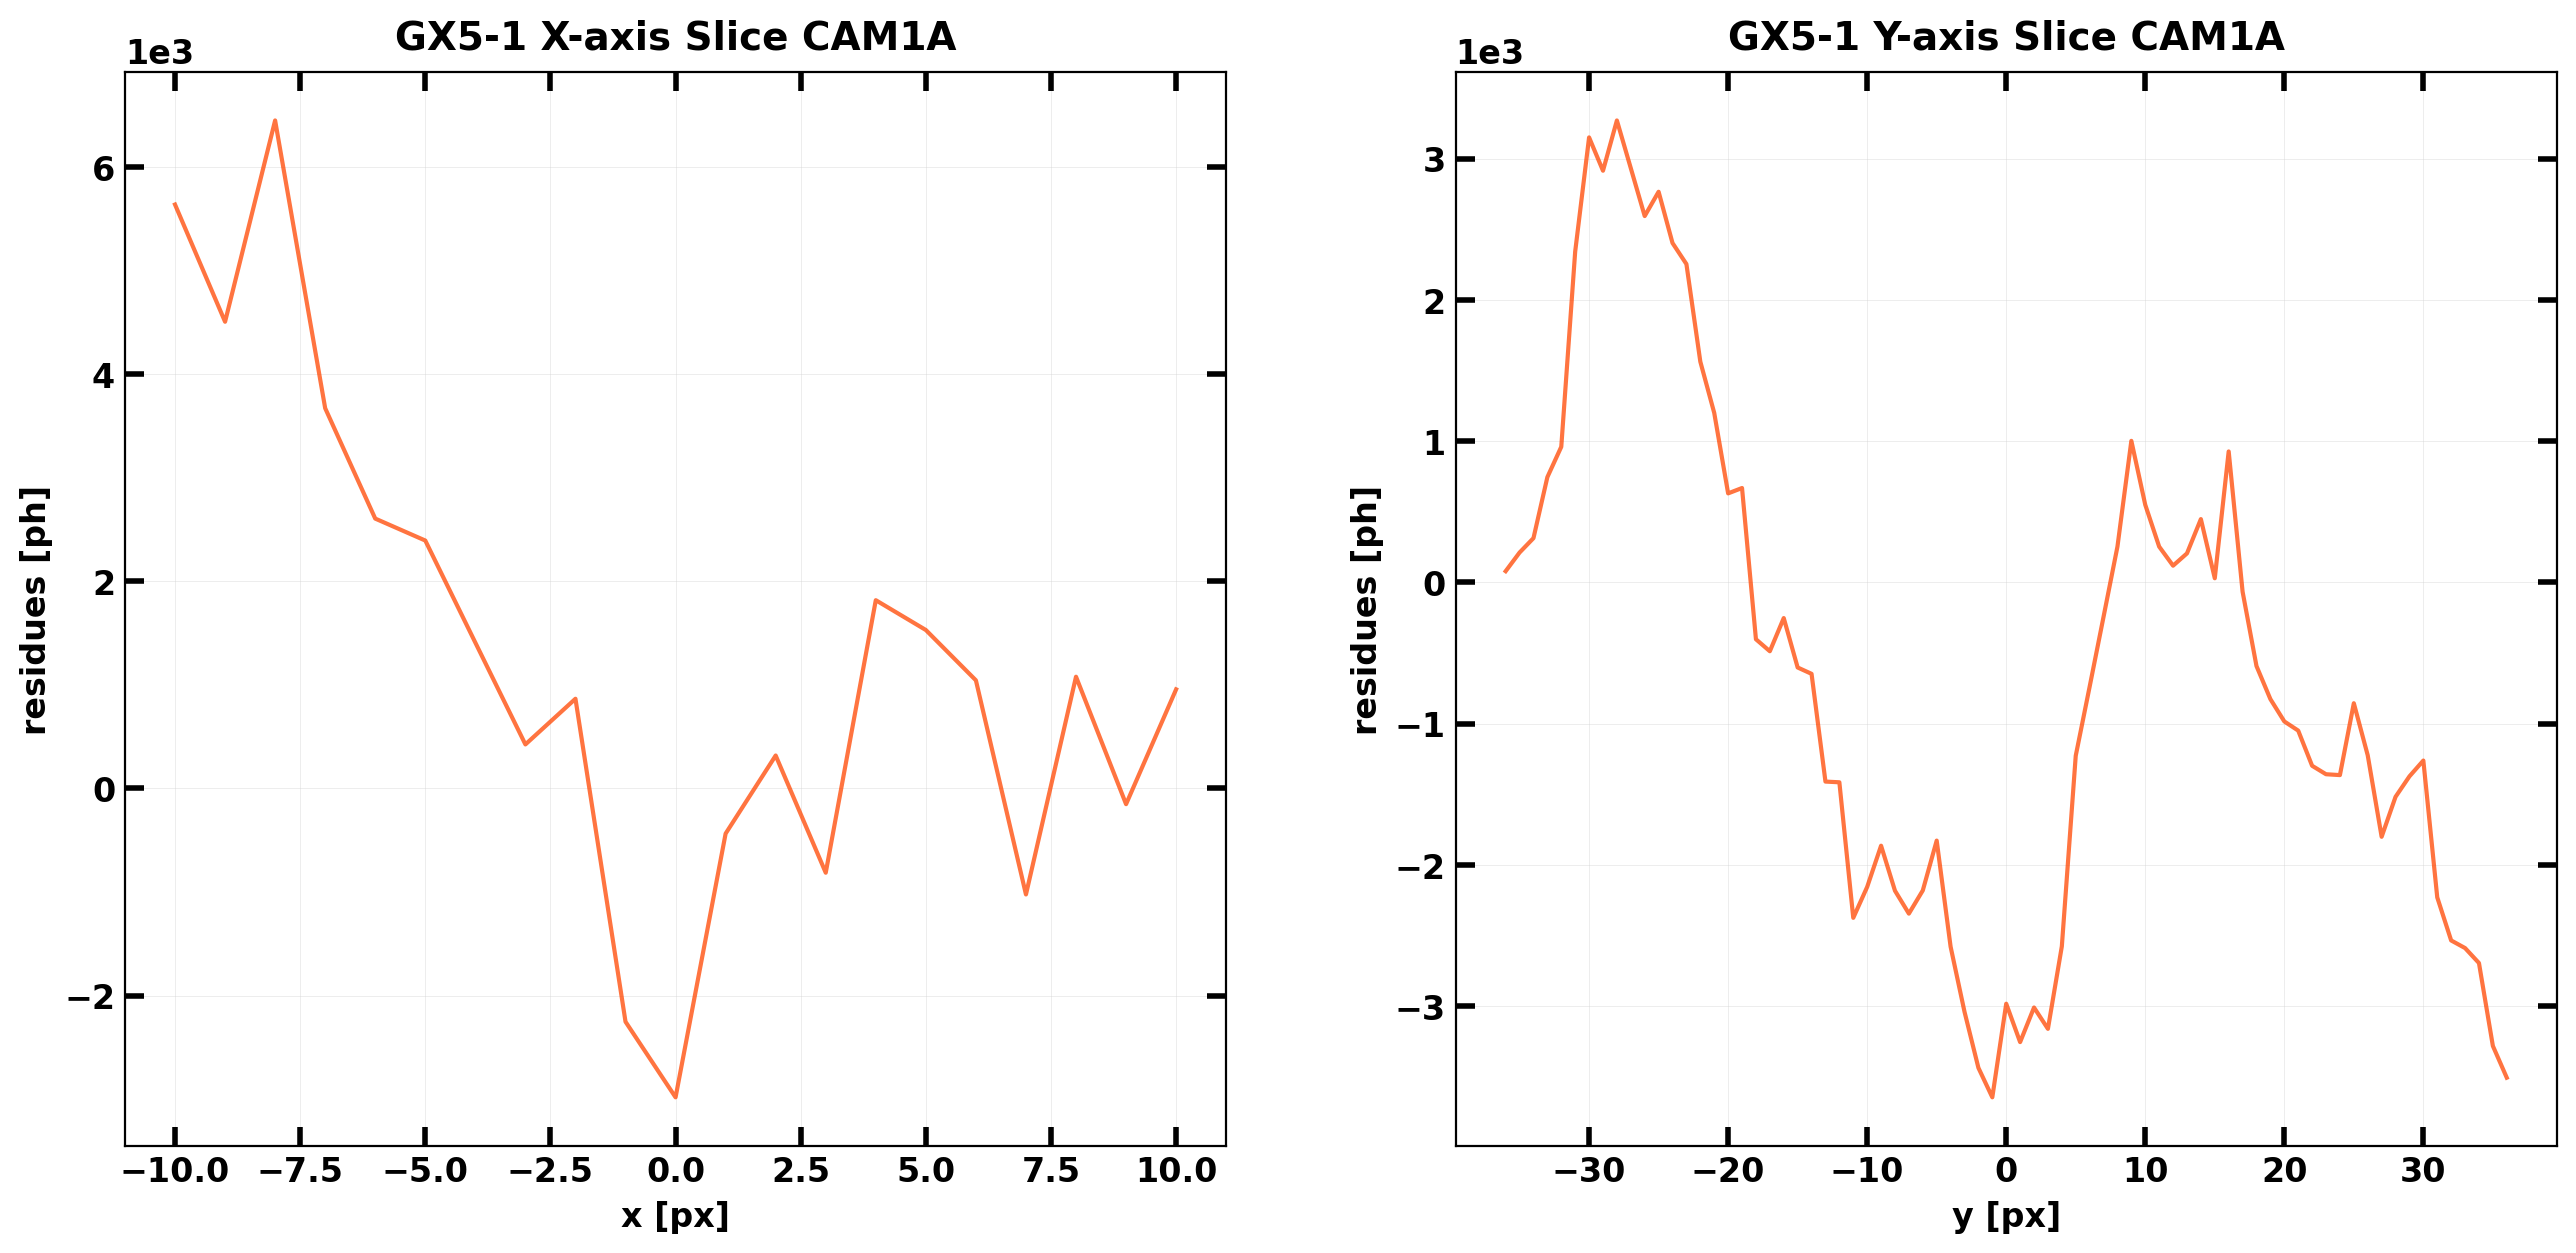

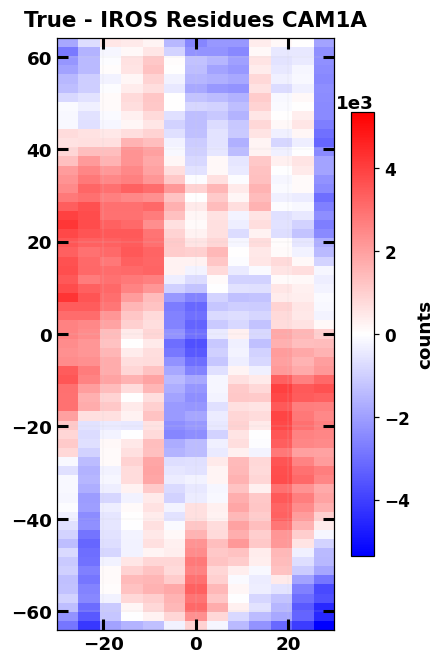

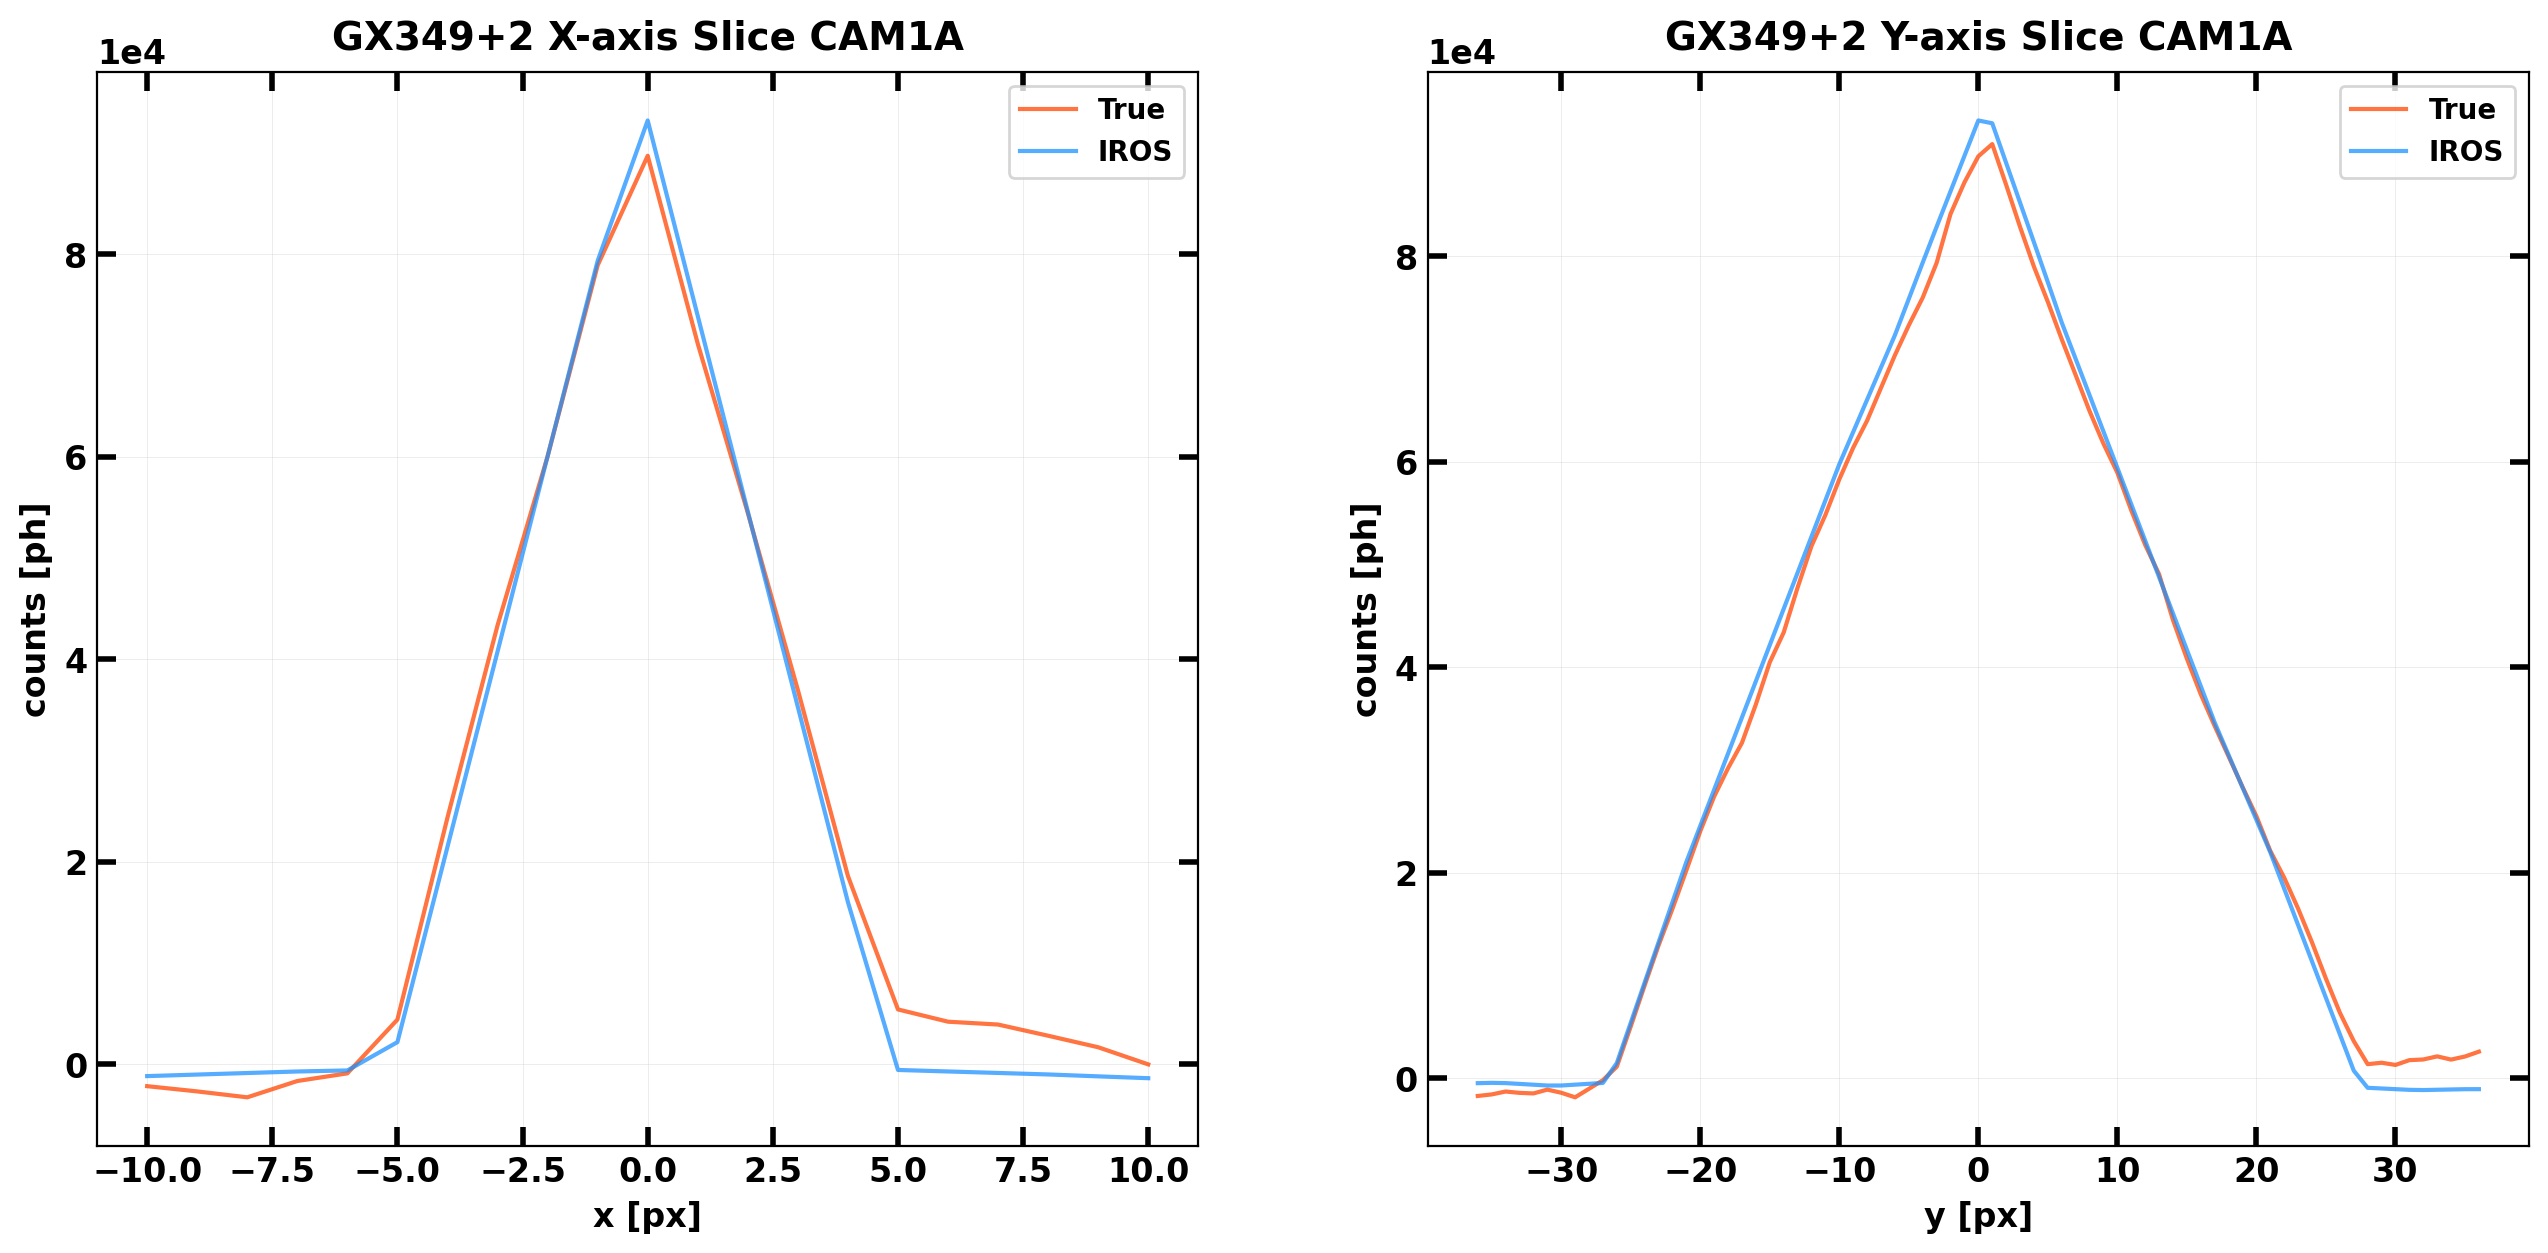

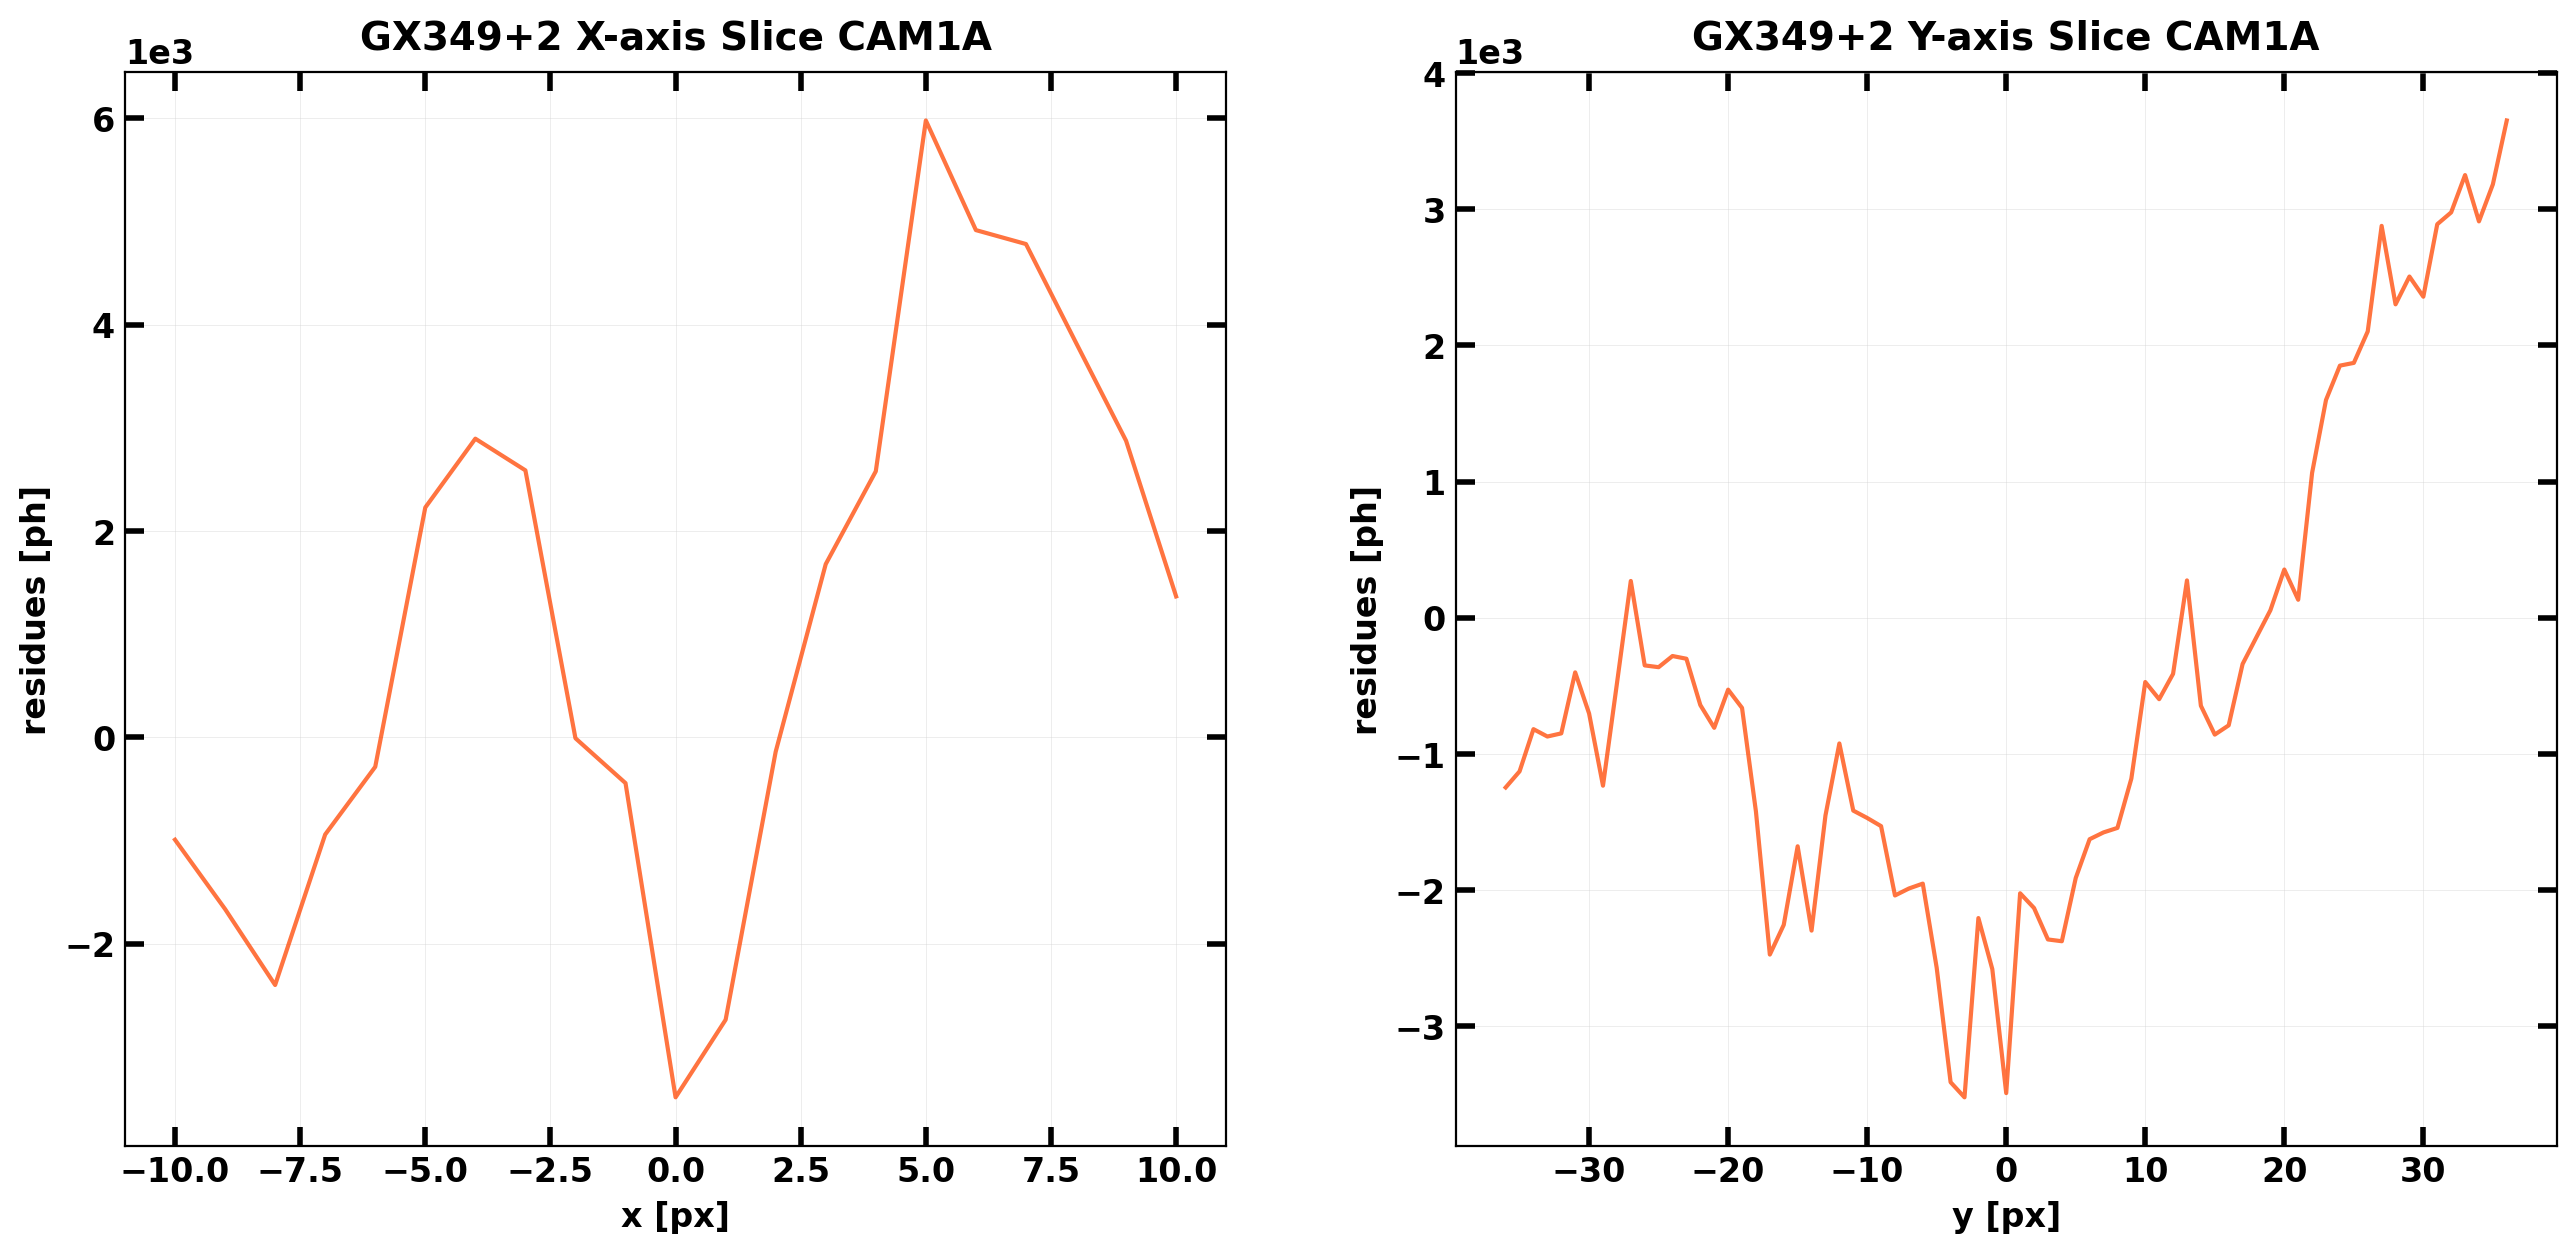

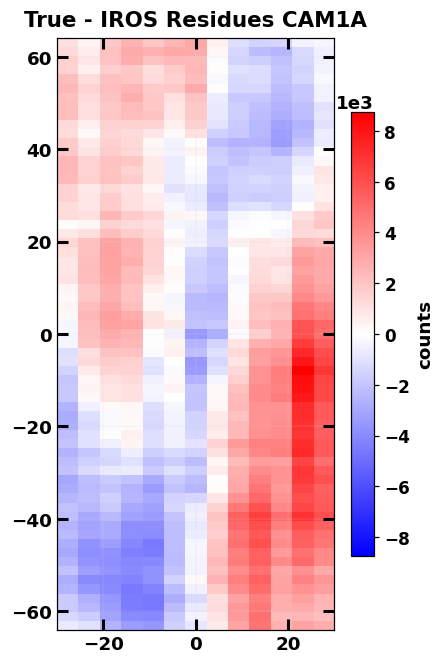

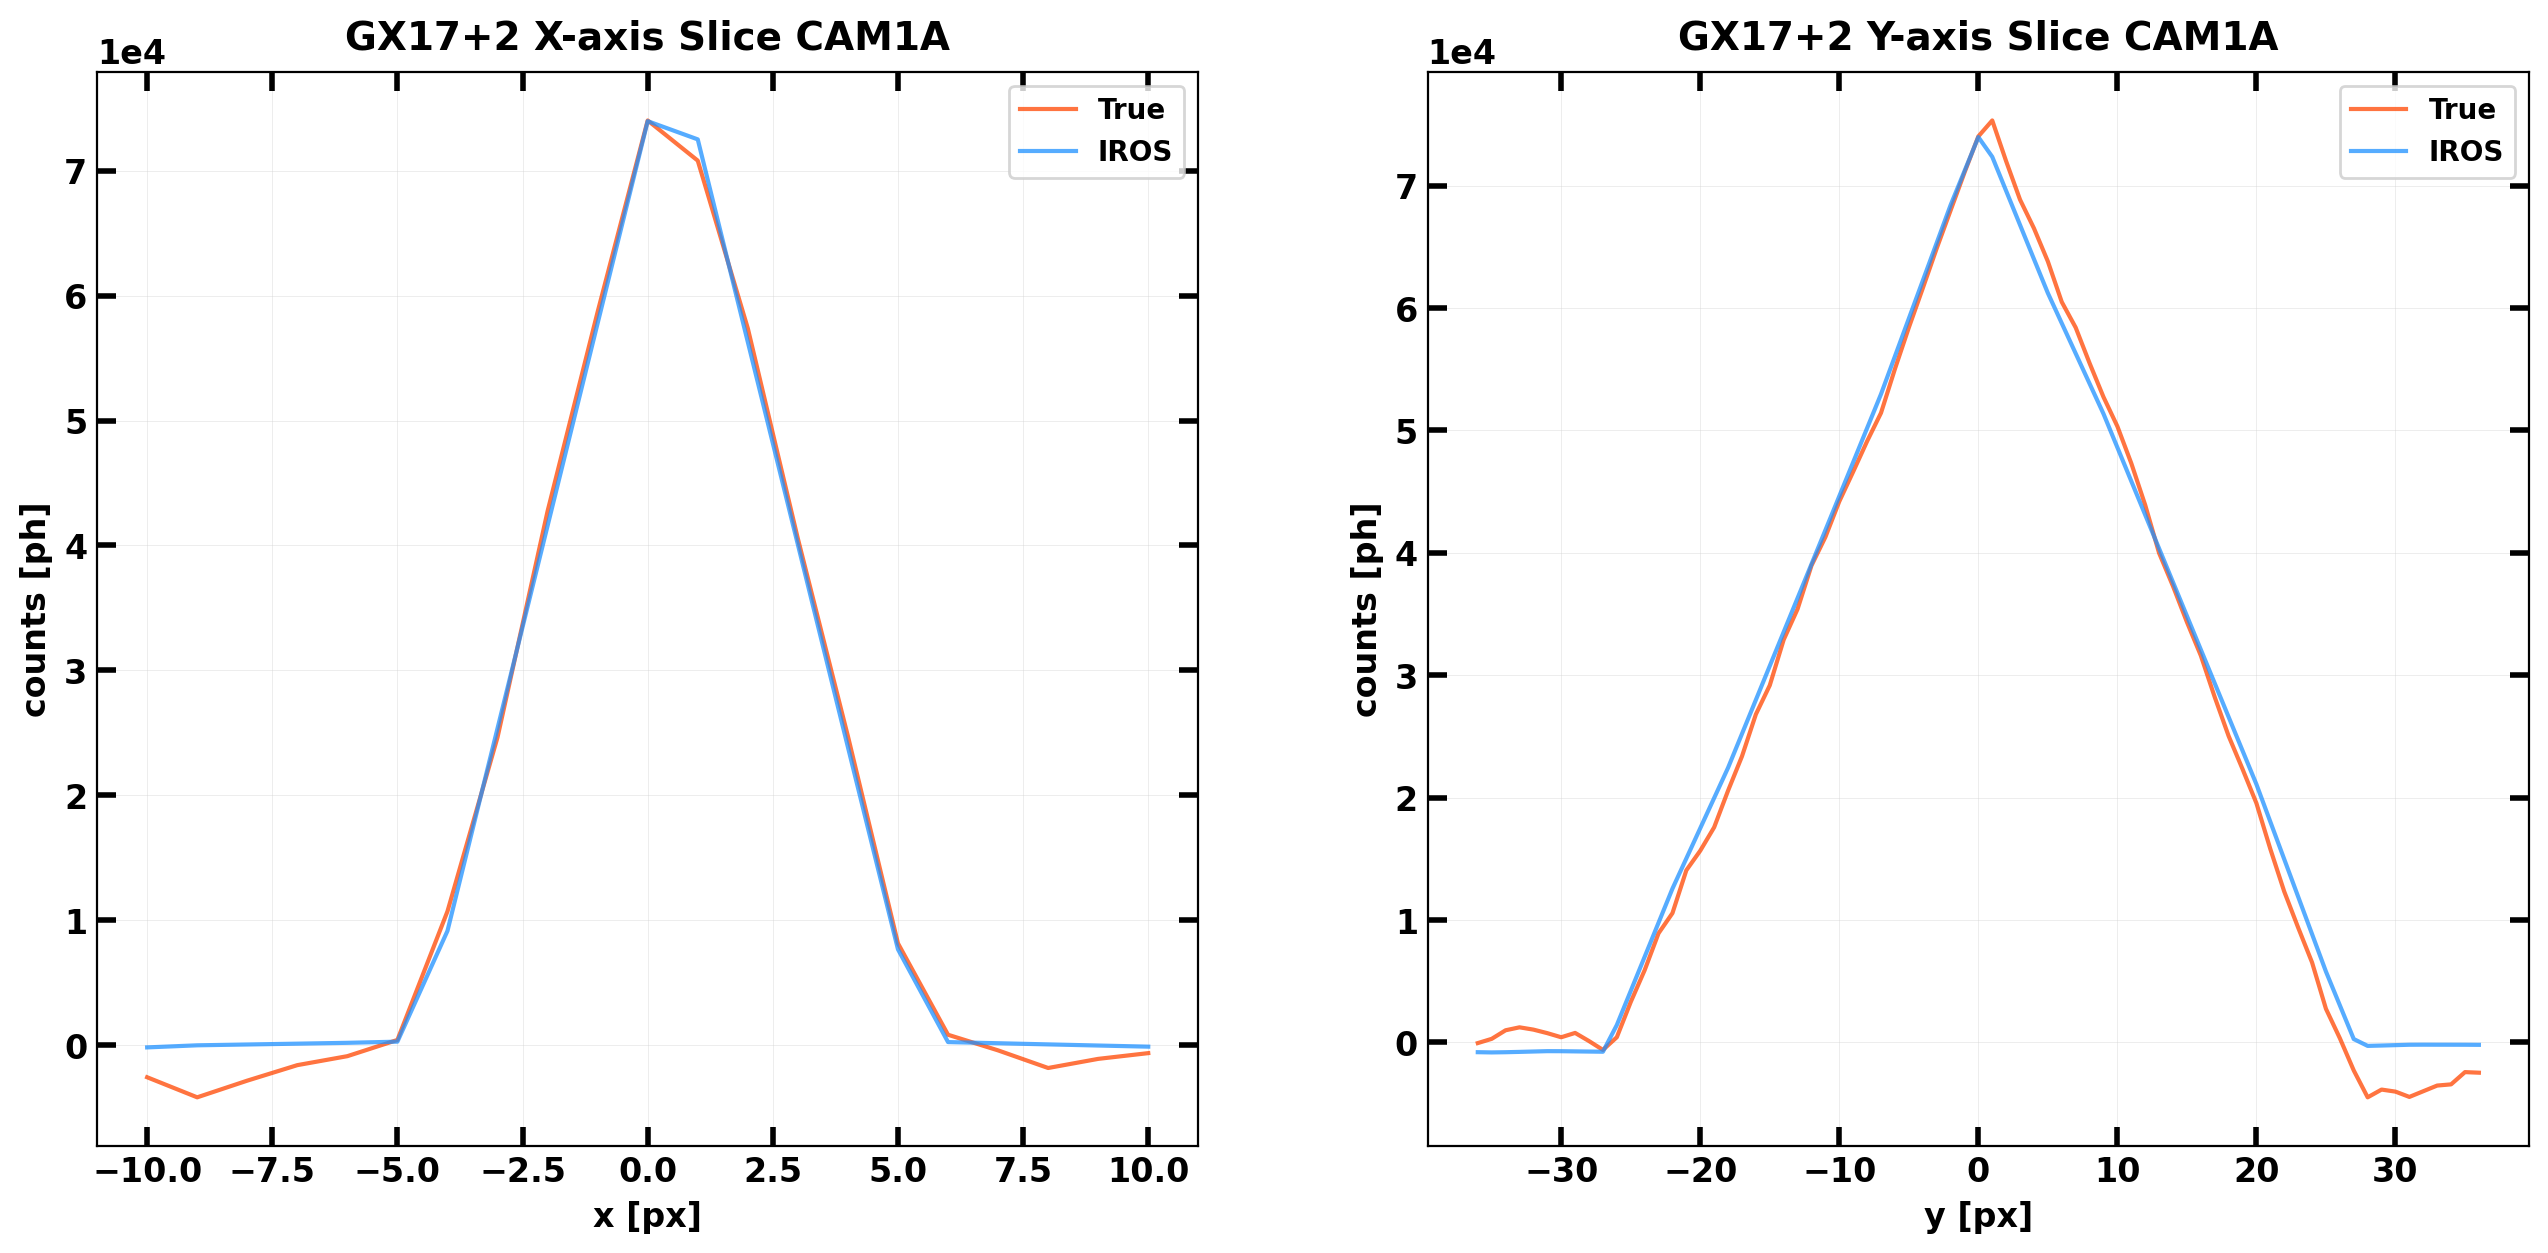

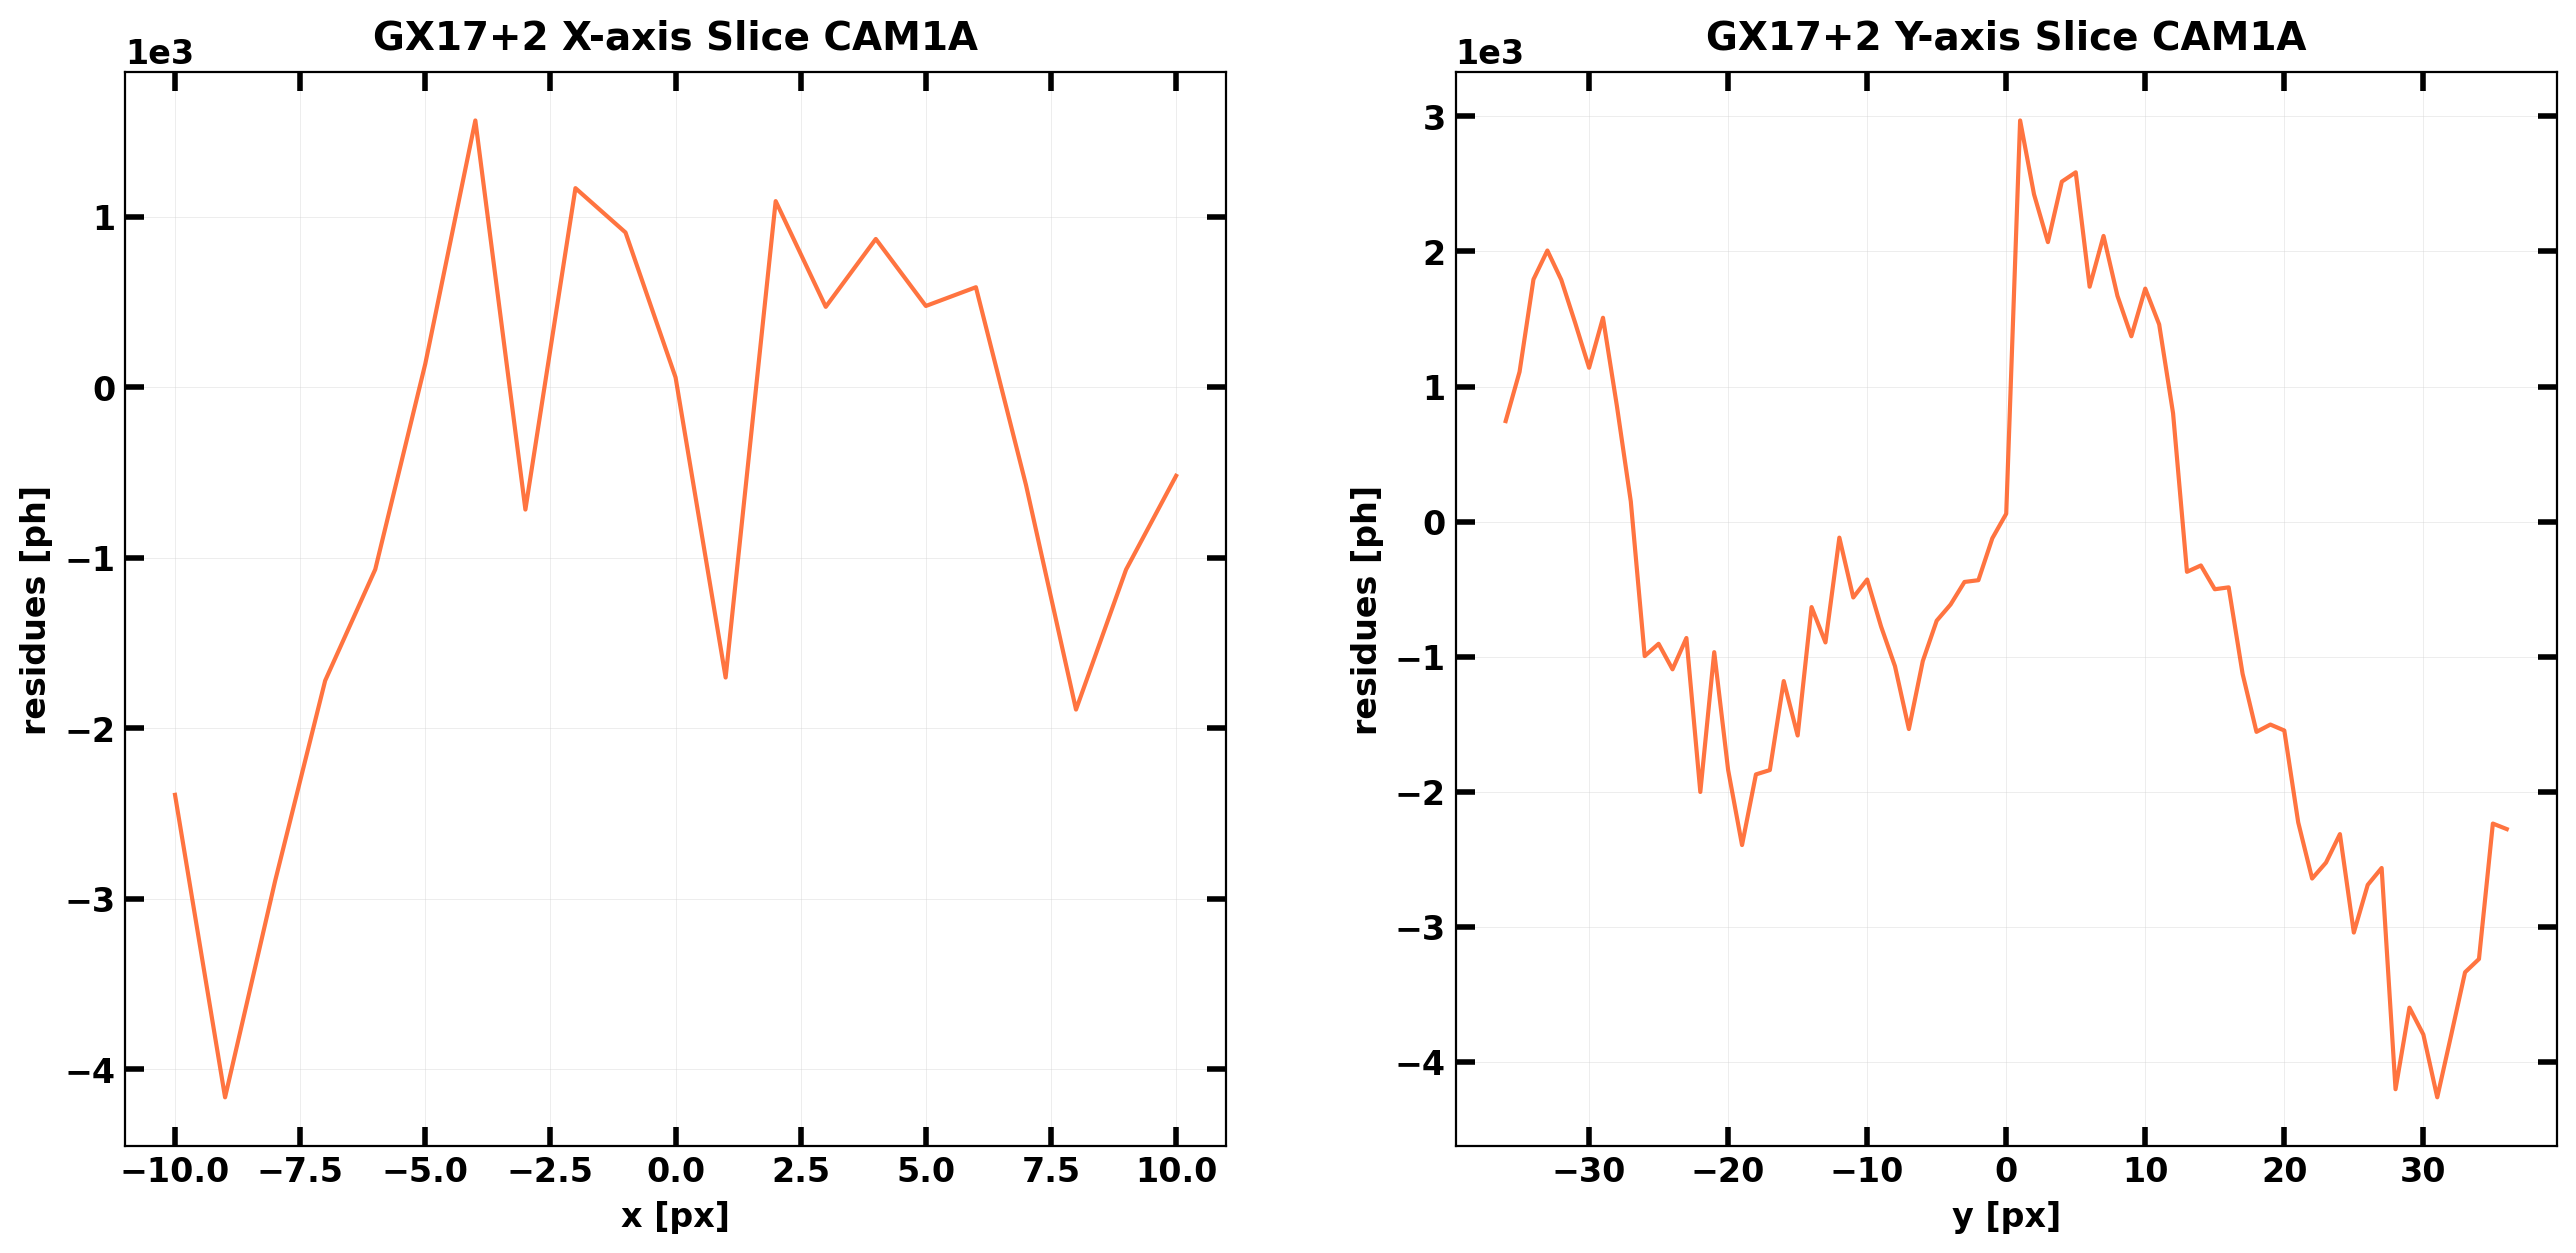

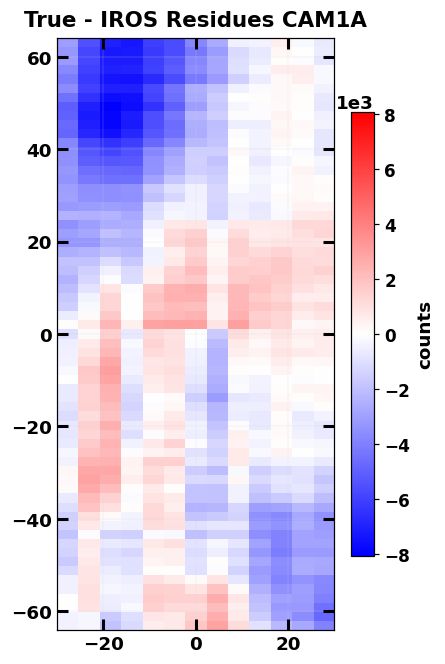

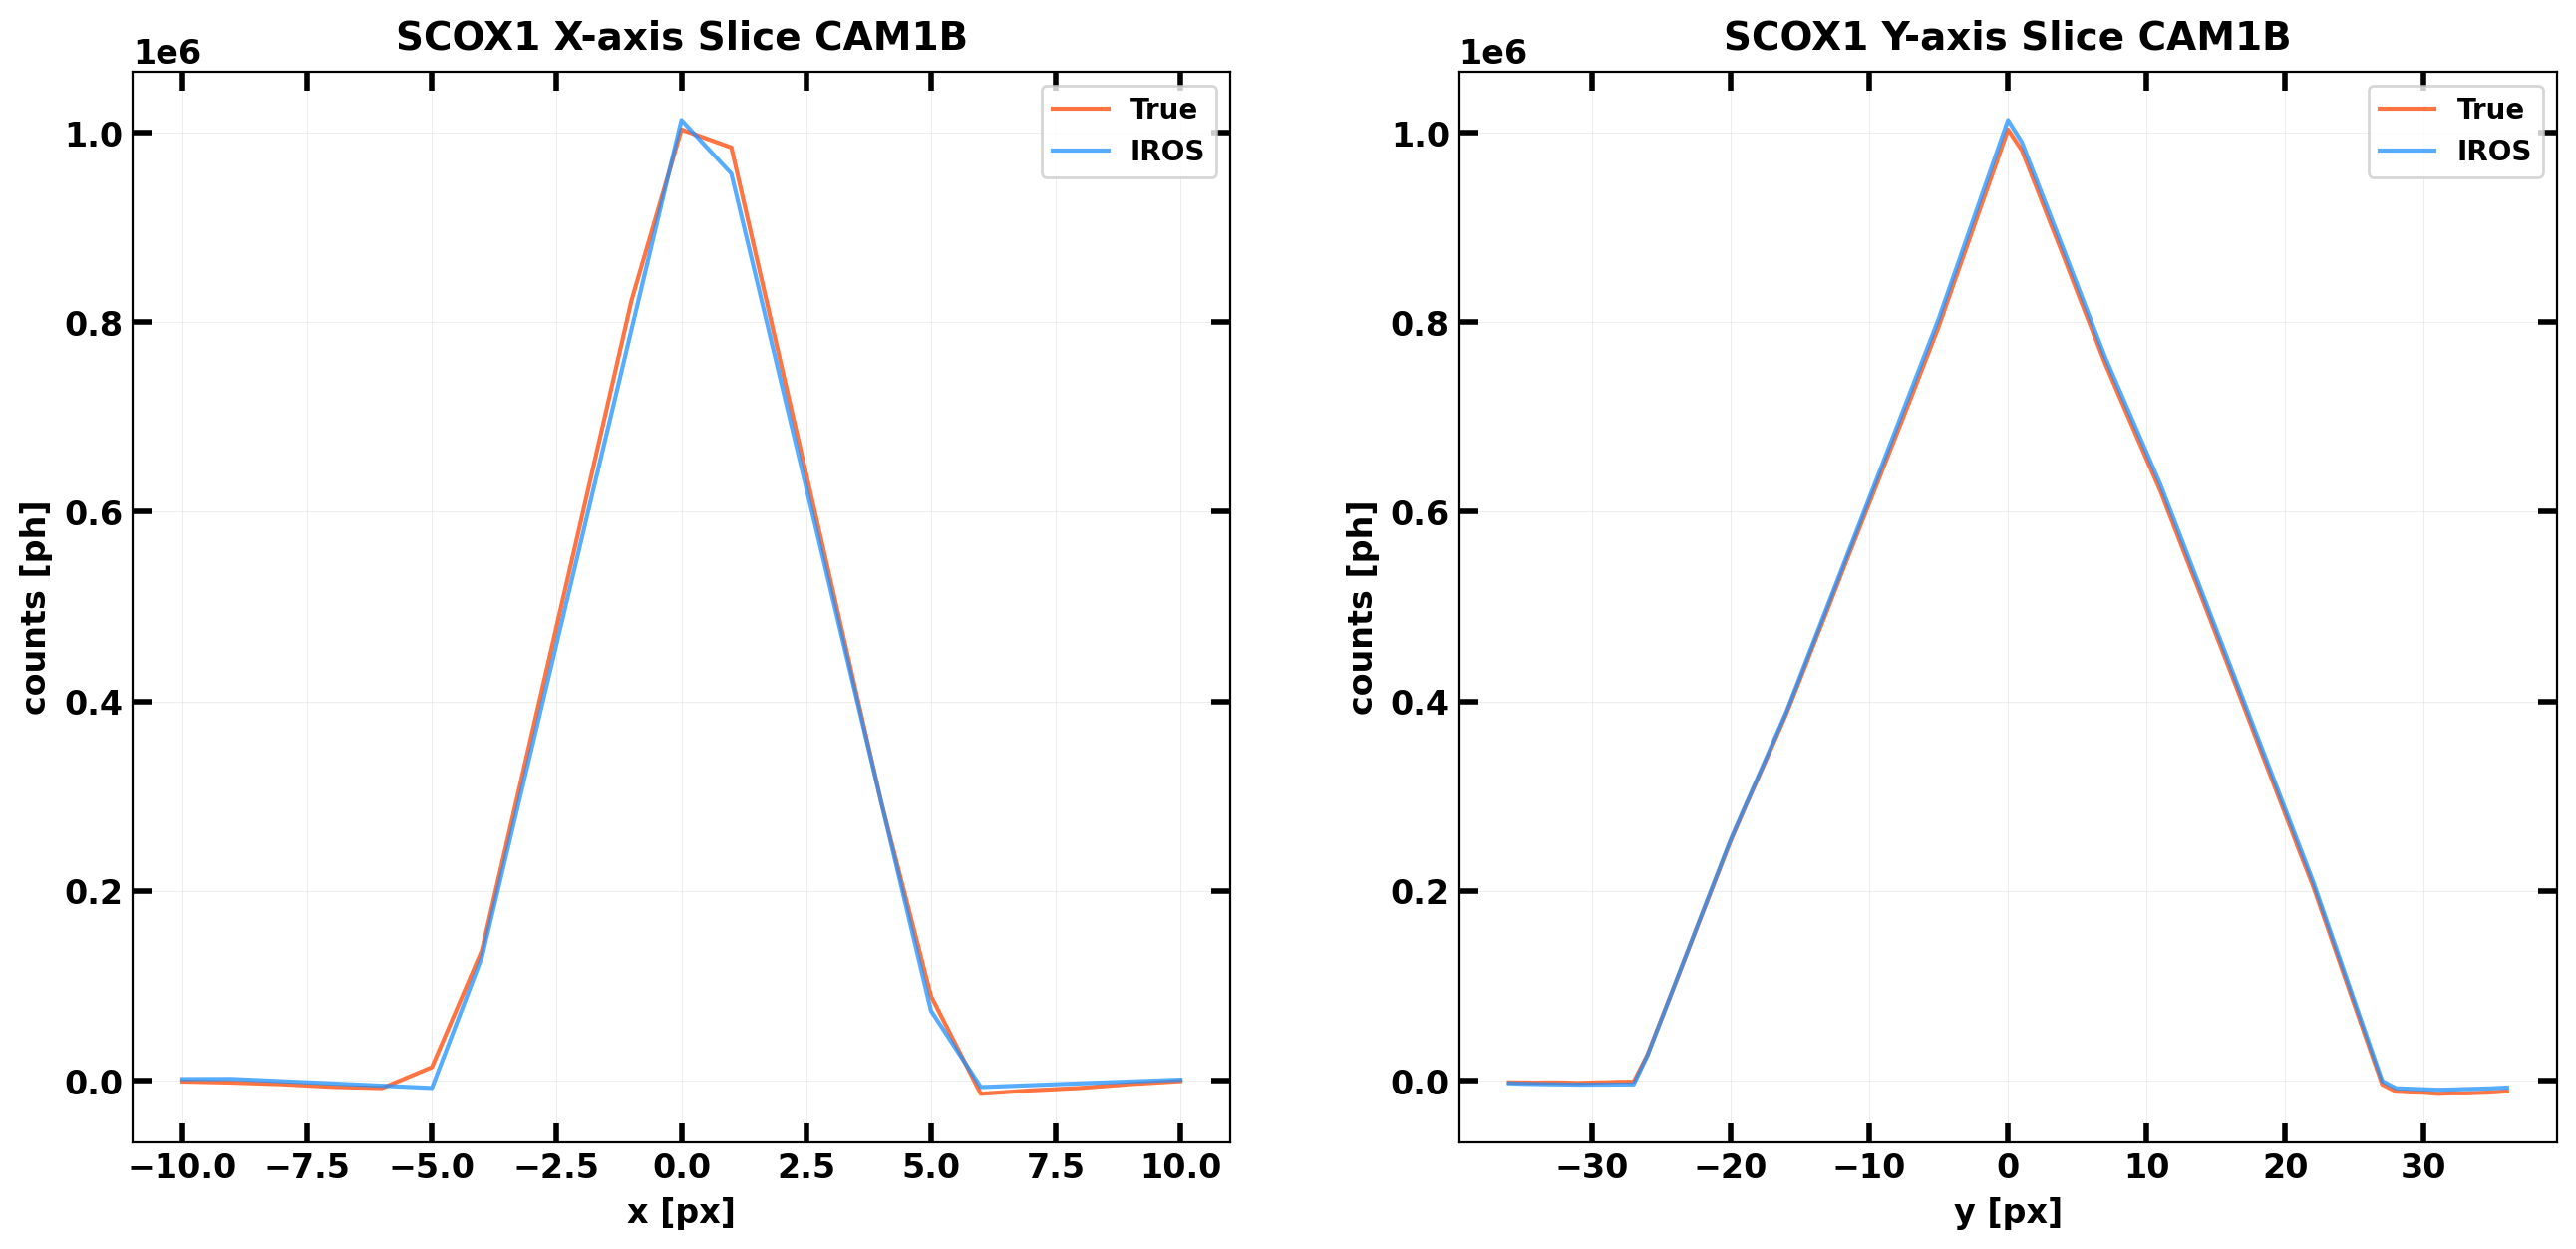

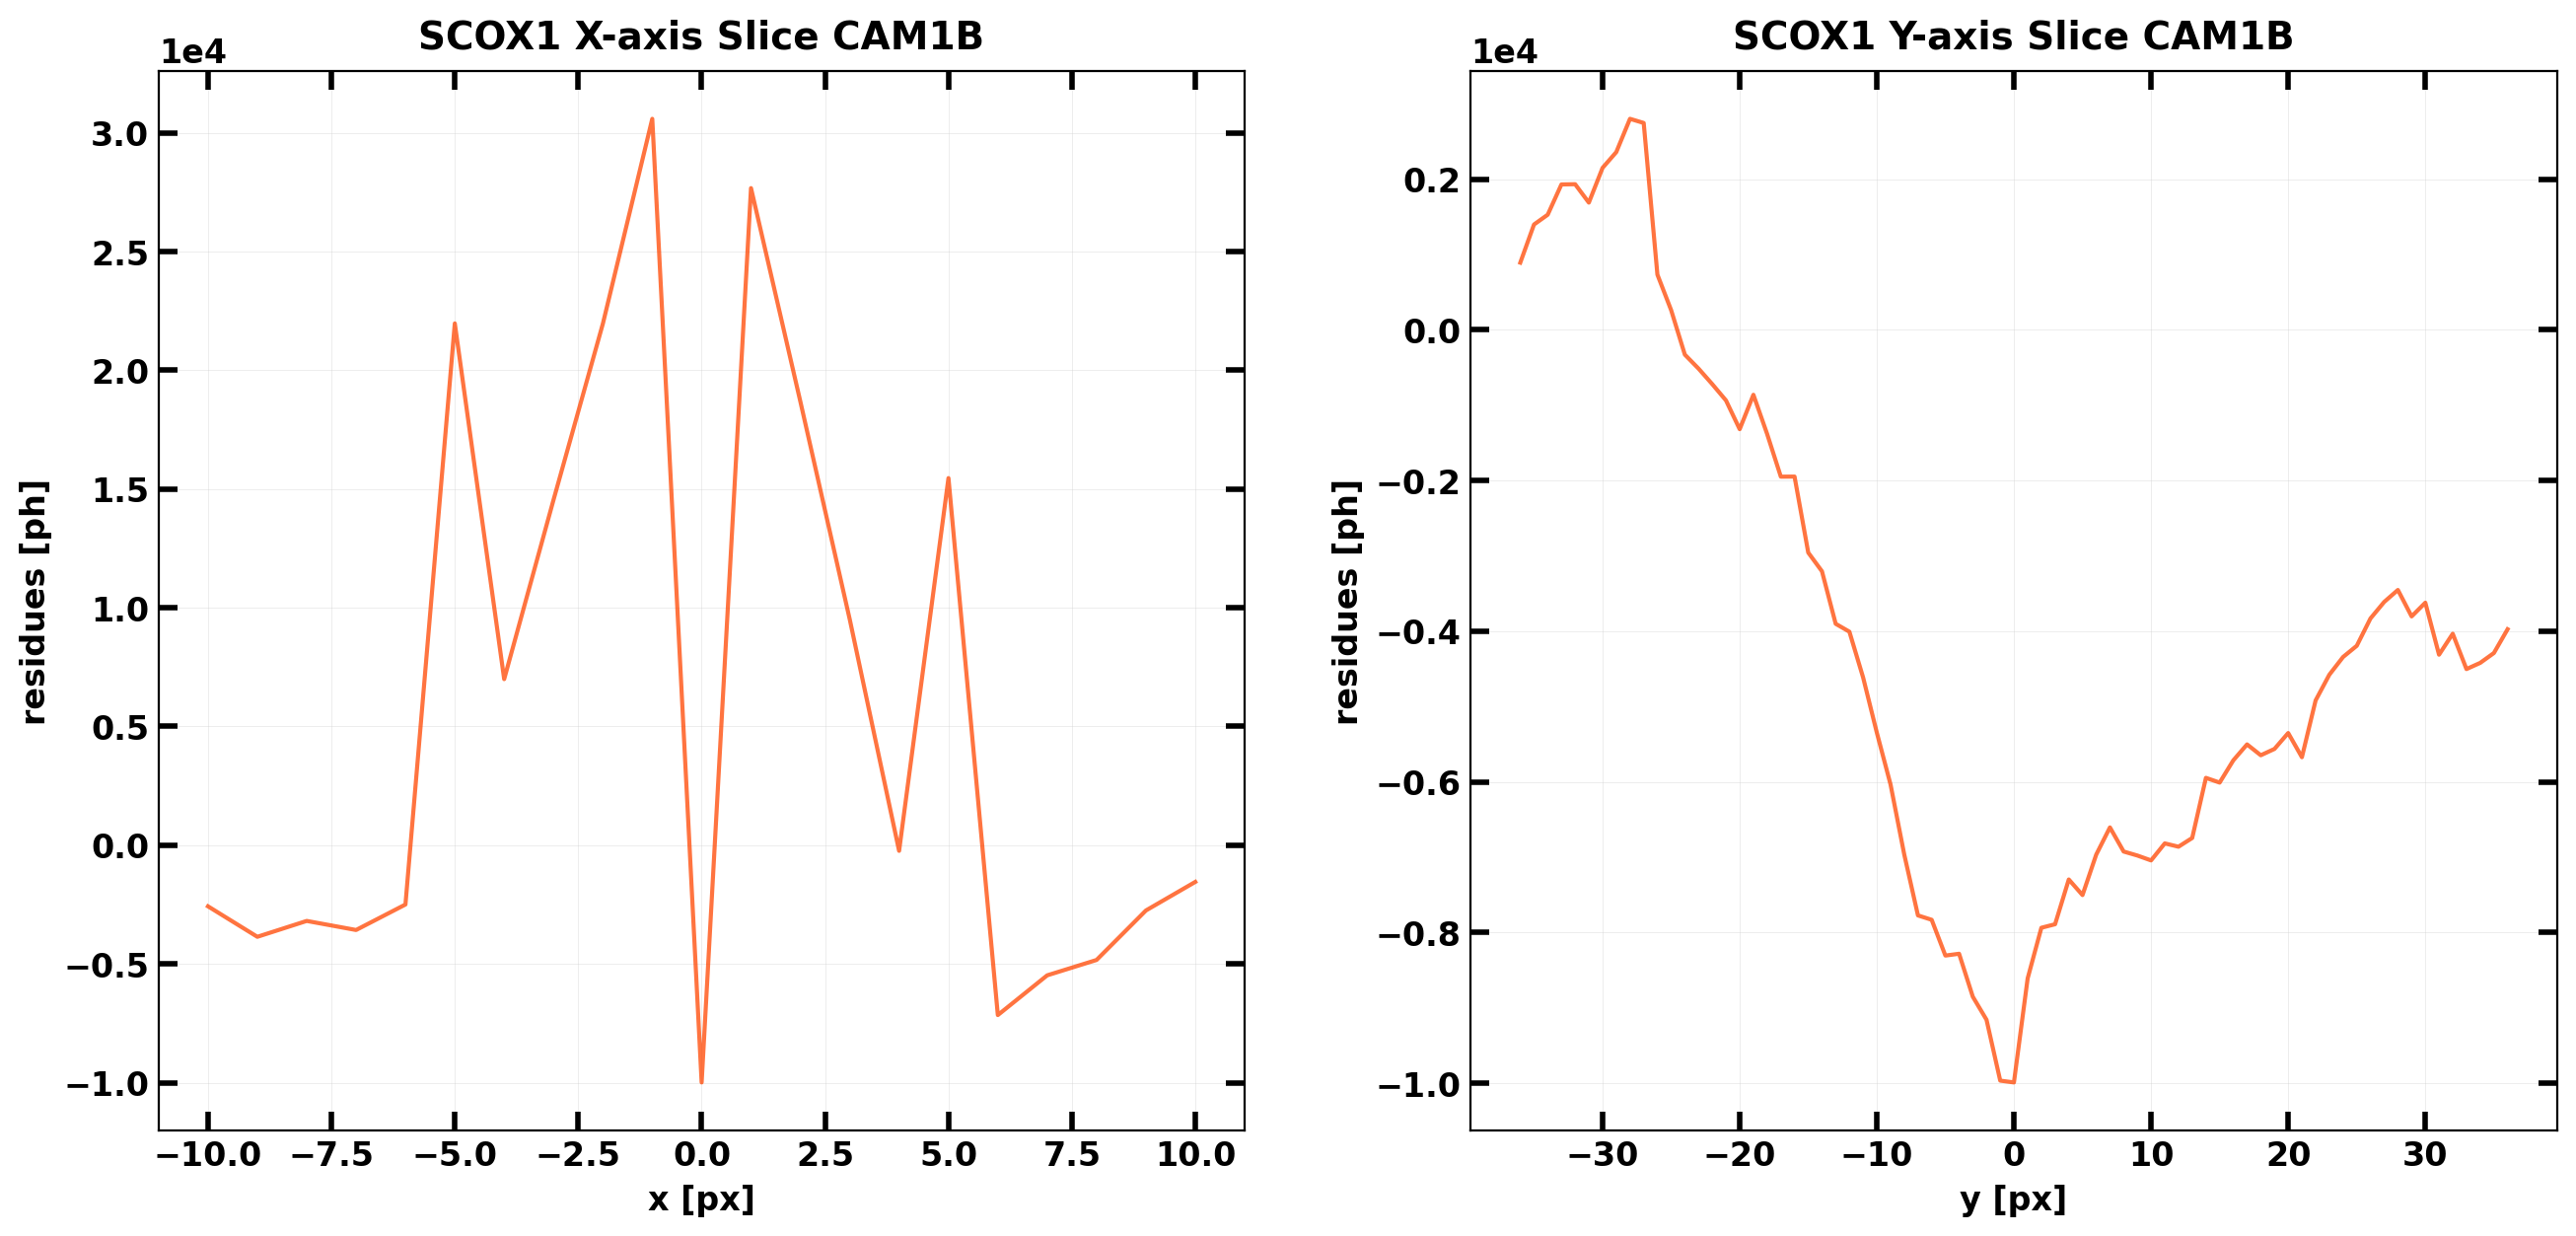

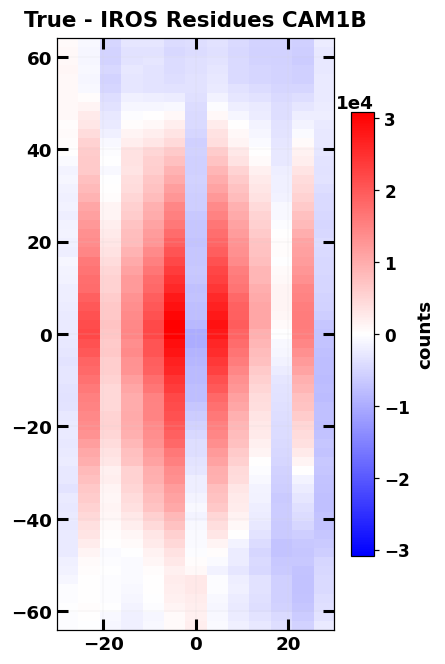

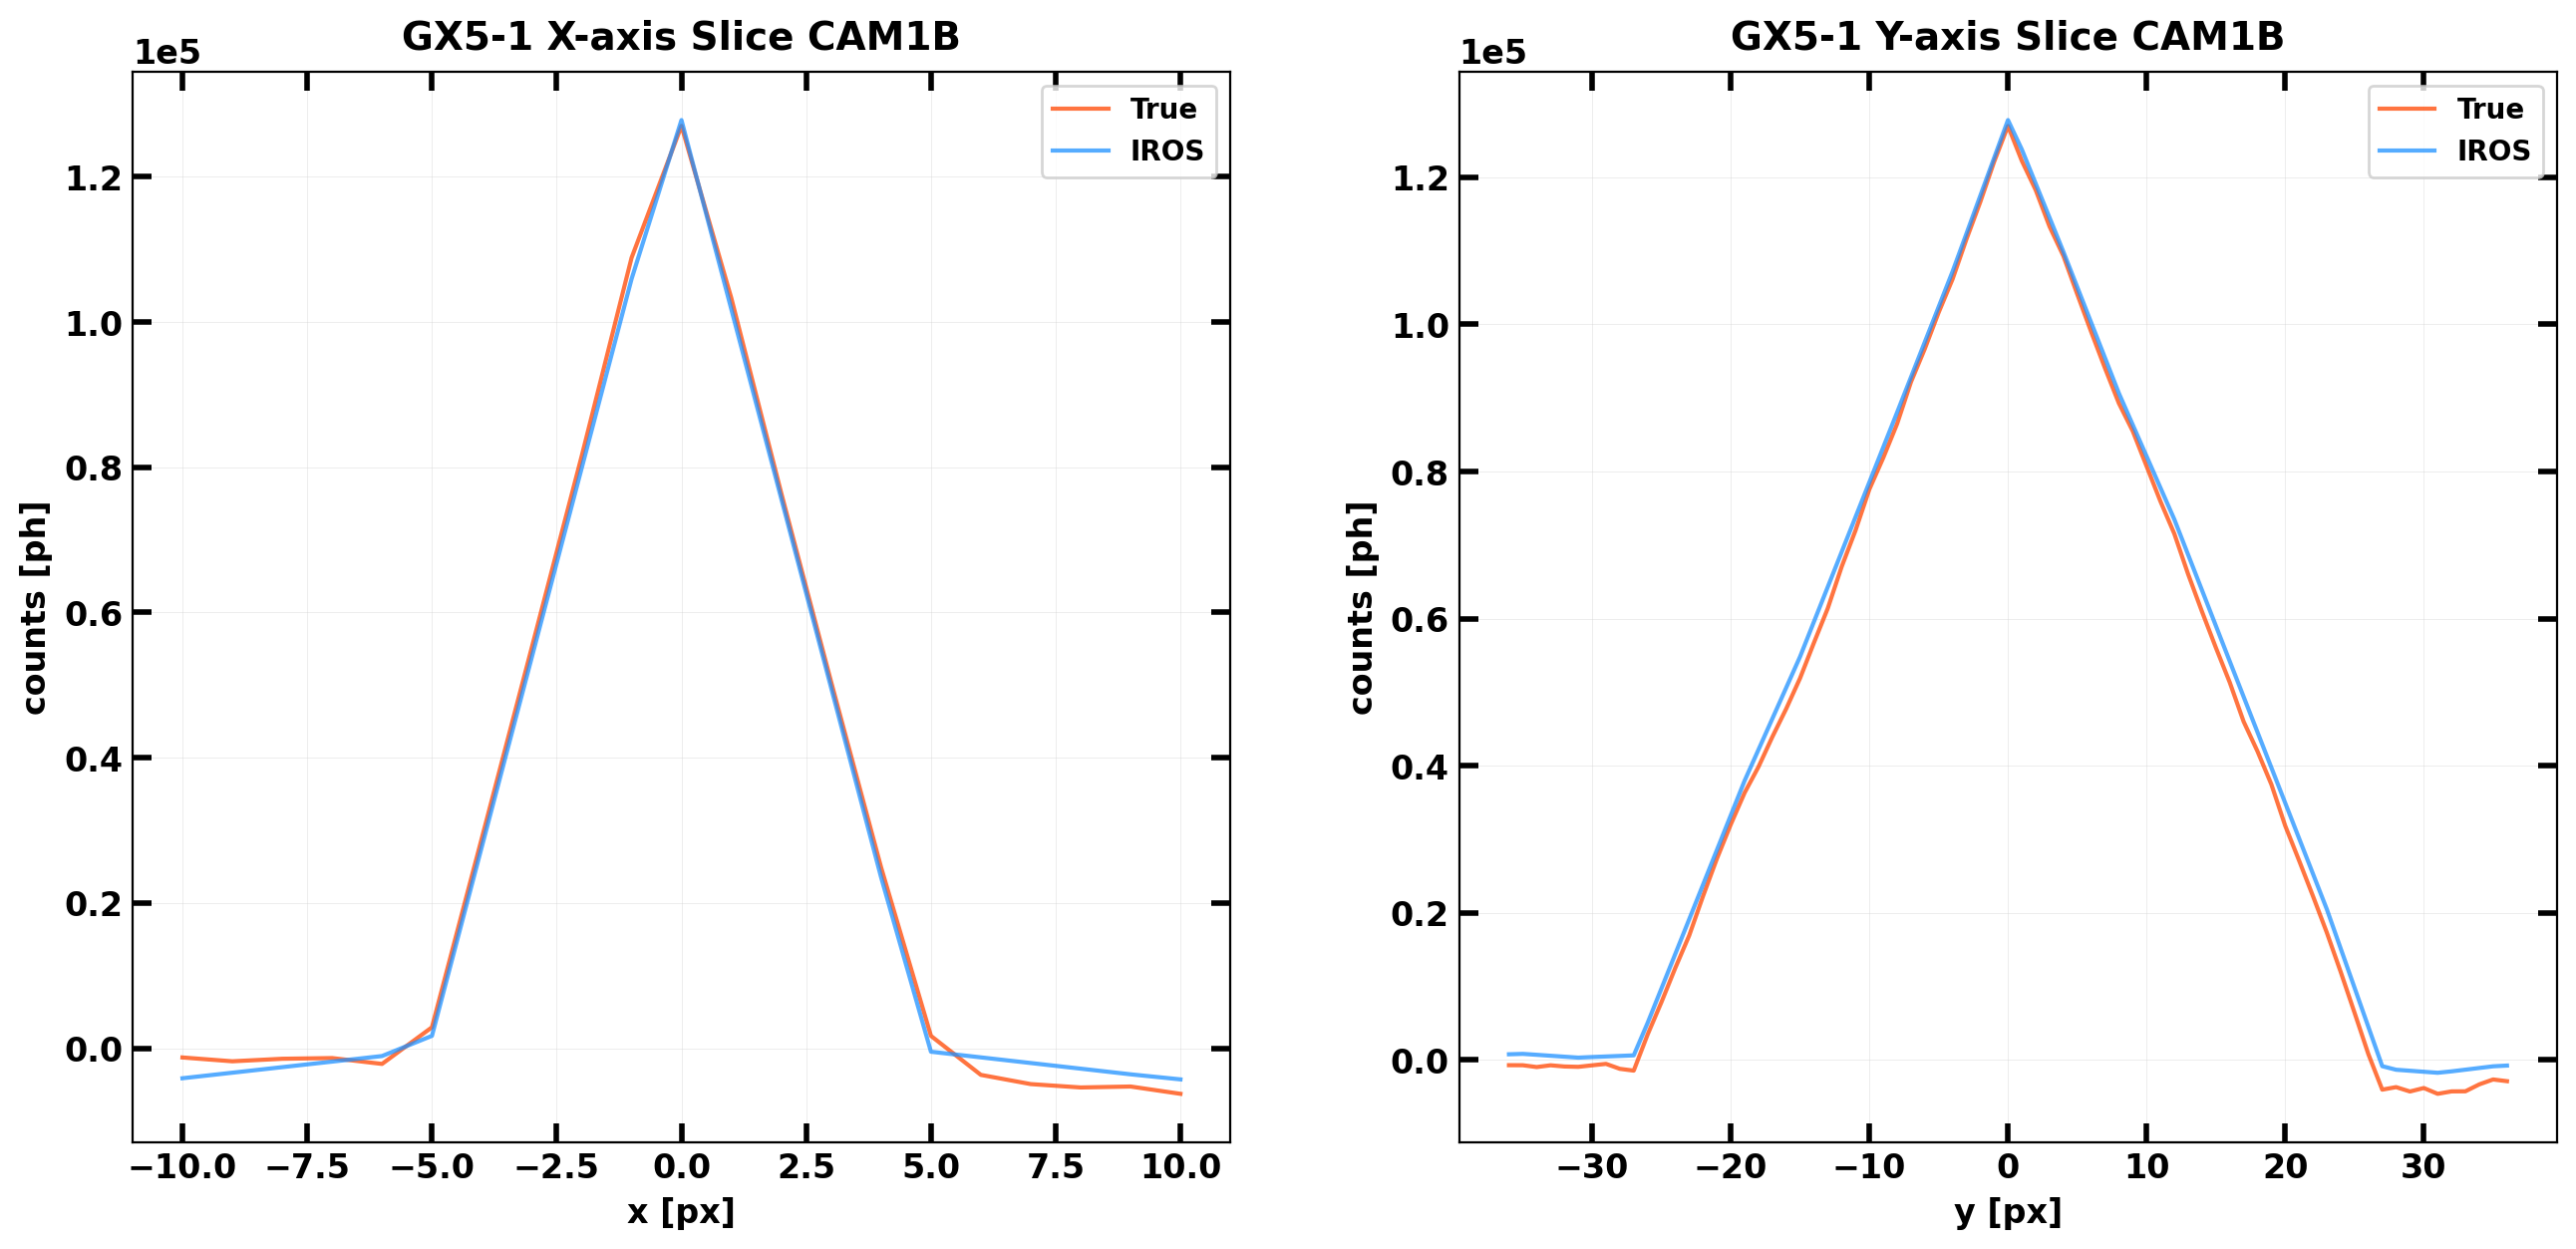

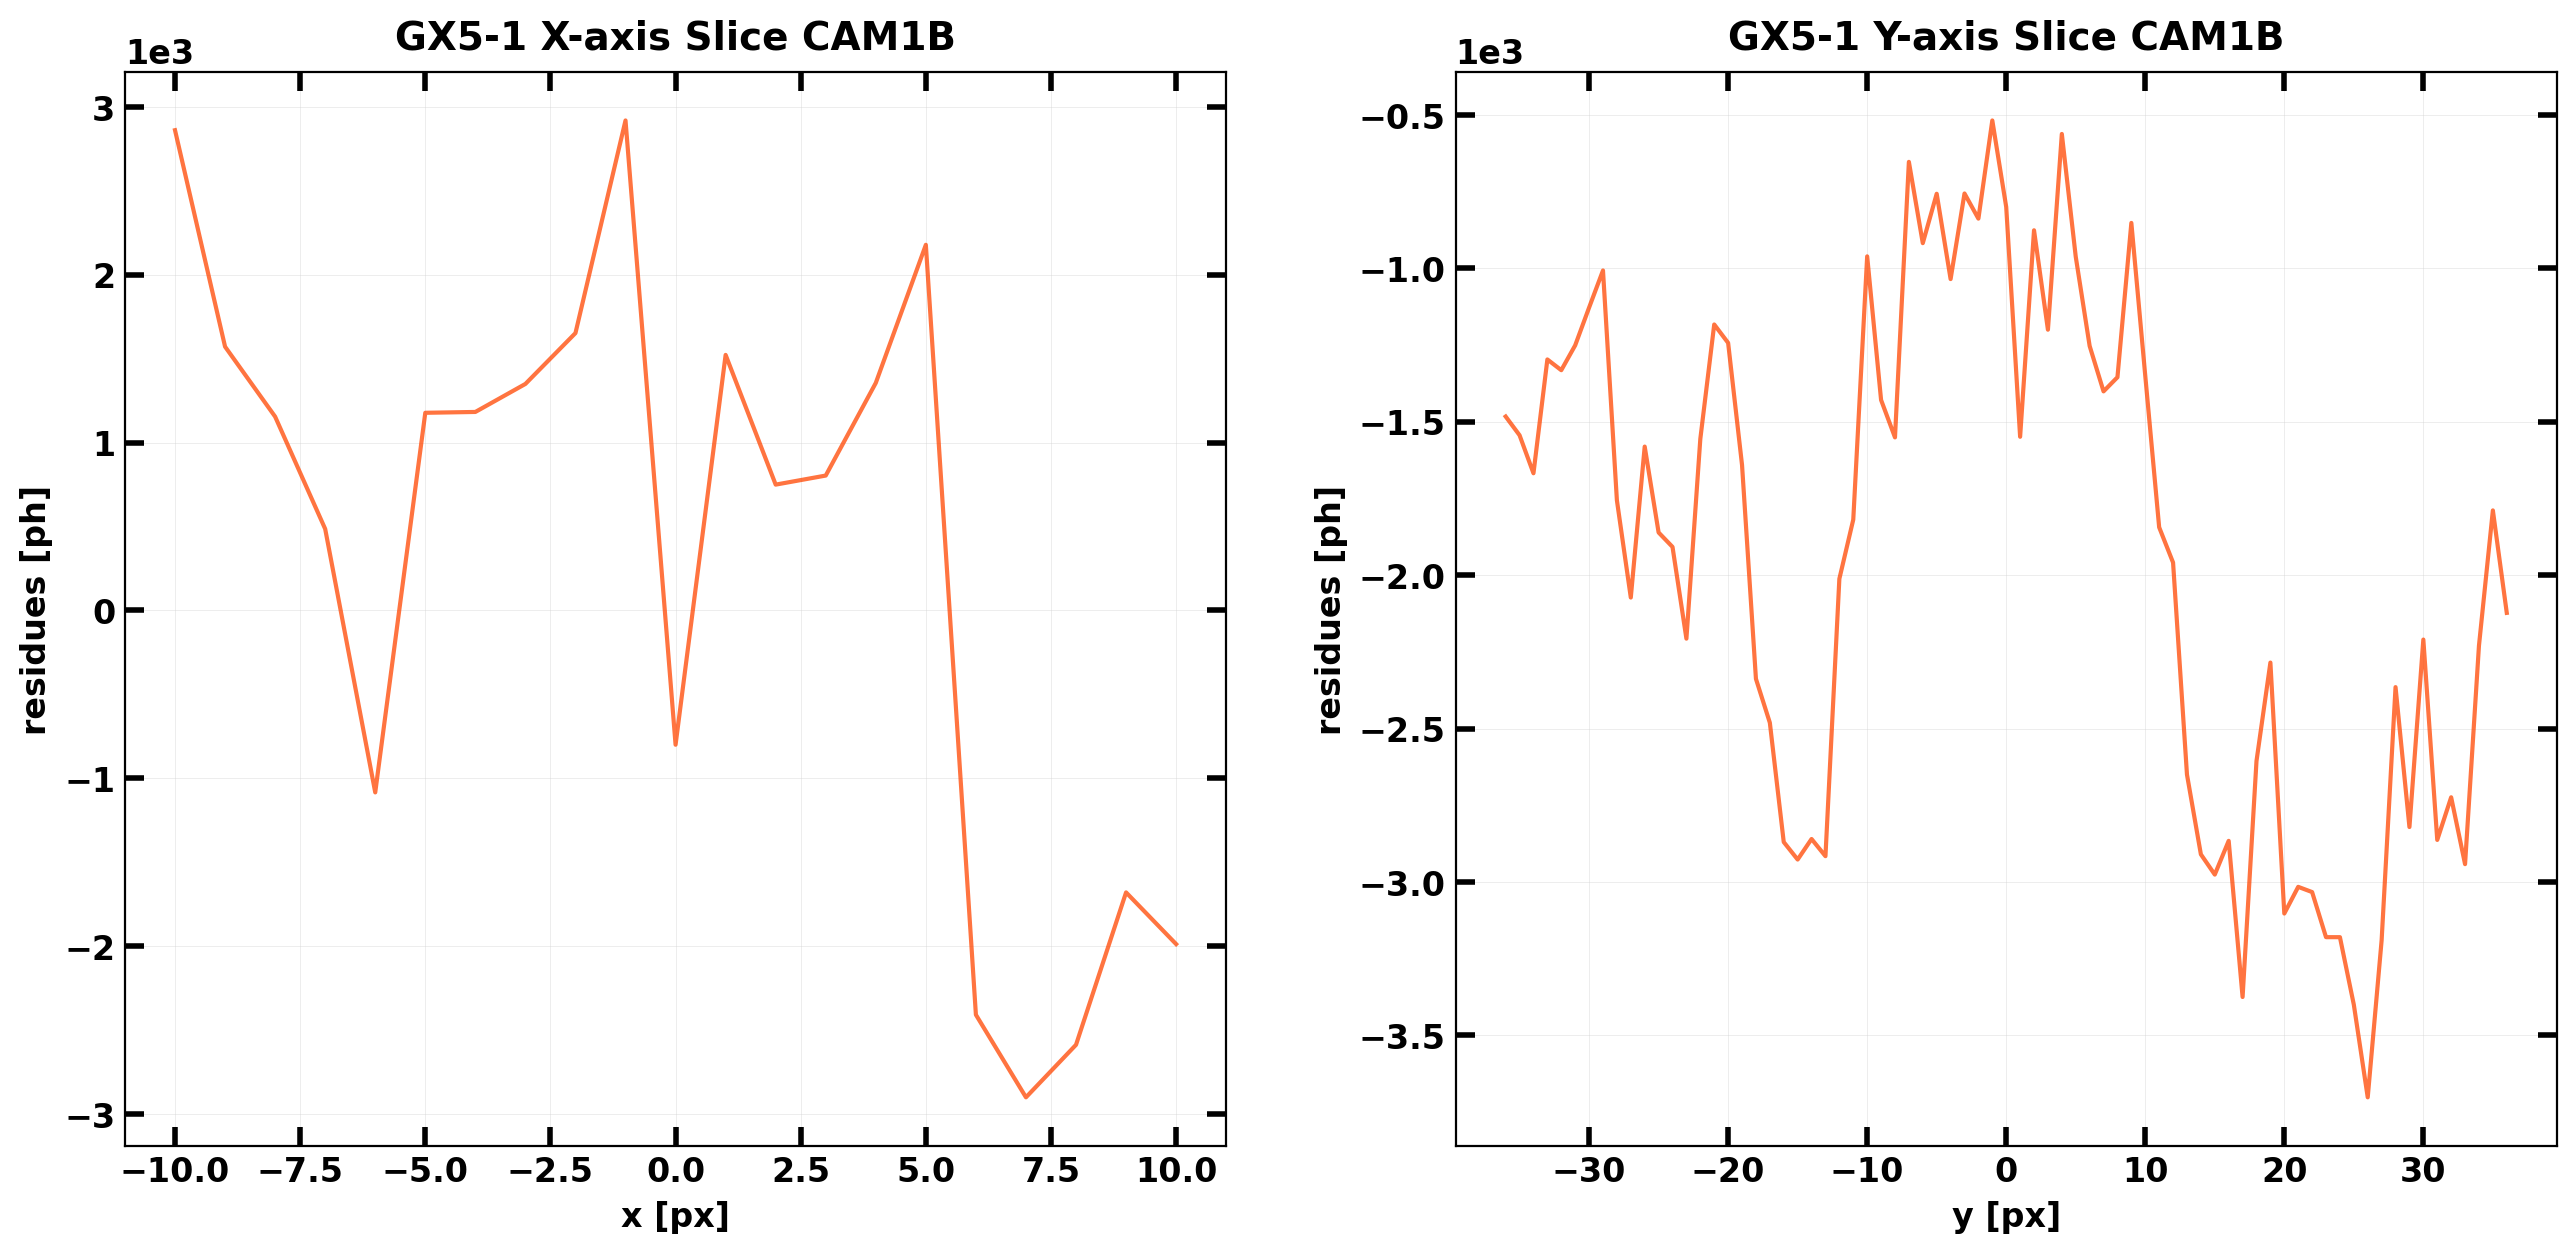

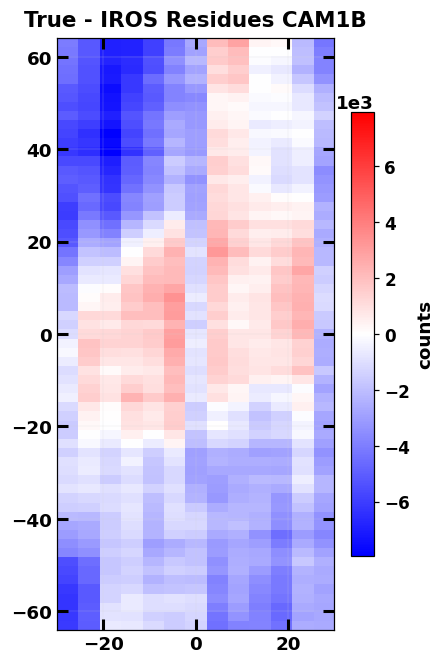

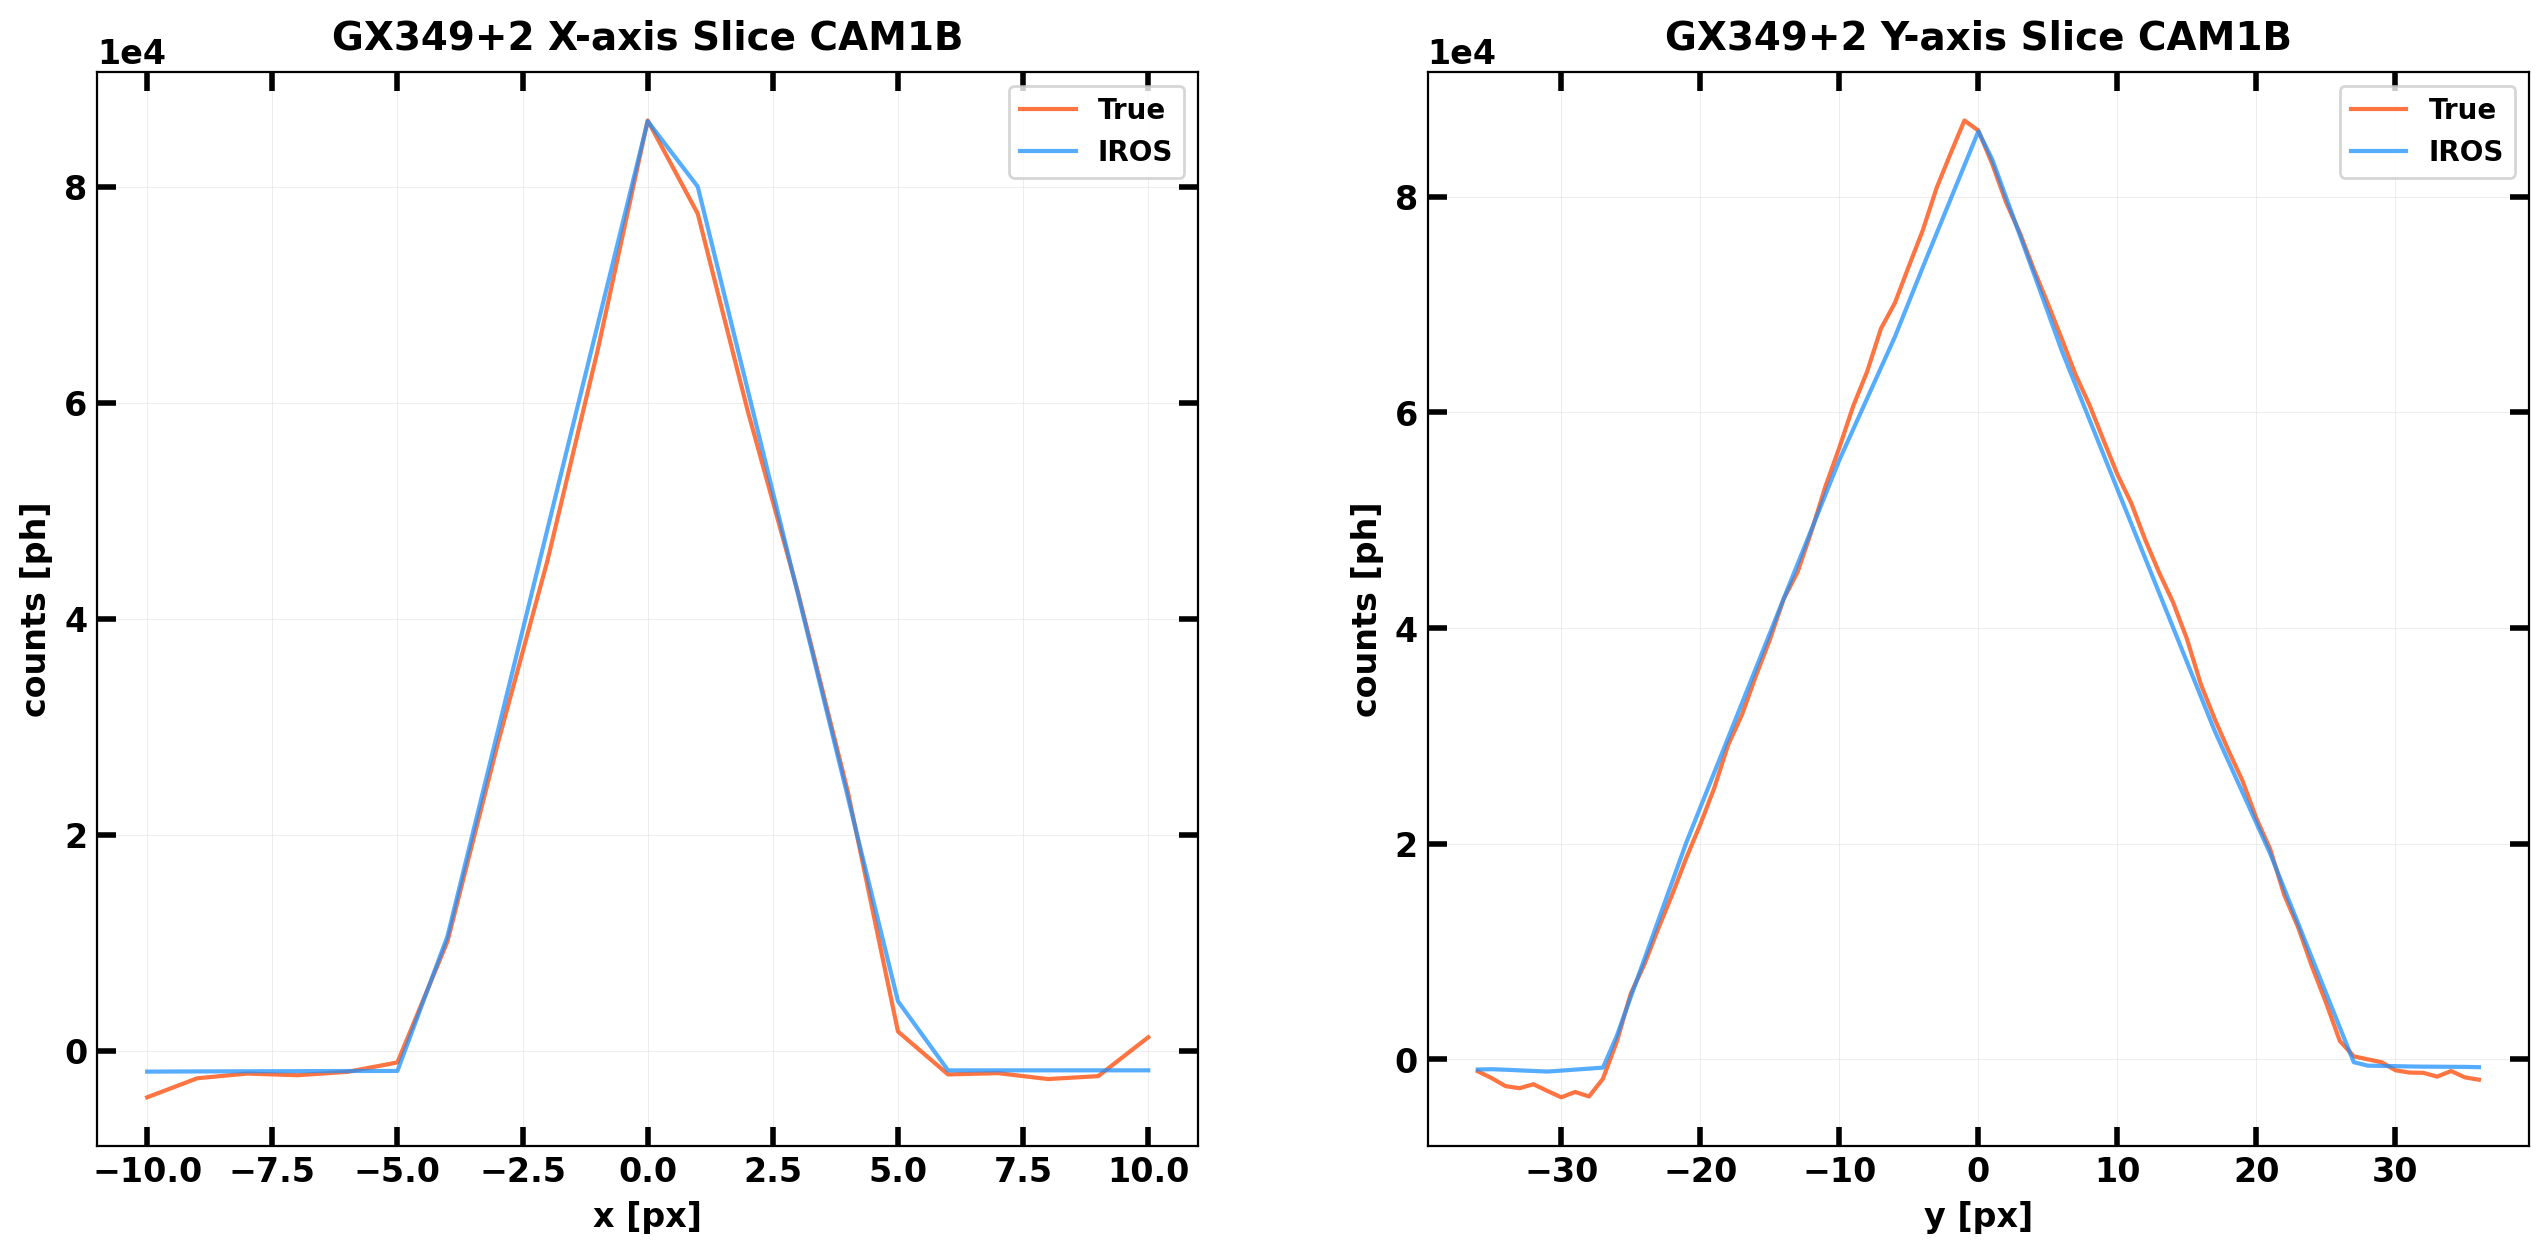

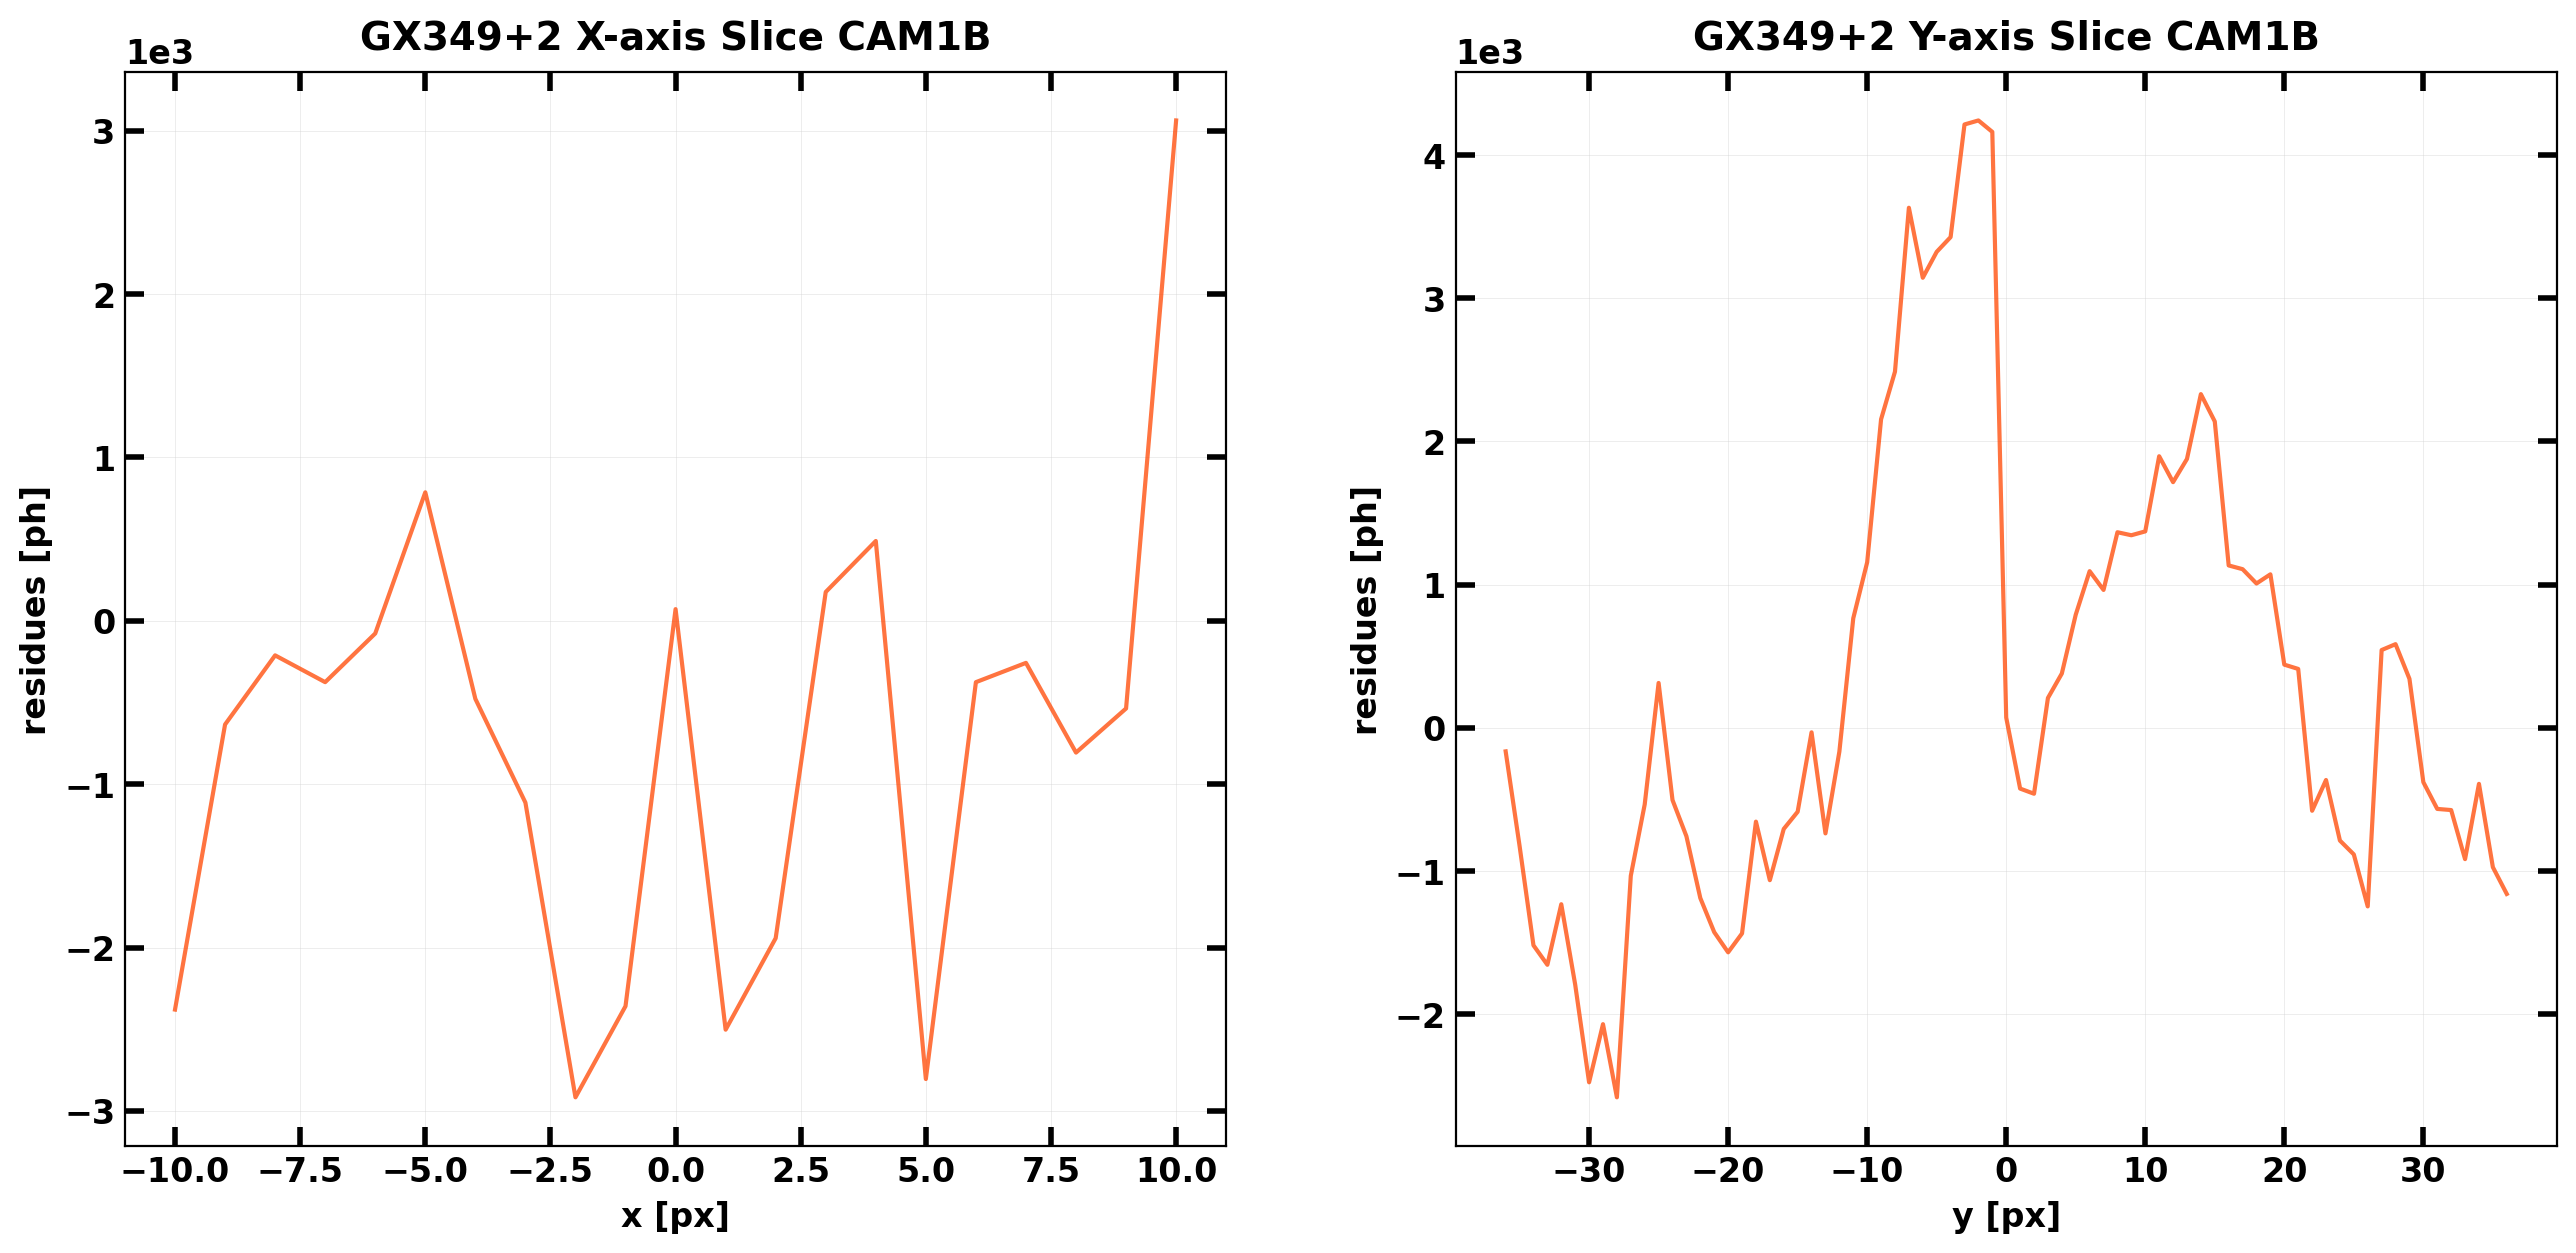

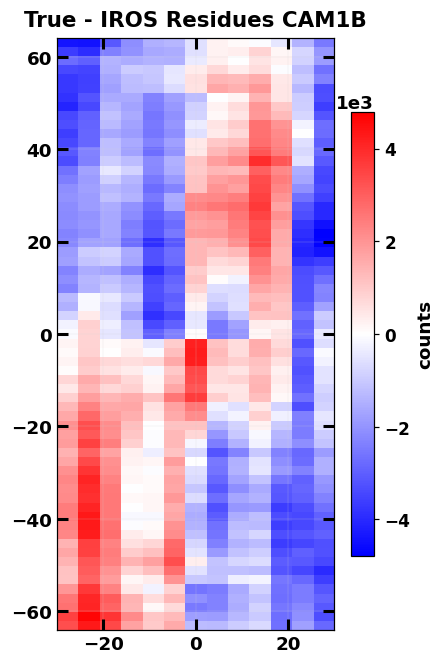

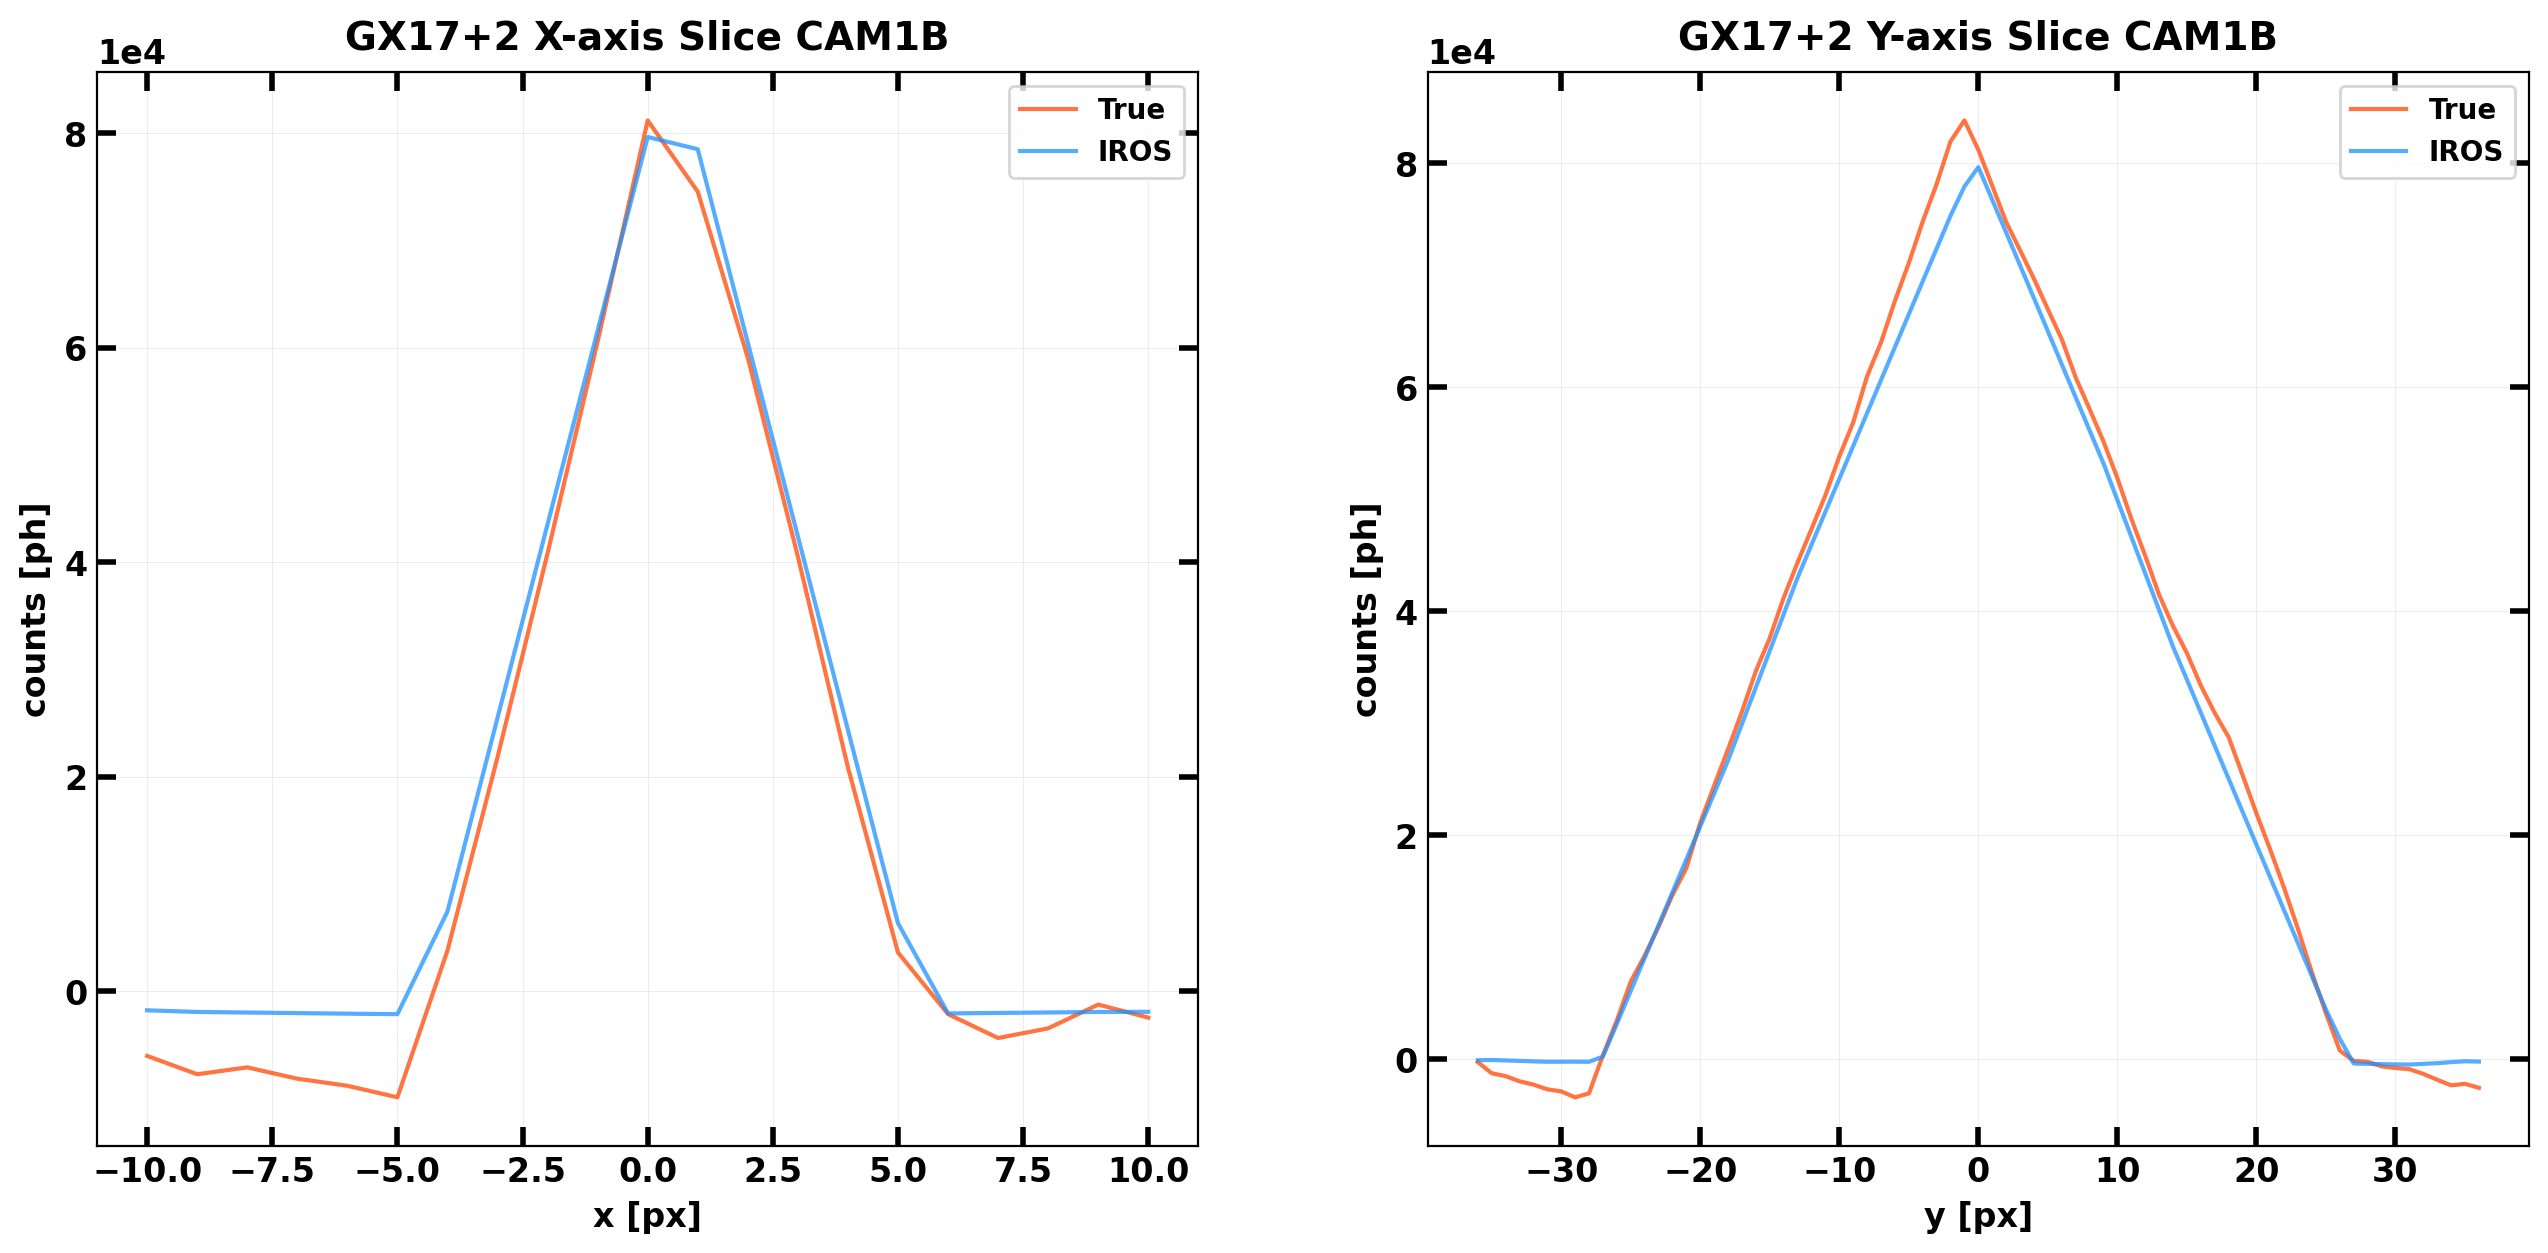

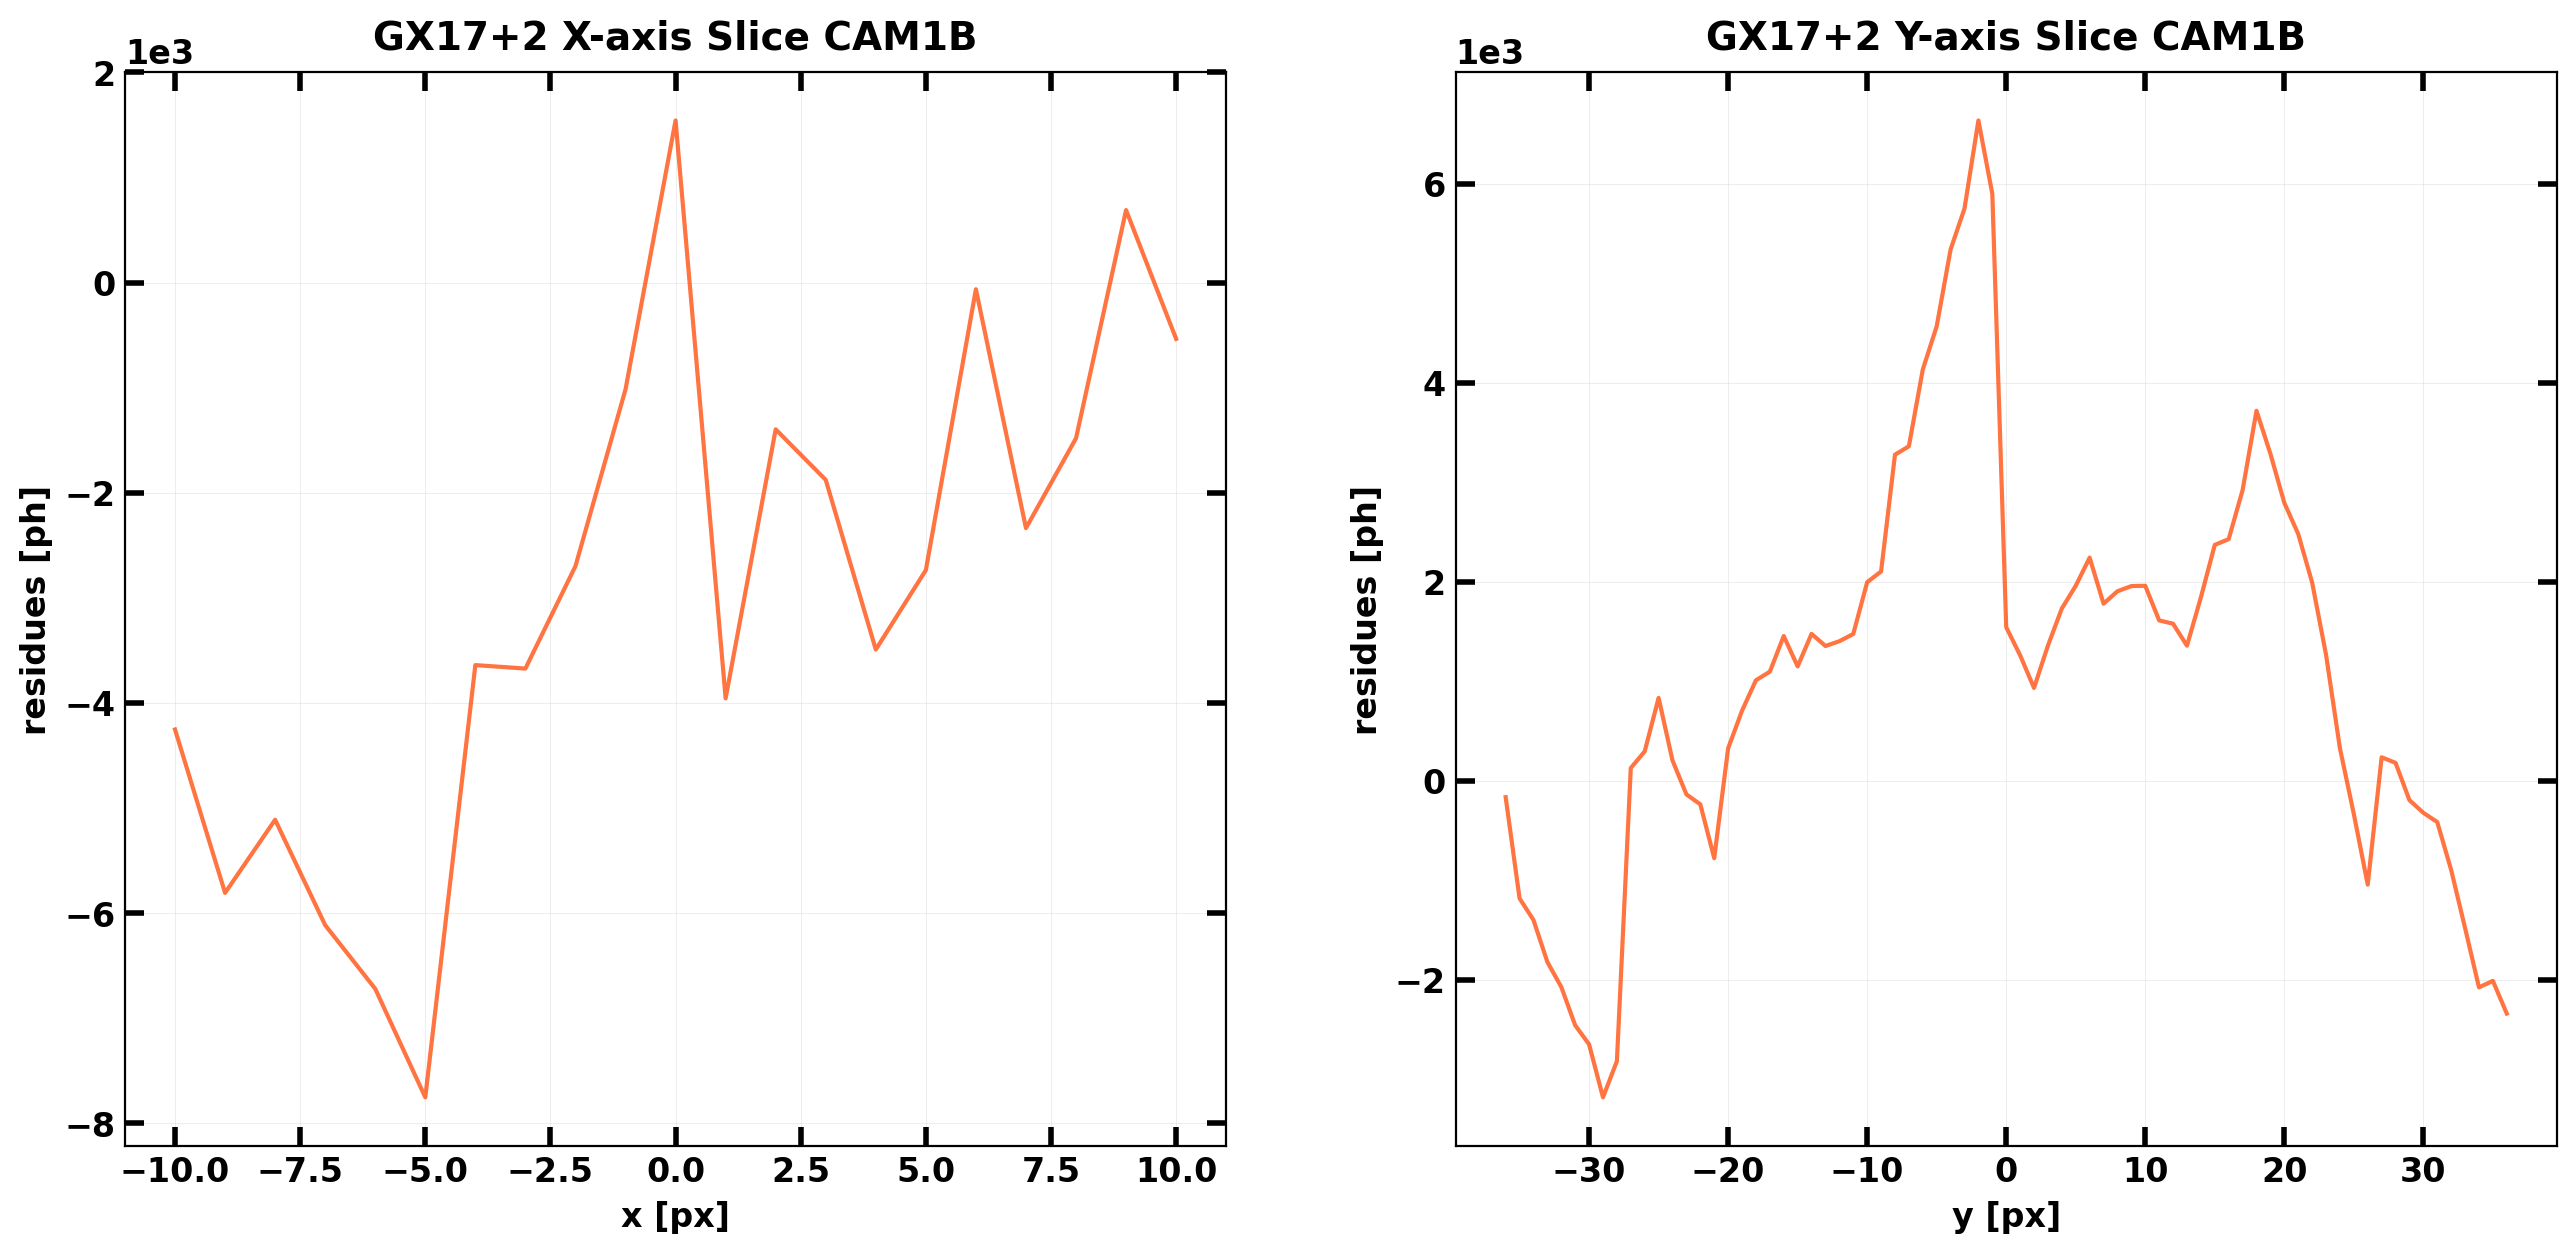

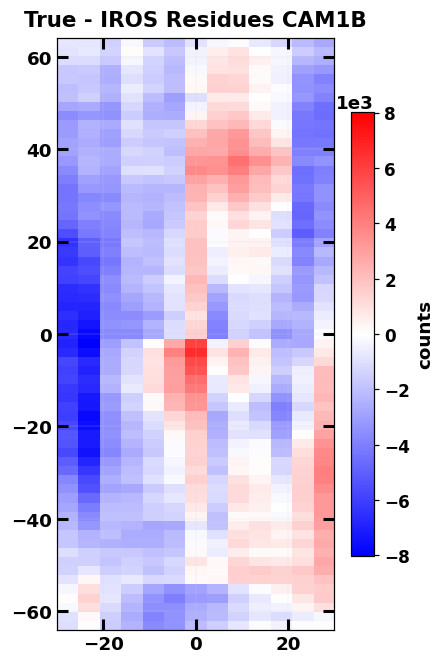

In [ ]:
assert False

from singleCAM_IROS._pipeline_support import _handle_dirpaths
from bloodmoon.mask import codedmask
import darksun as ds


#### test SCOX-1 PSF with:
#       - real mask
#       - ideal detector
#       - vignetting OFF

skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing_optimizerNoPeak_vignettingOFF"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

#filepaths = simulation_files(simul_data)
#sdlA = ds.get_data(filepaths[cam_a][dataset])
#catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")


crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=crp,
    camera=wfm,
    vignetting=False,
    psfy=False,
    #savepath=is_img,
)
ds.reconstruction_plot(
    true_sky=simul_sky_camB,
    log=log_camB,
    crp=crp,
    camera=wfm,
    vignetting=False,
    psfy=False,
    #savepath=is_img,
)

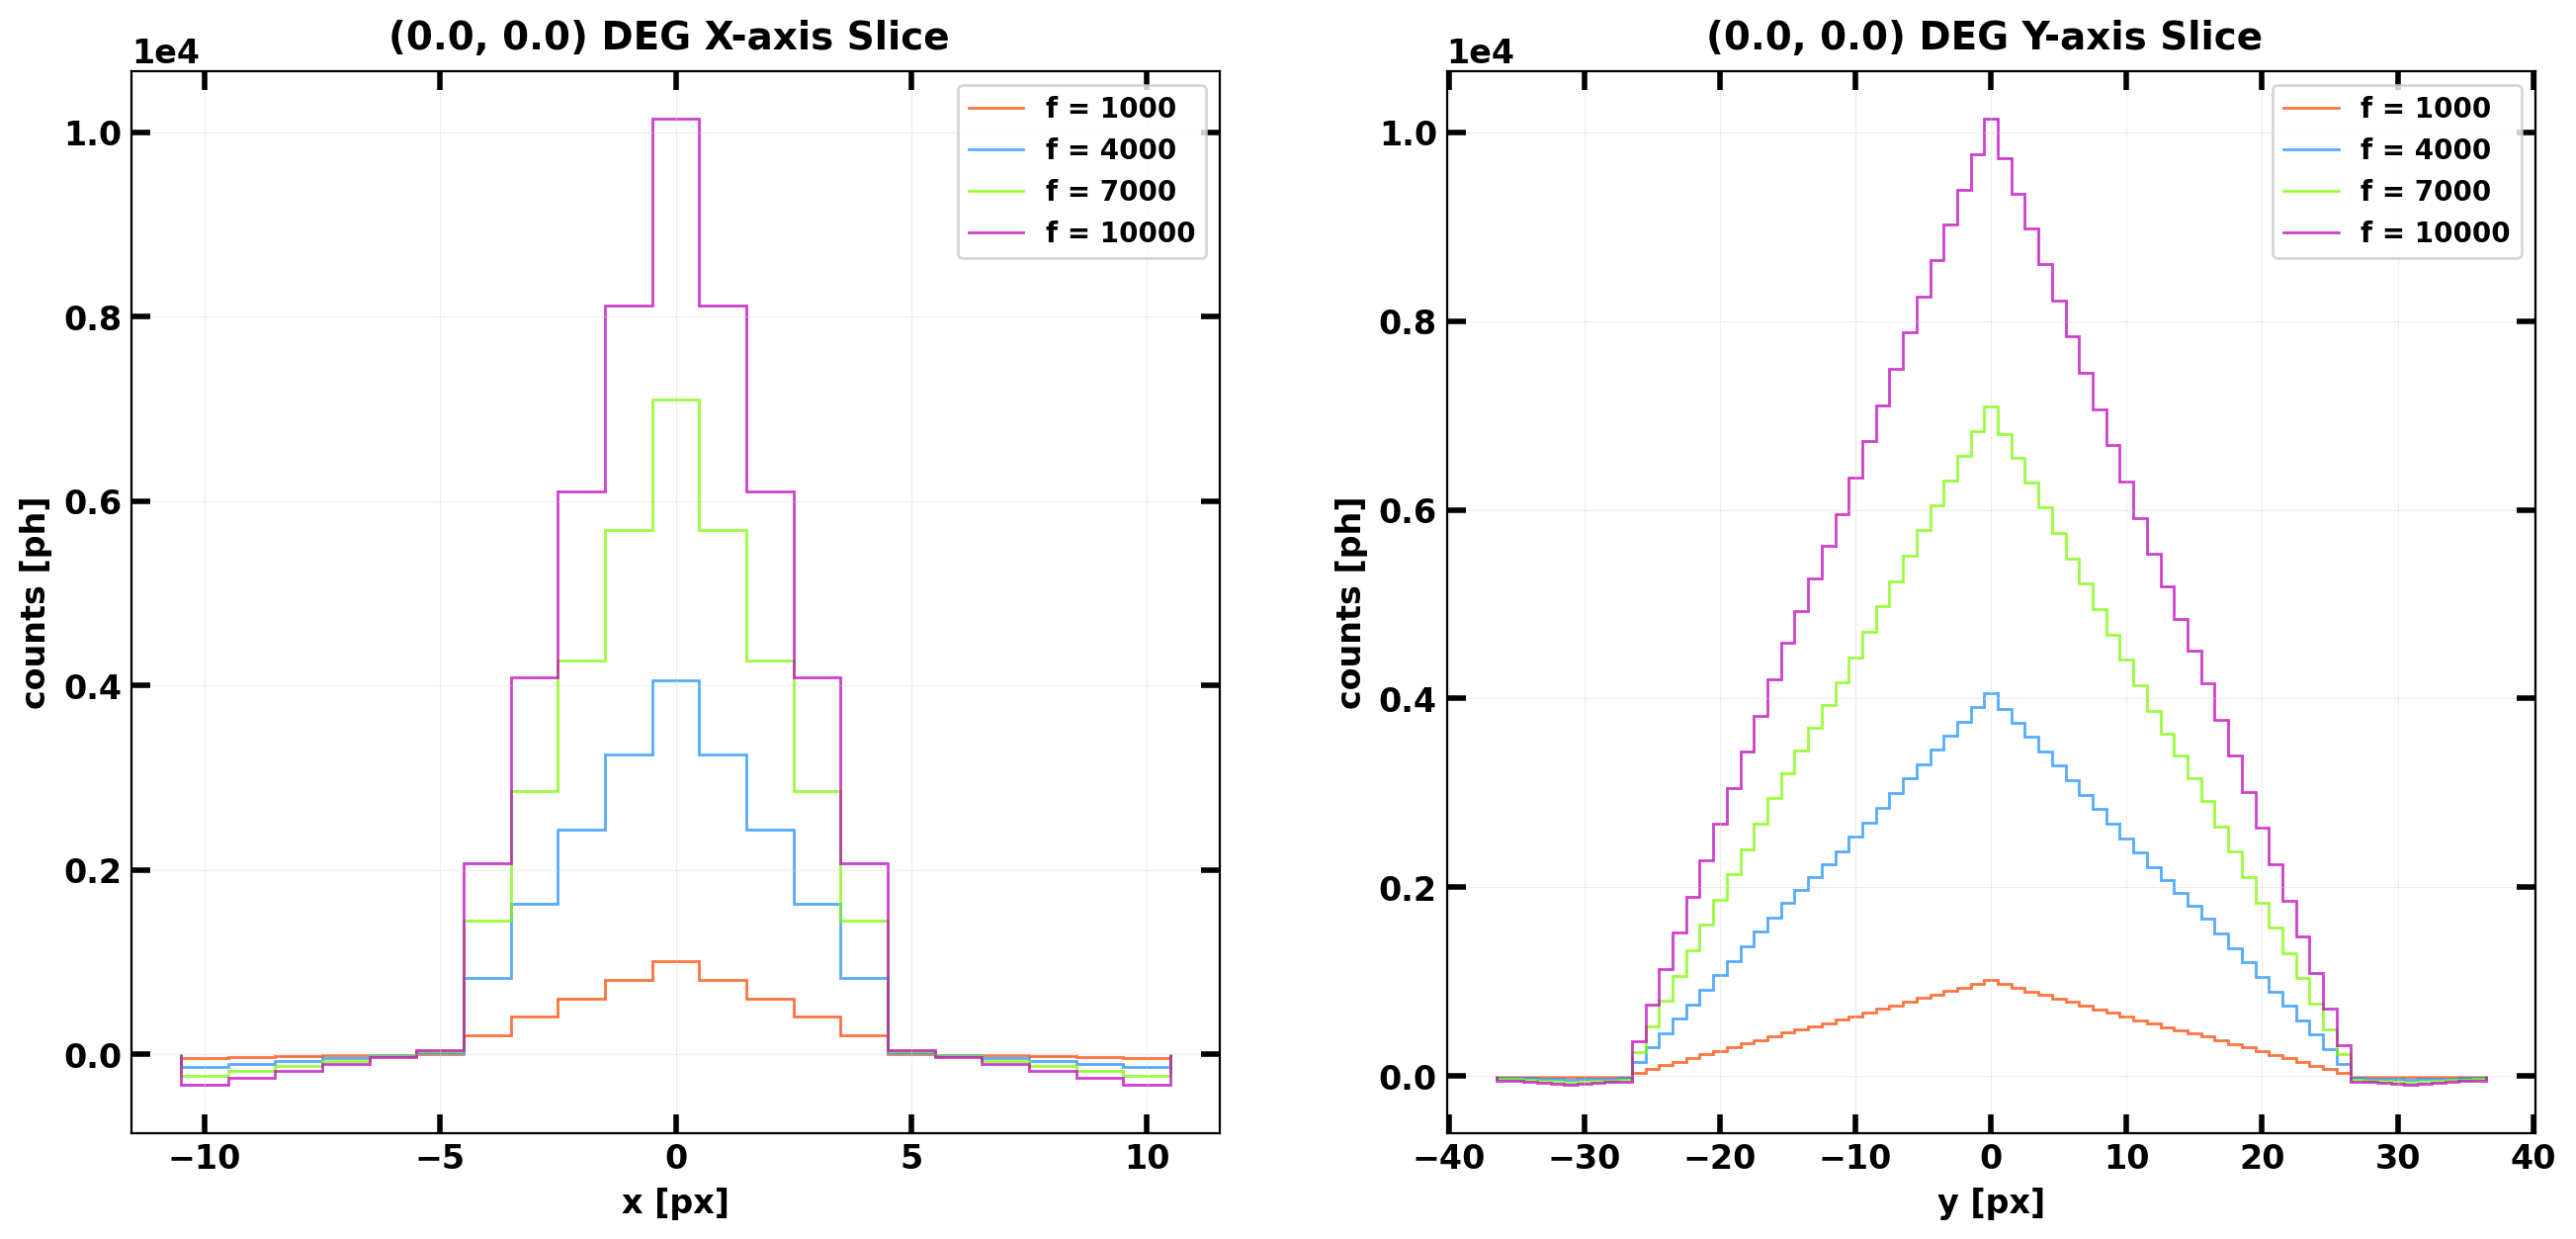

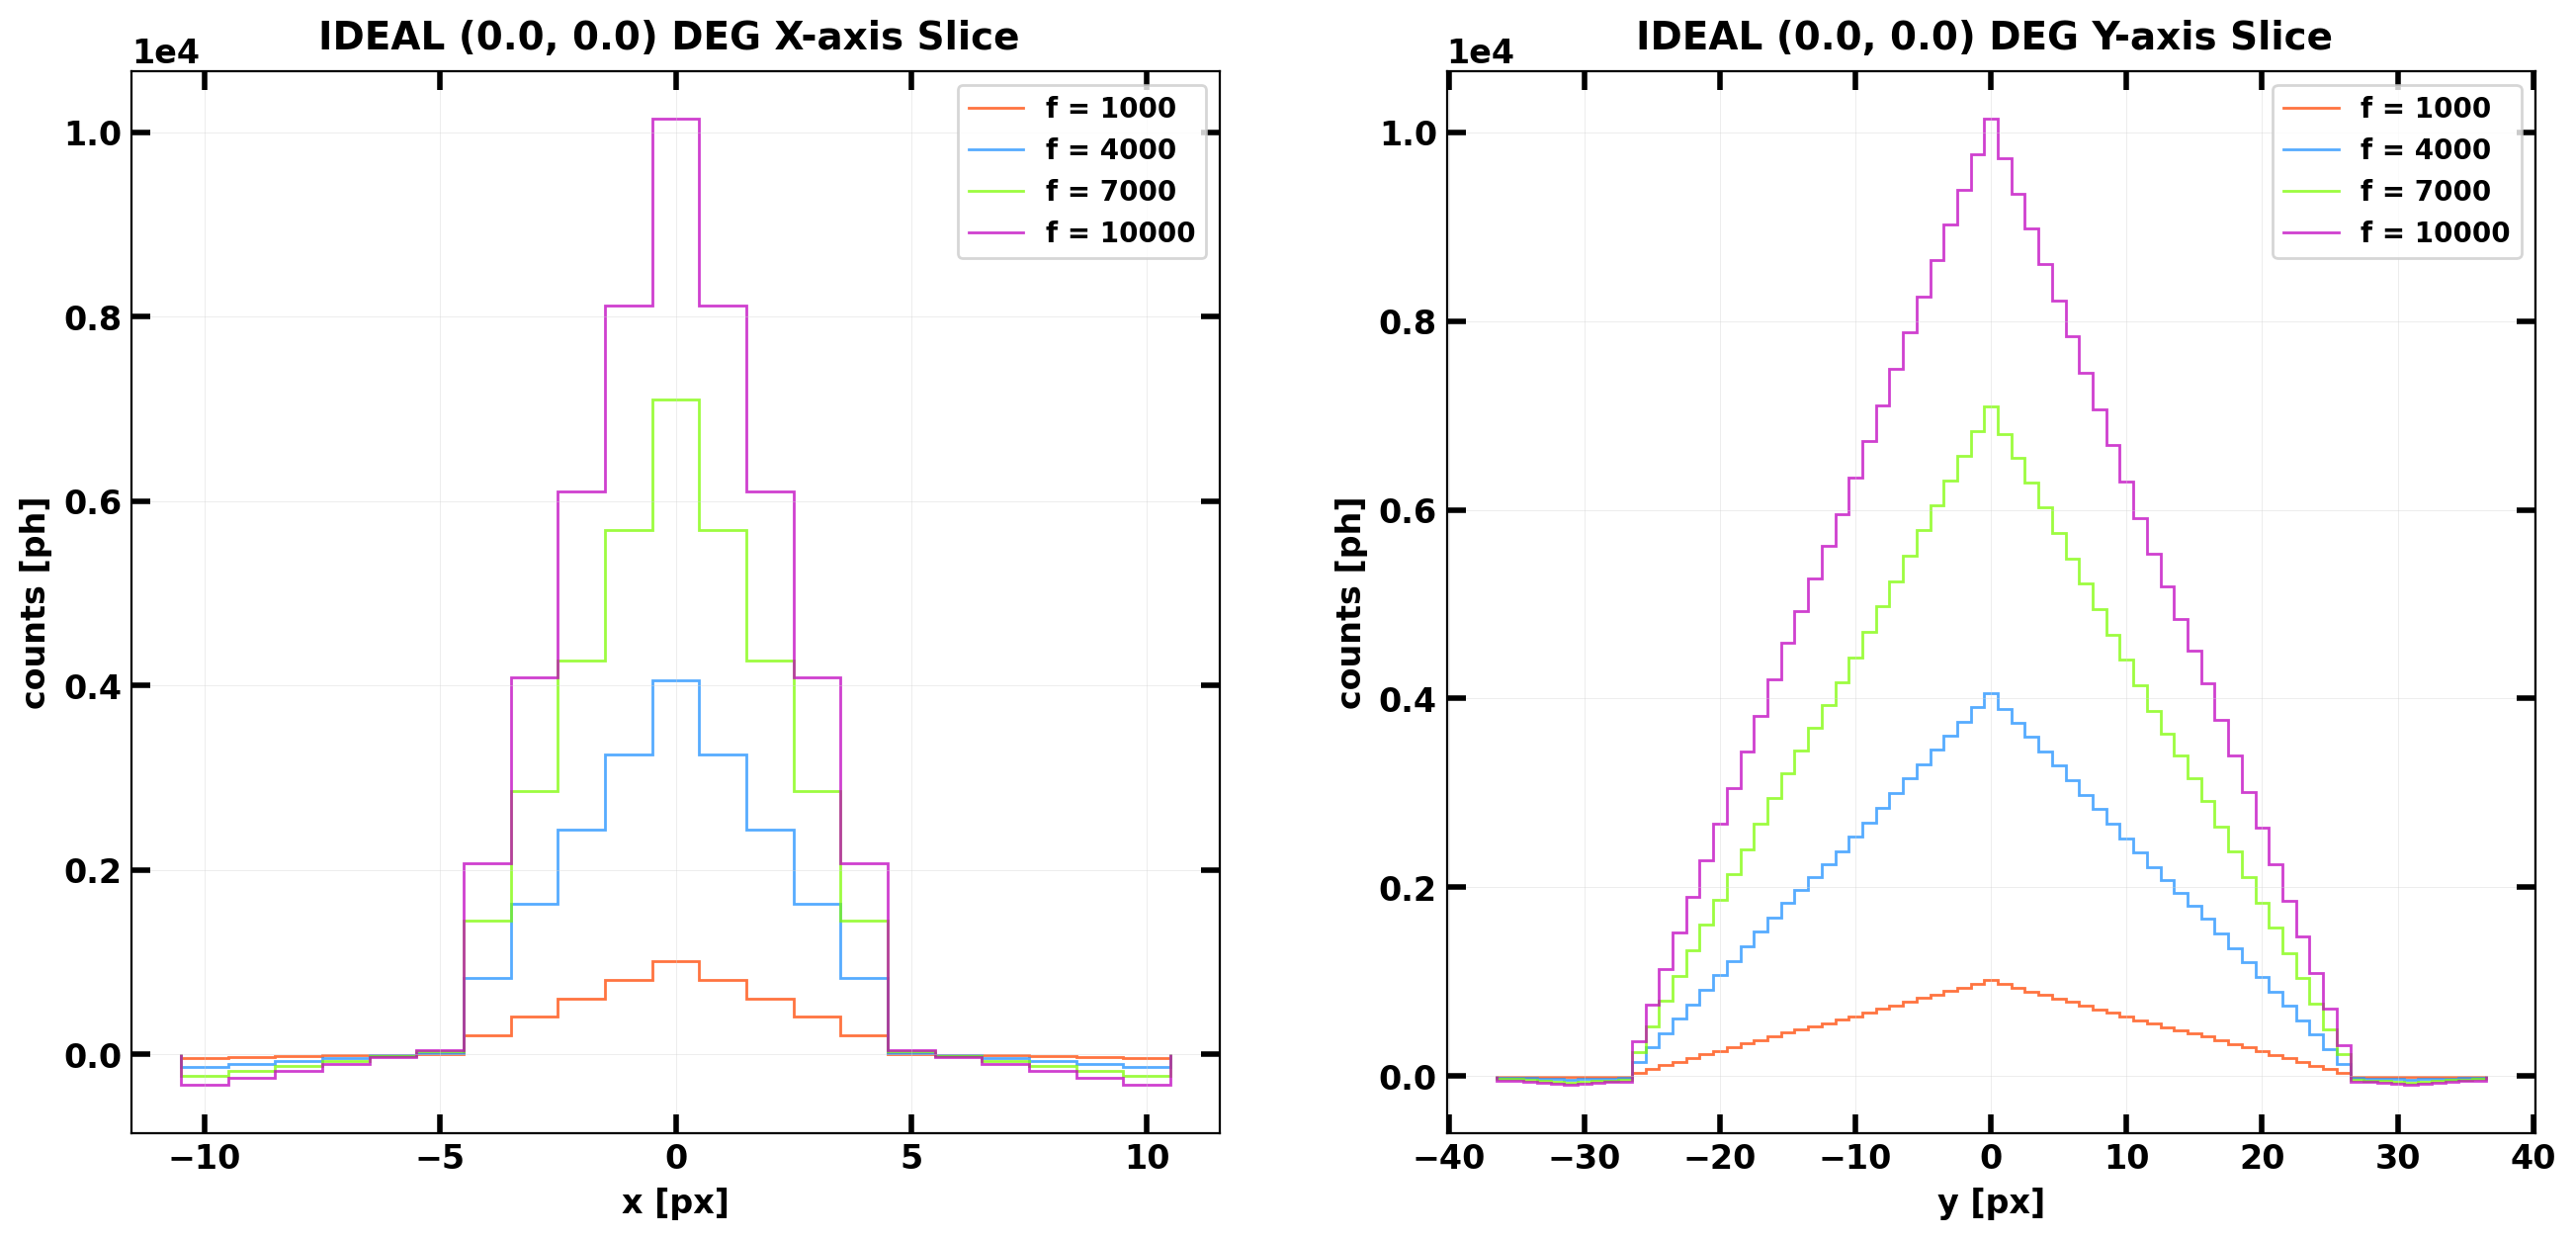

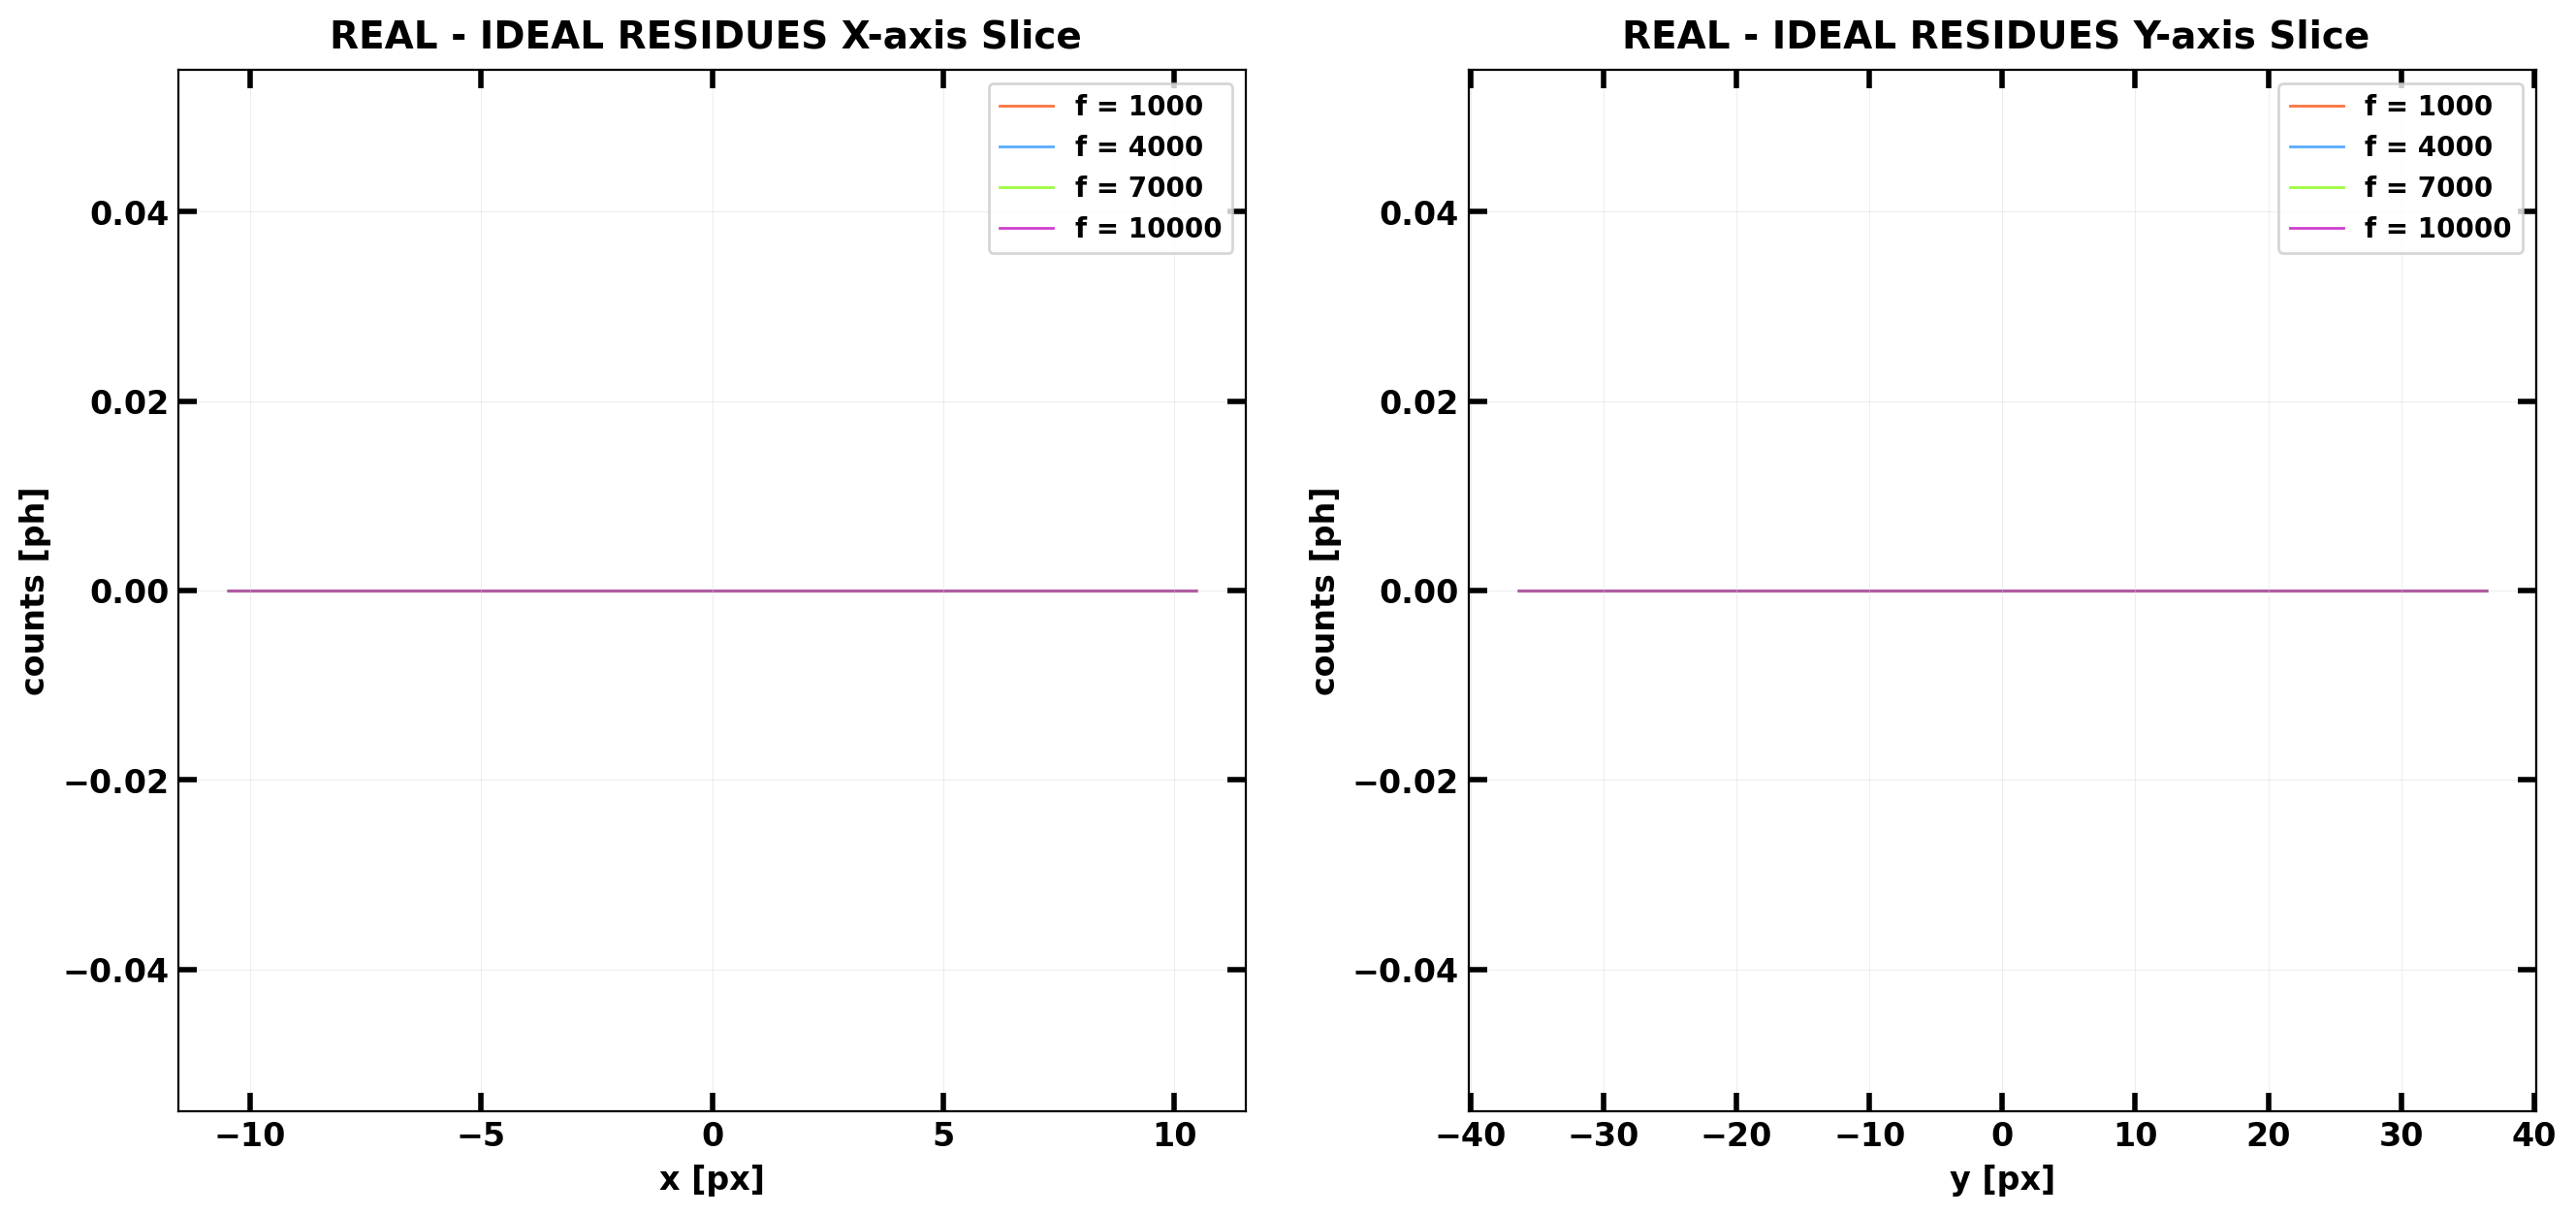

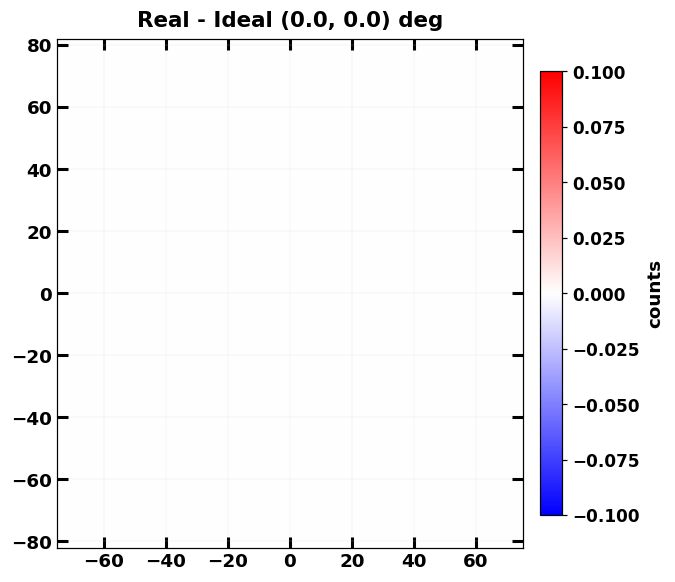

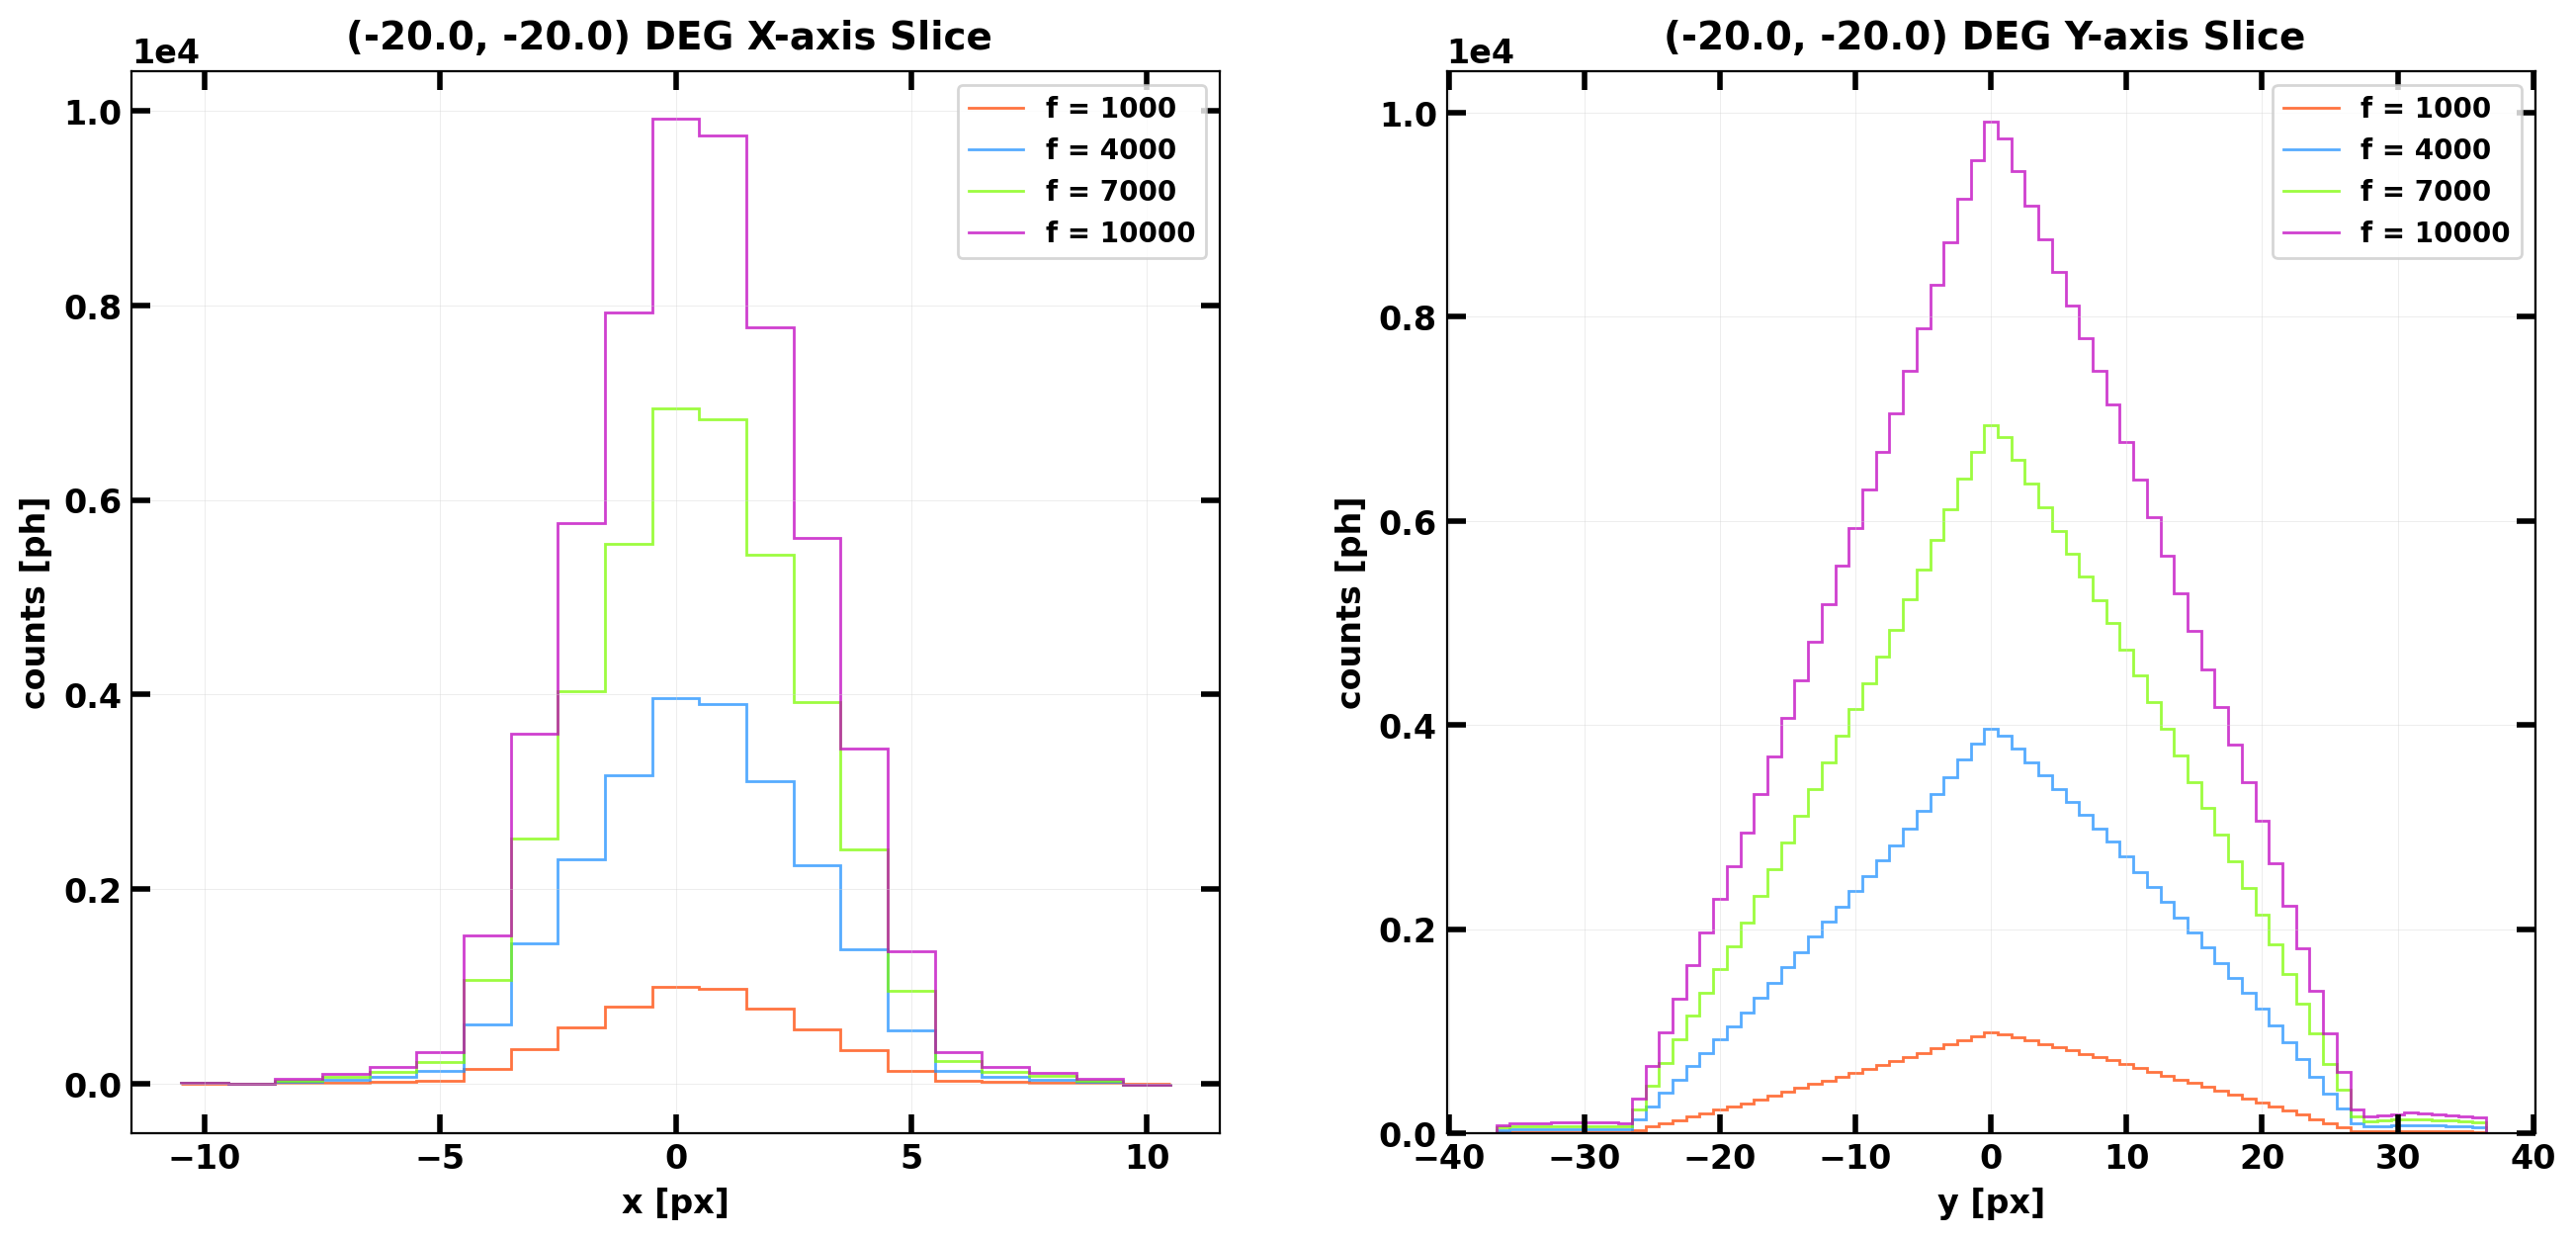

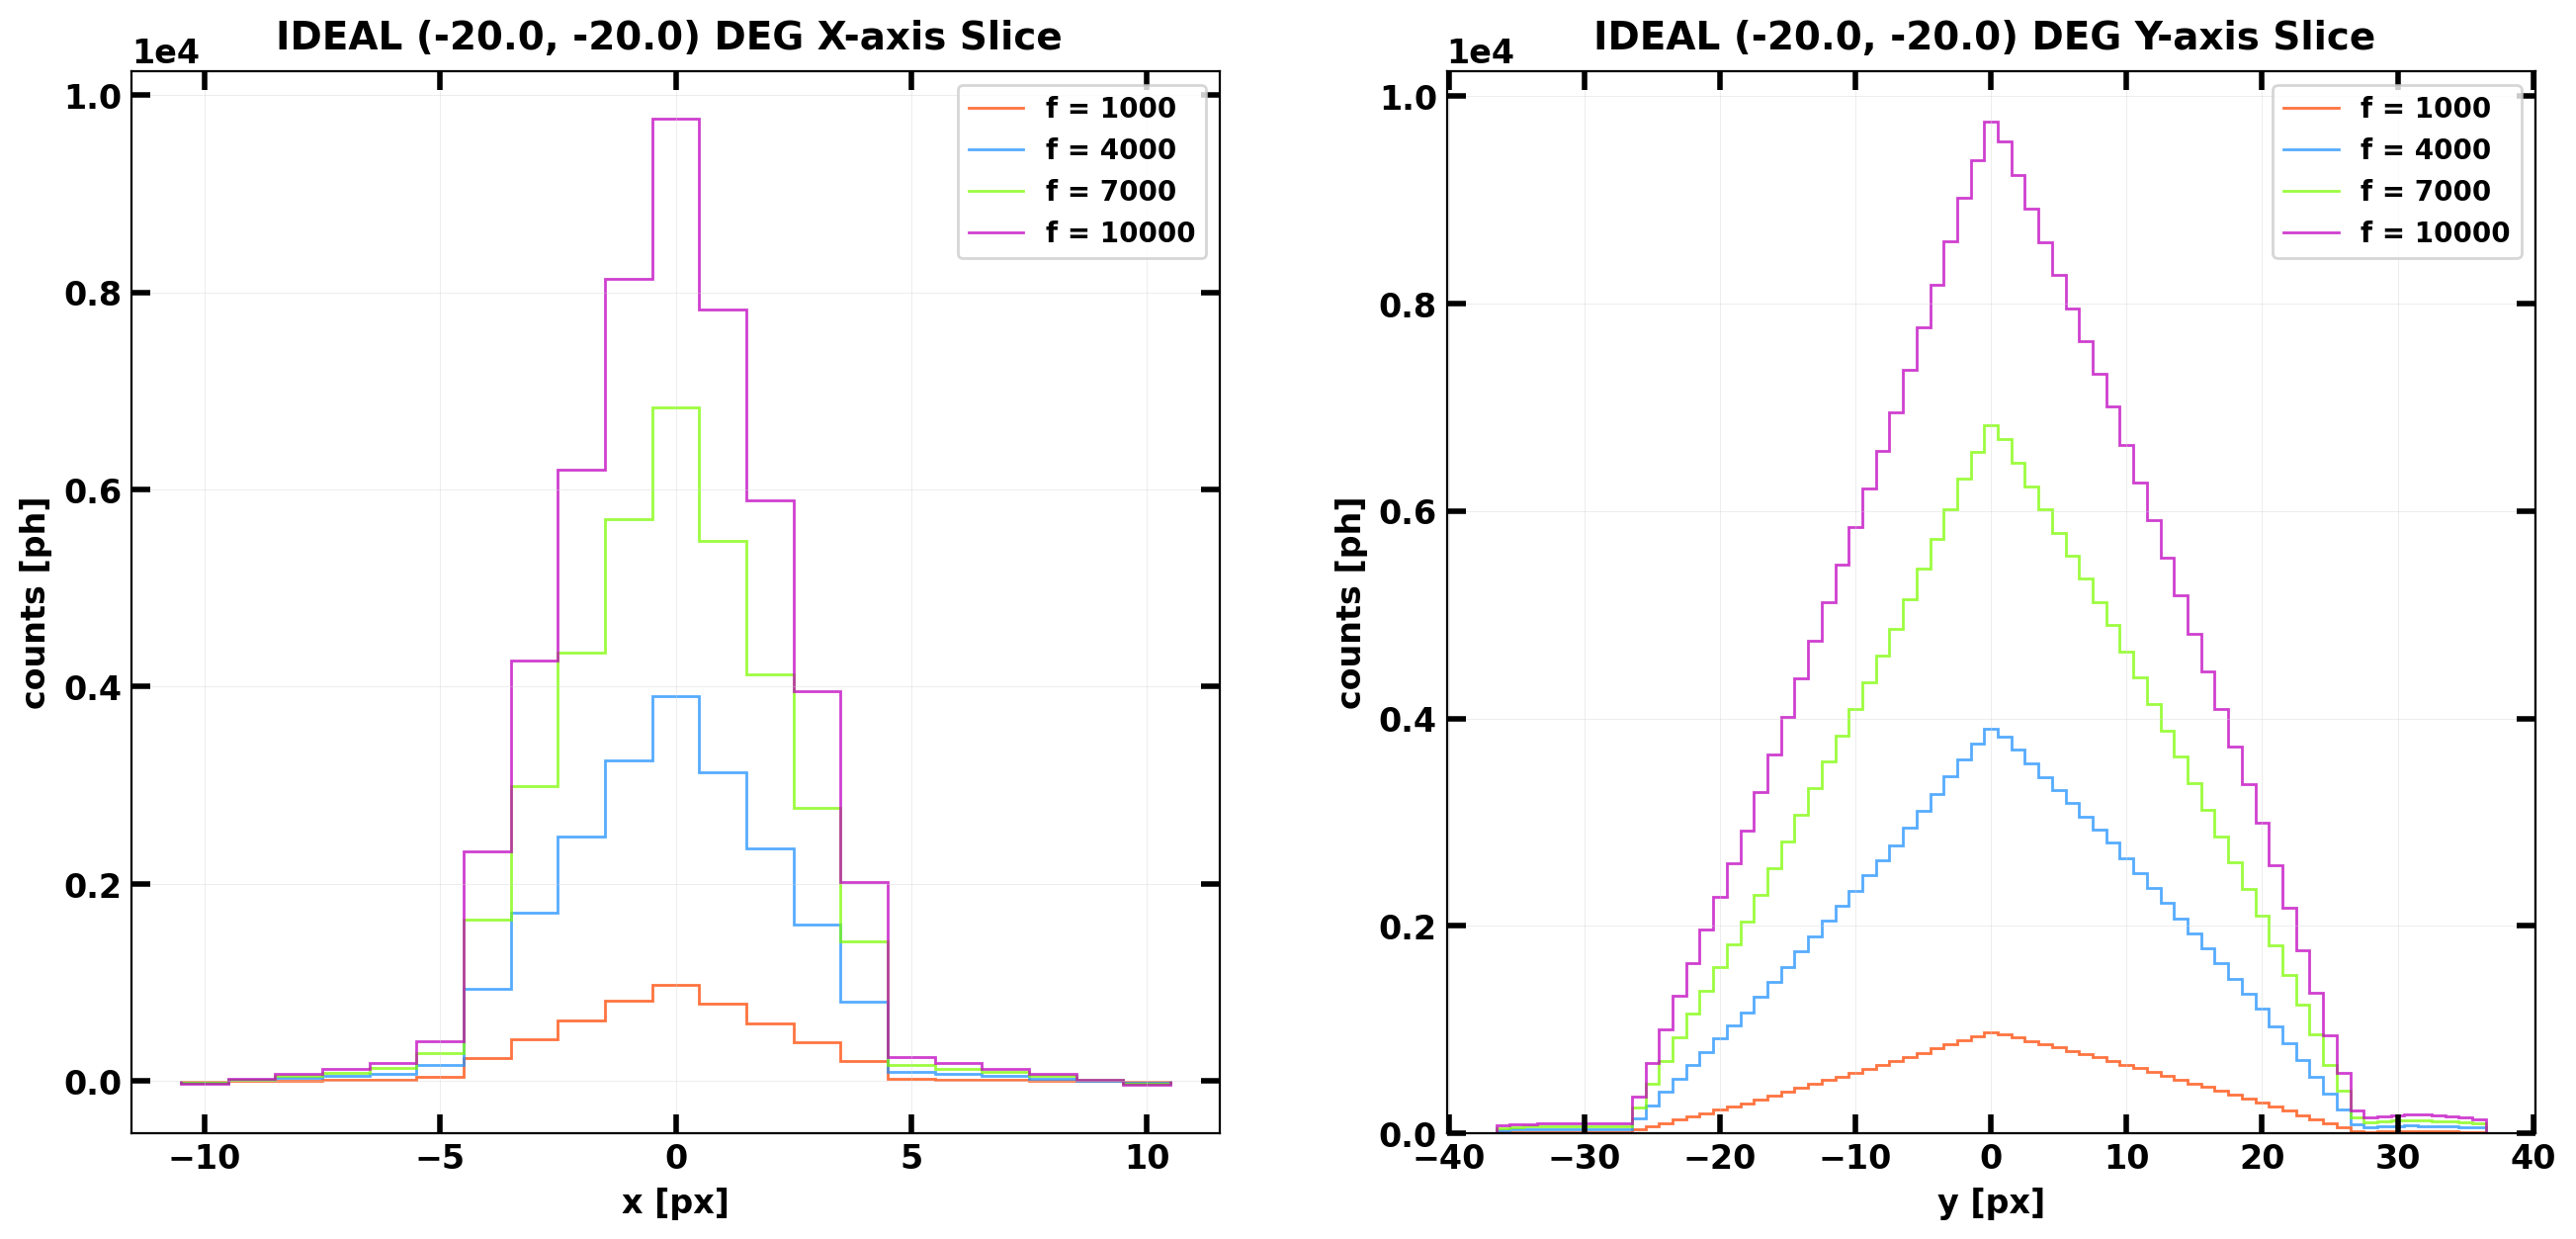

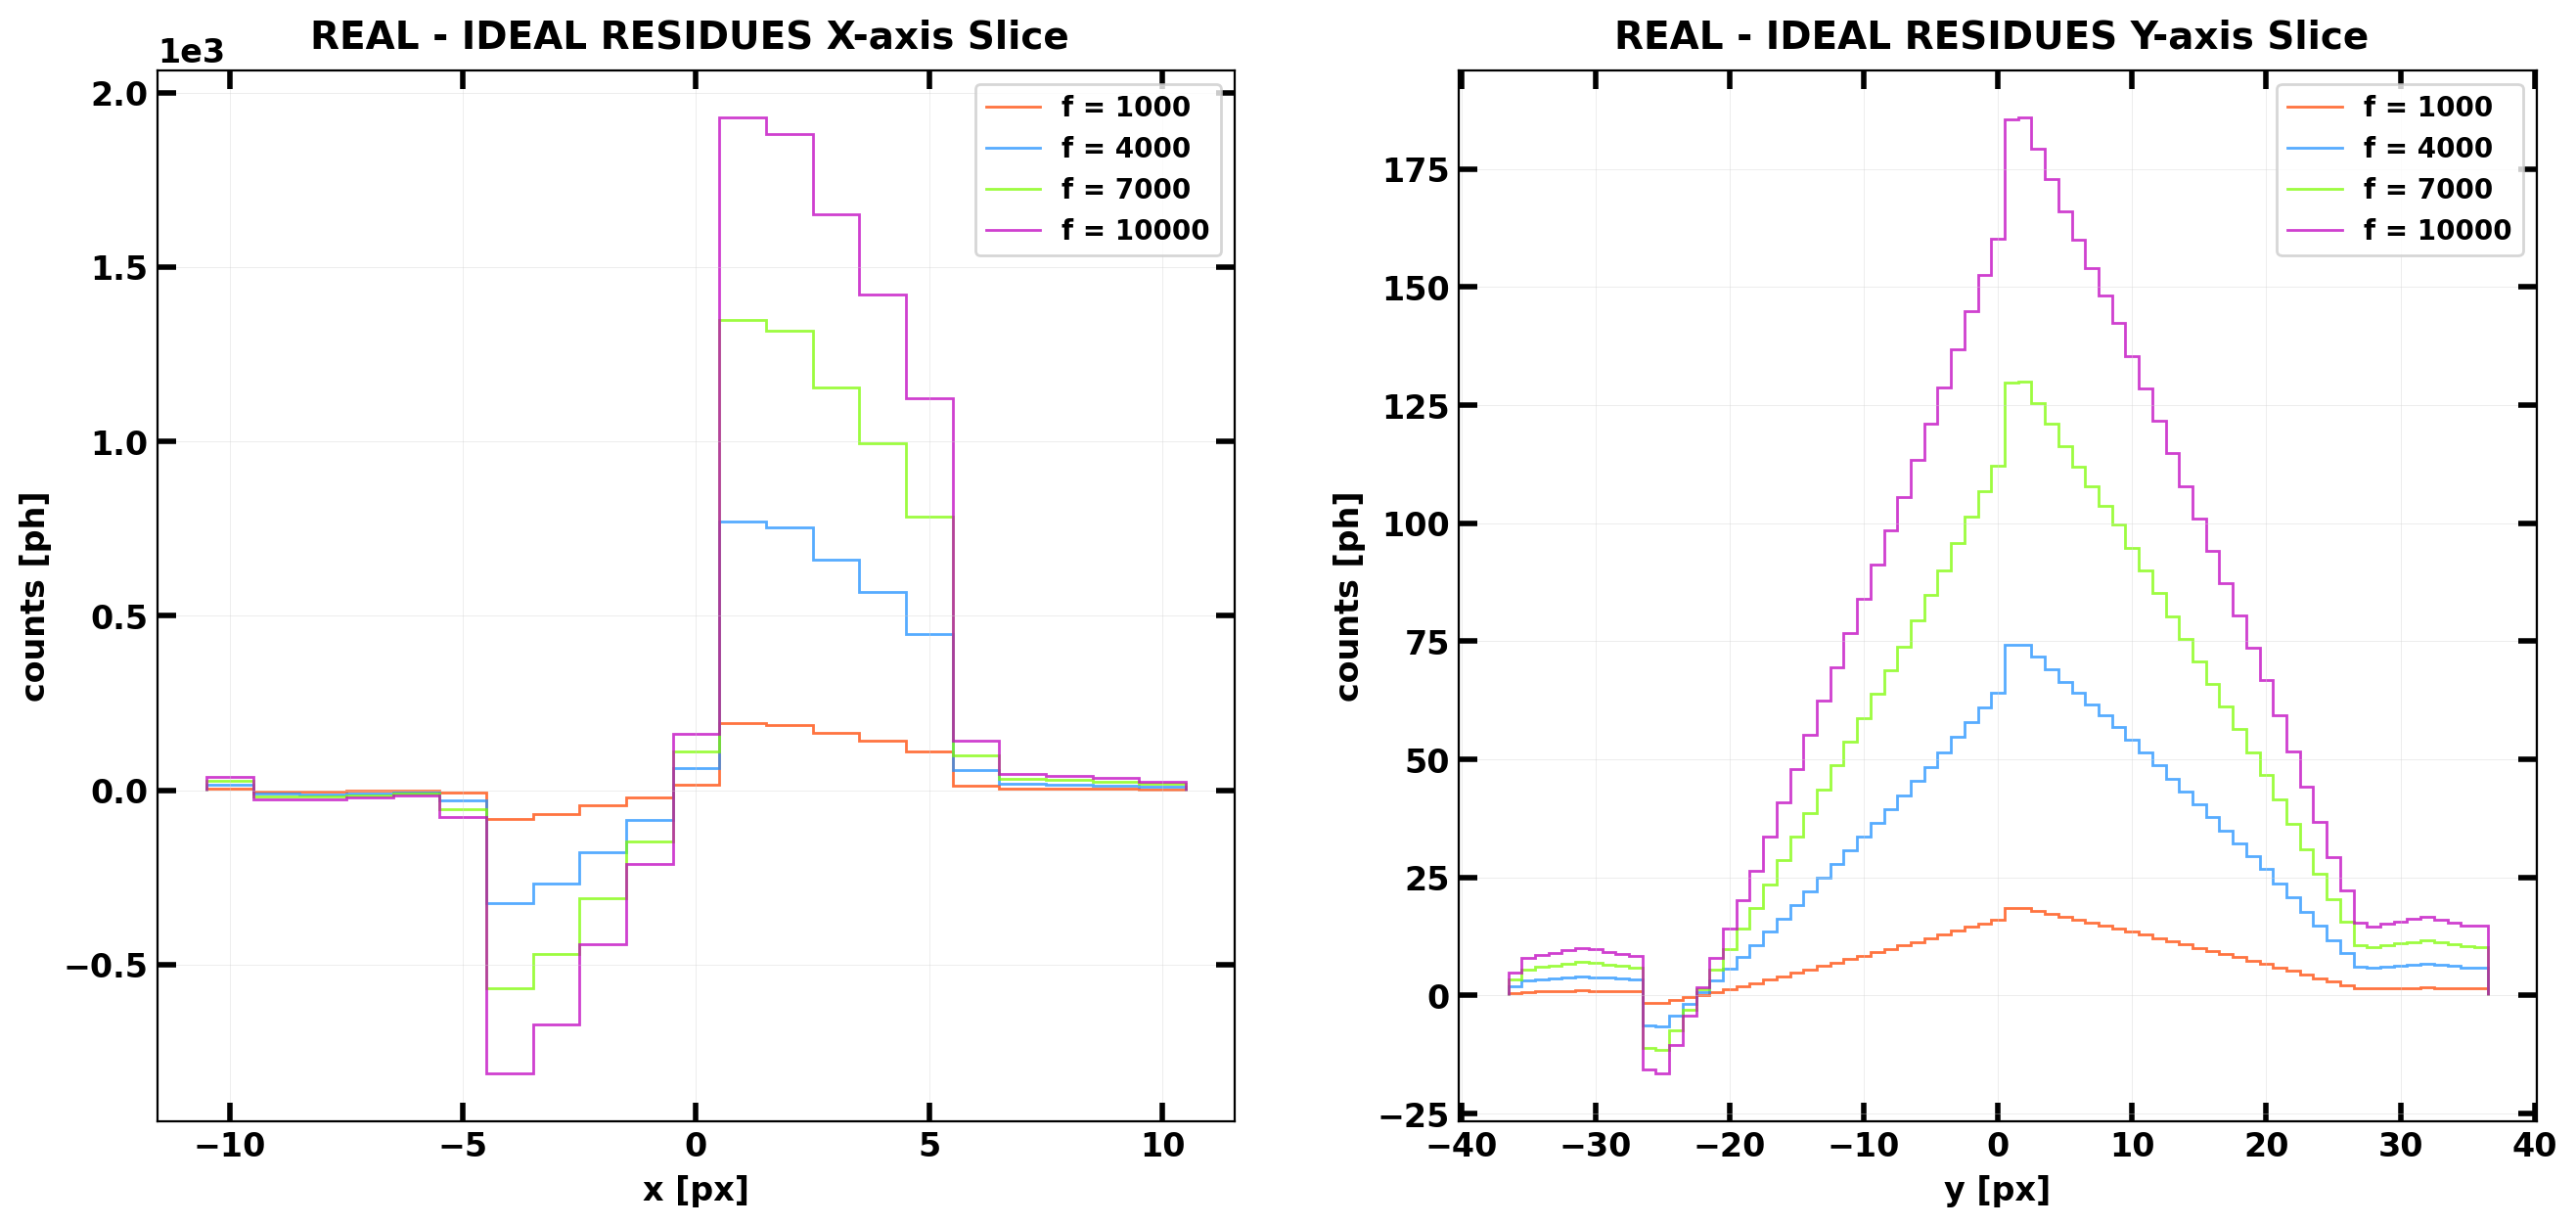

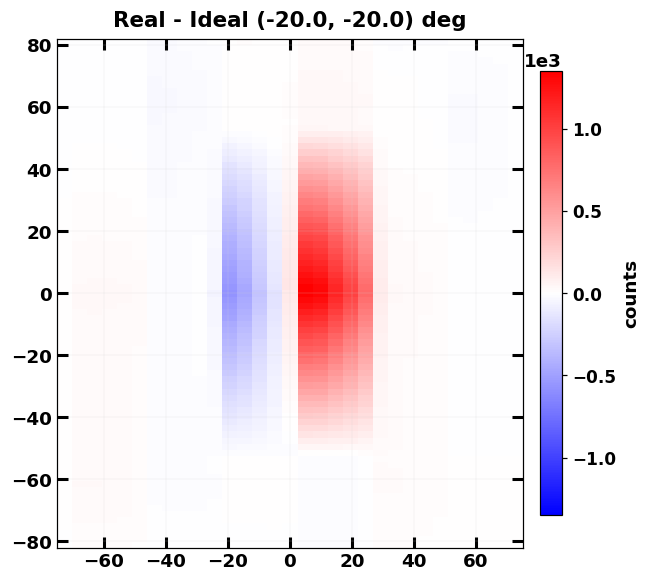

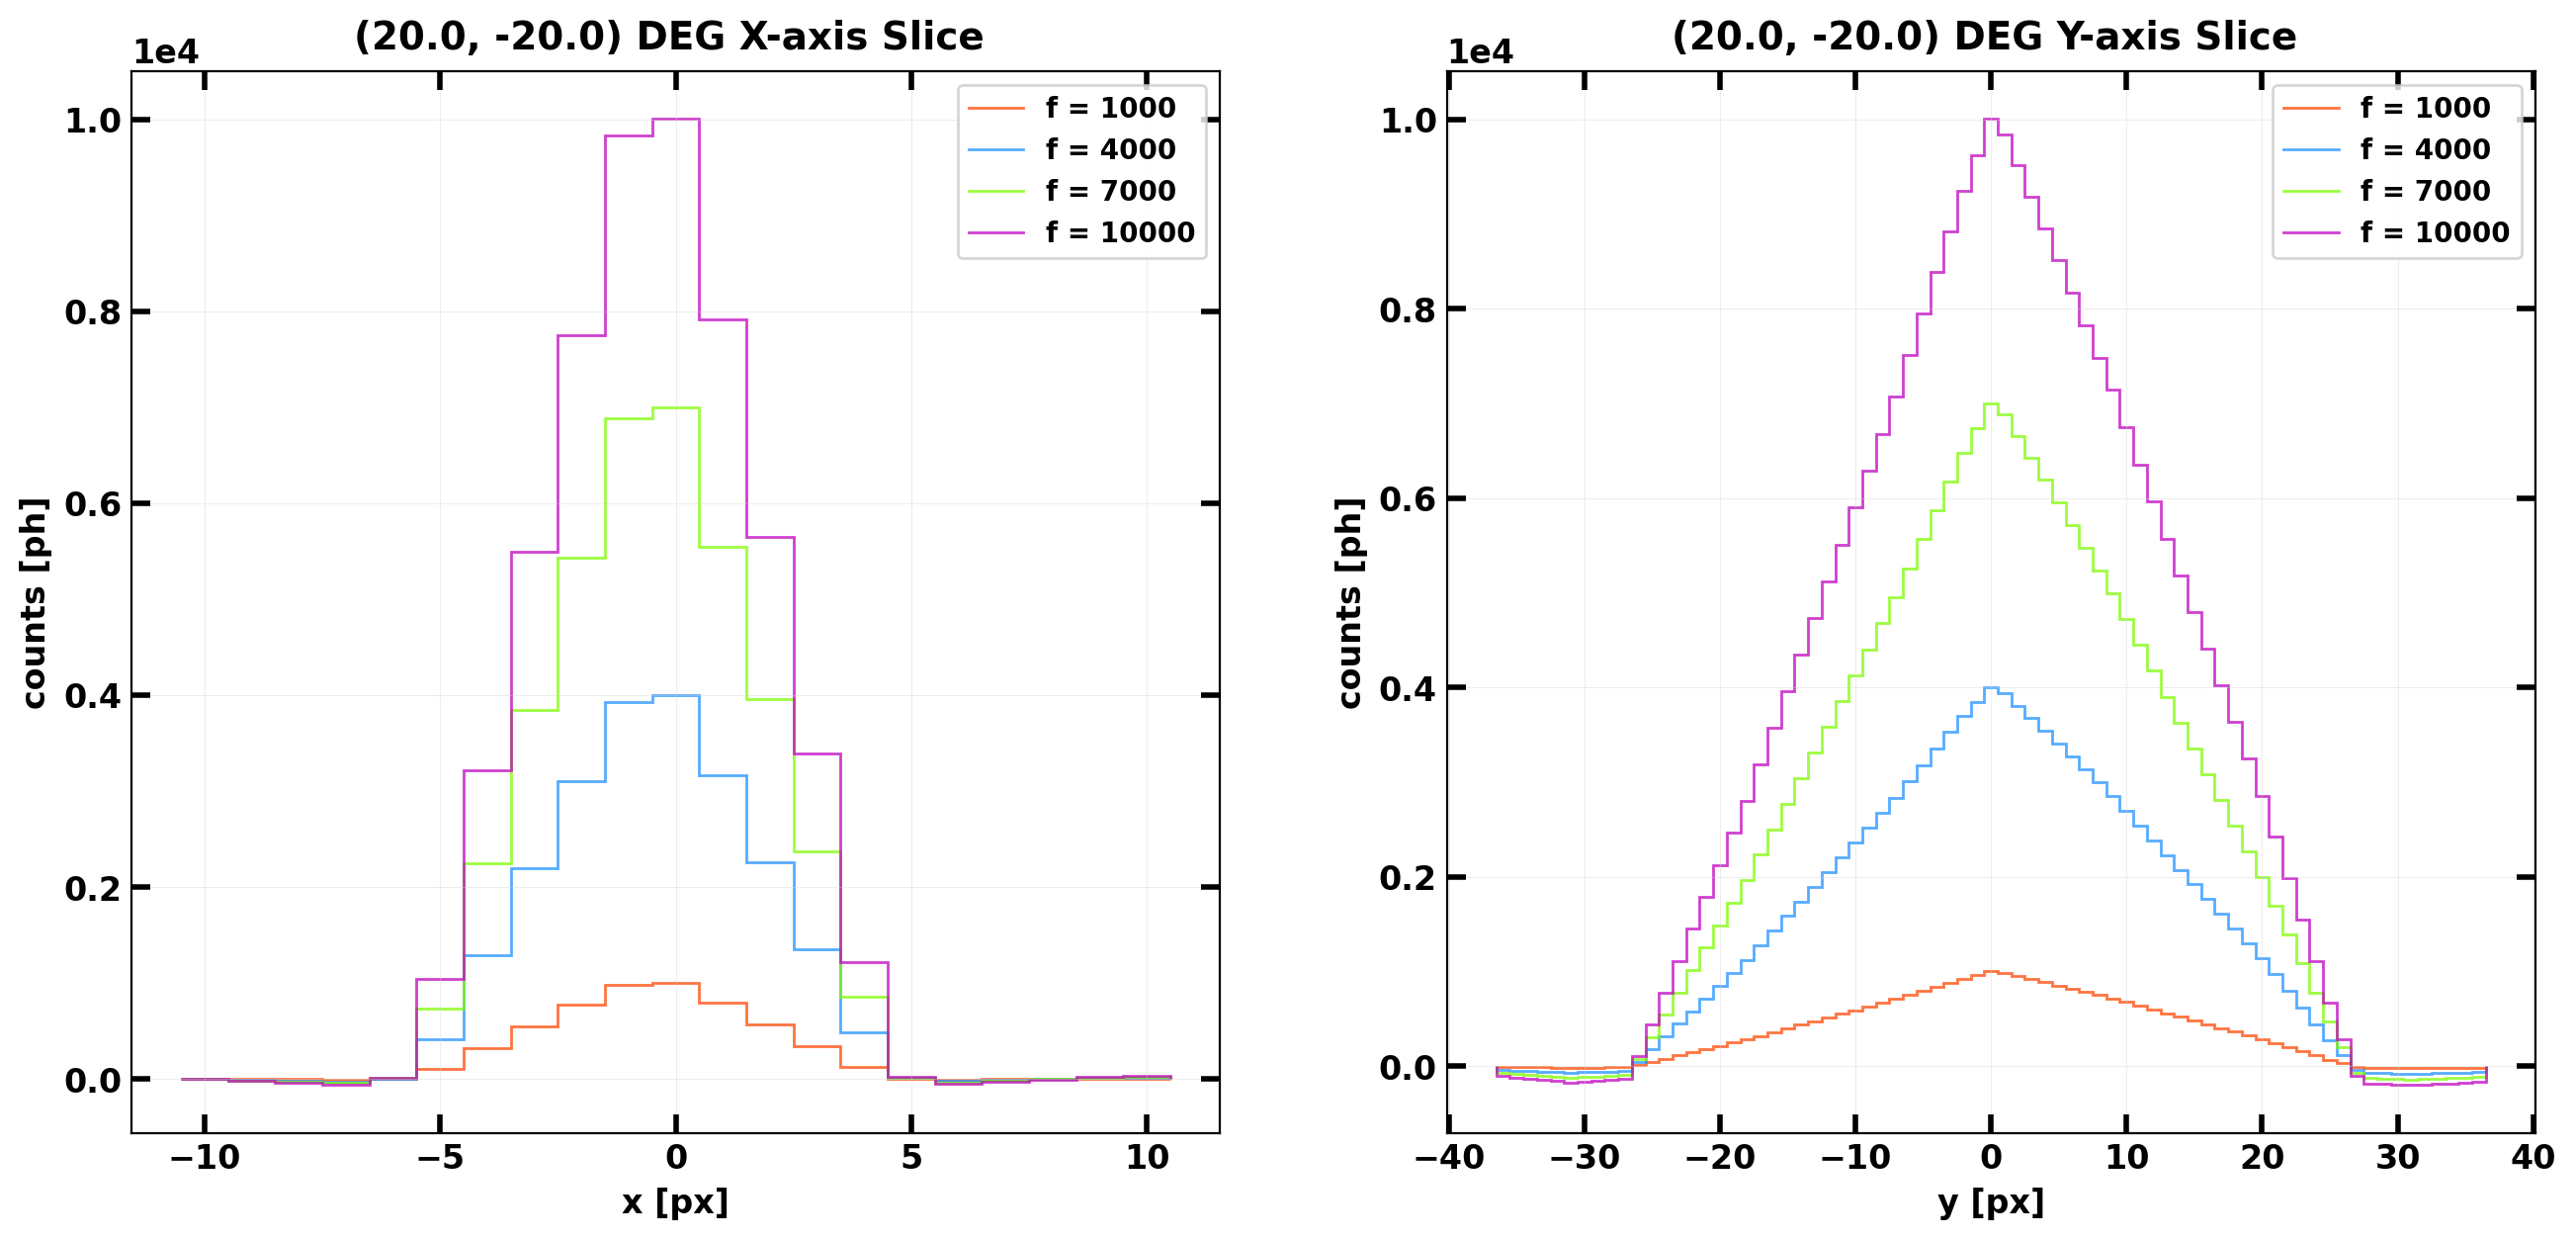

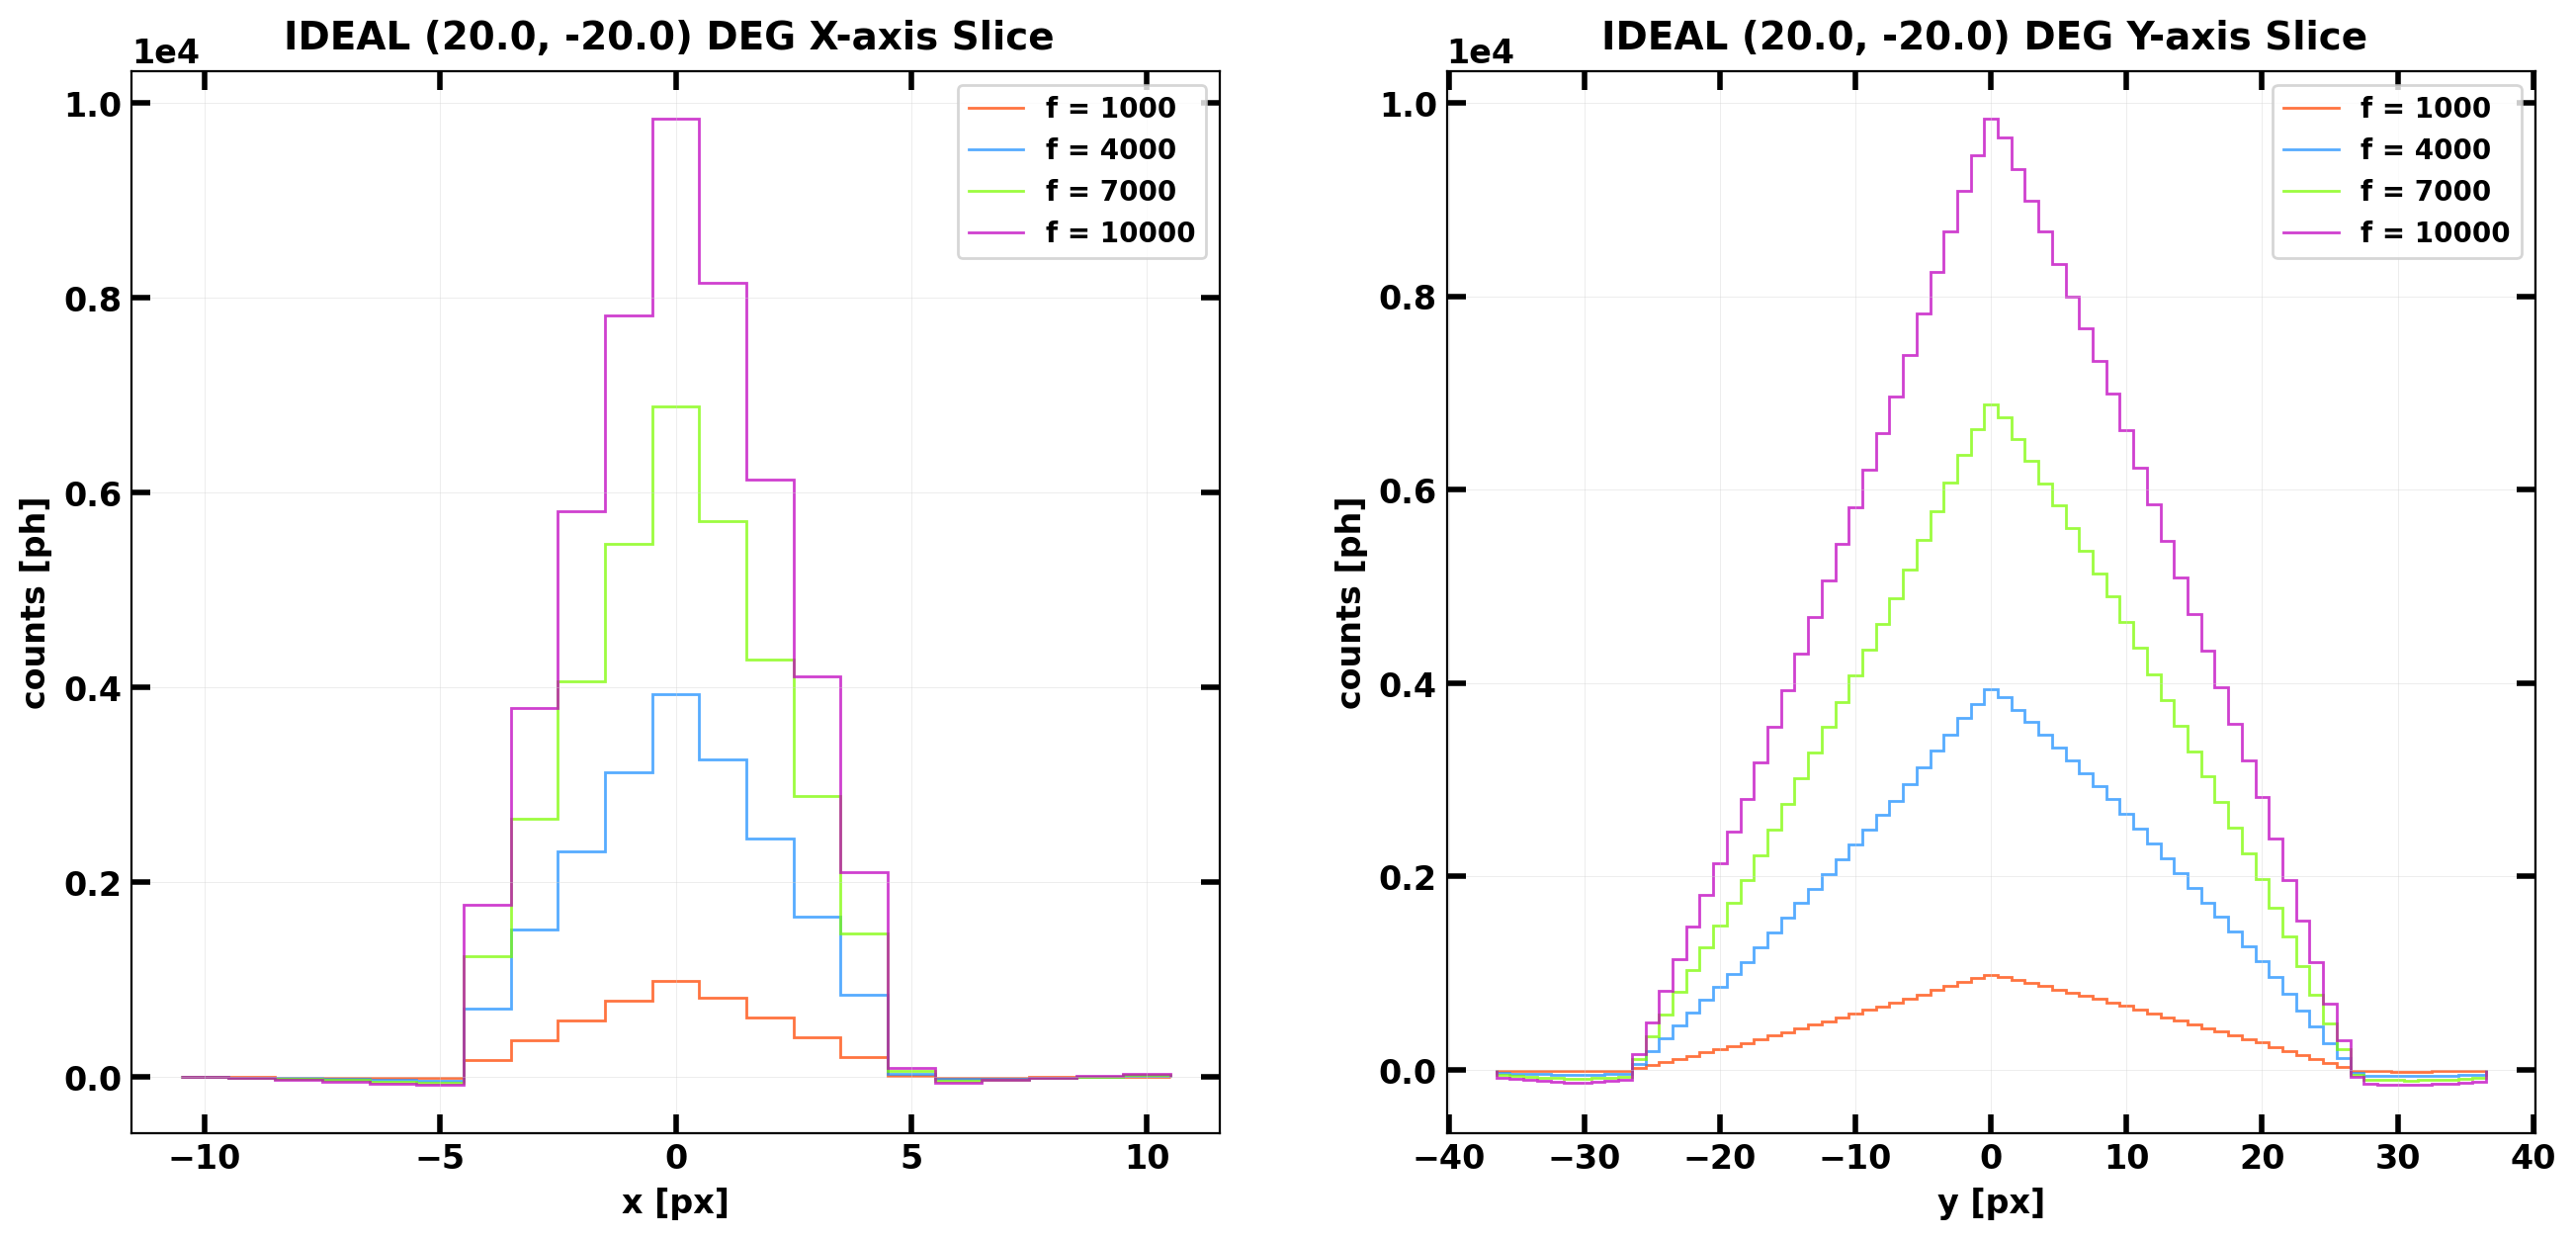

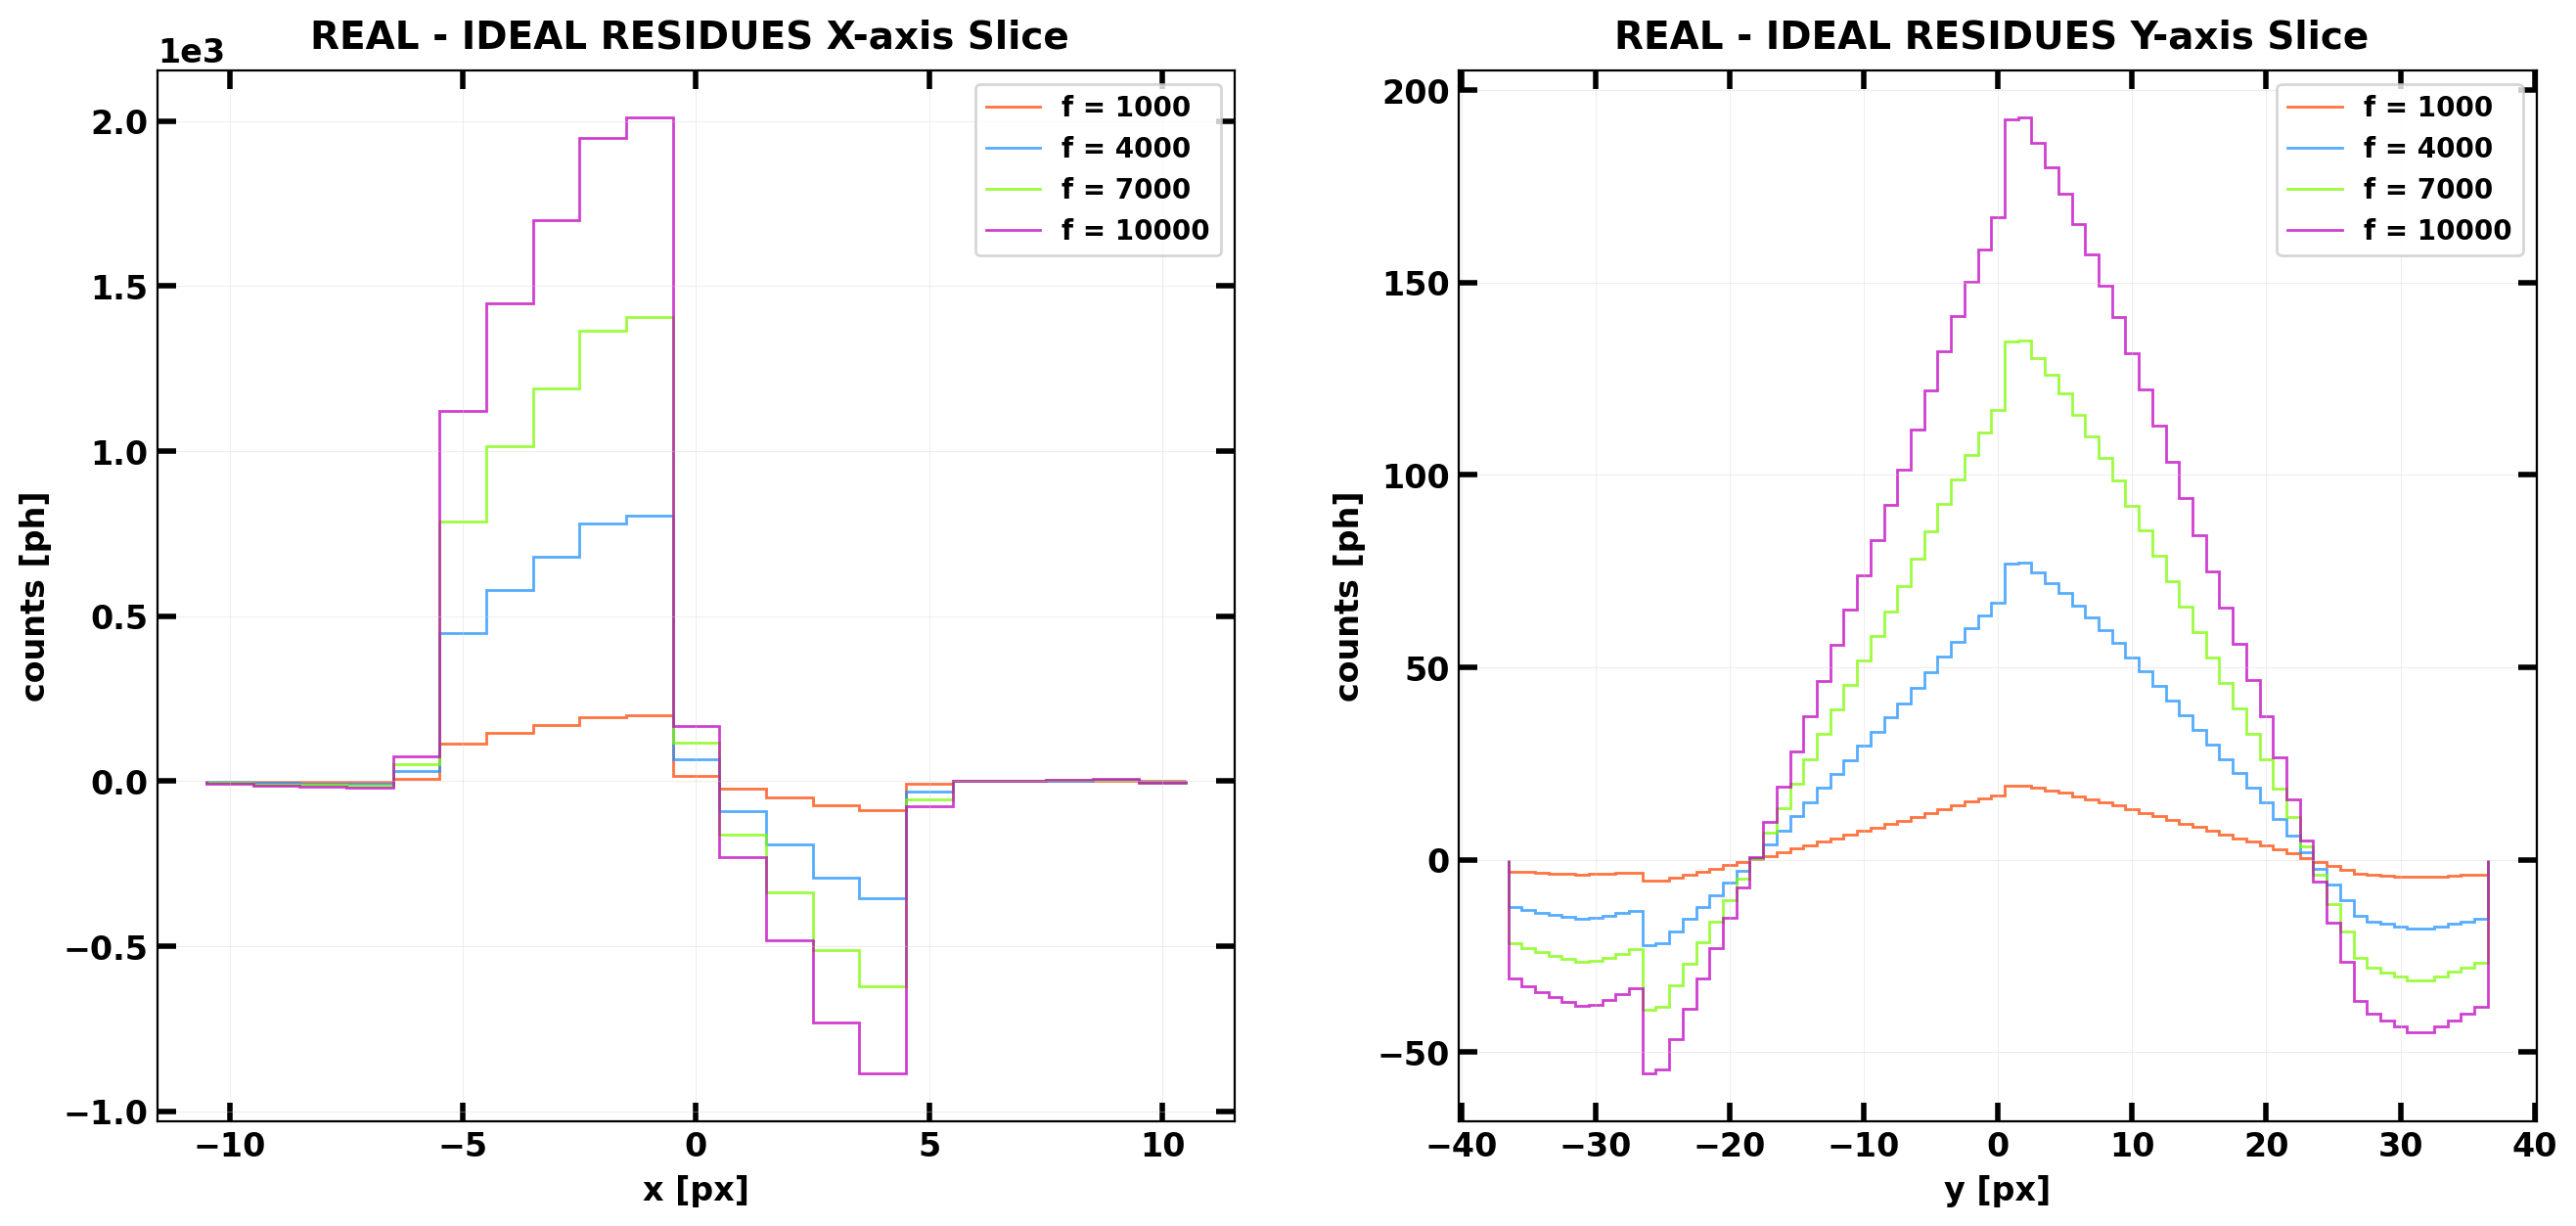

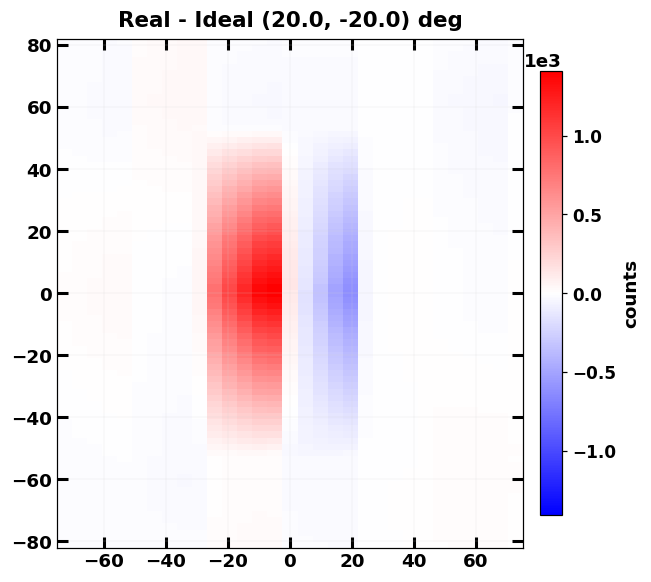

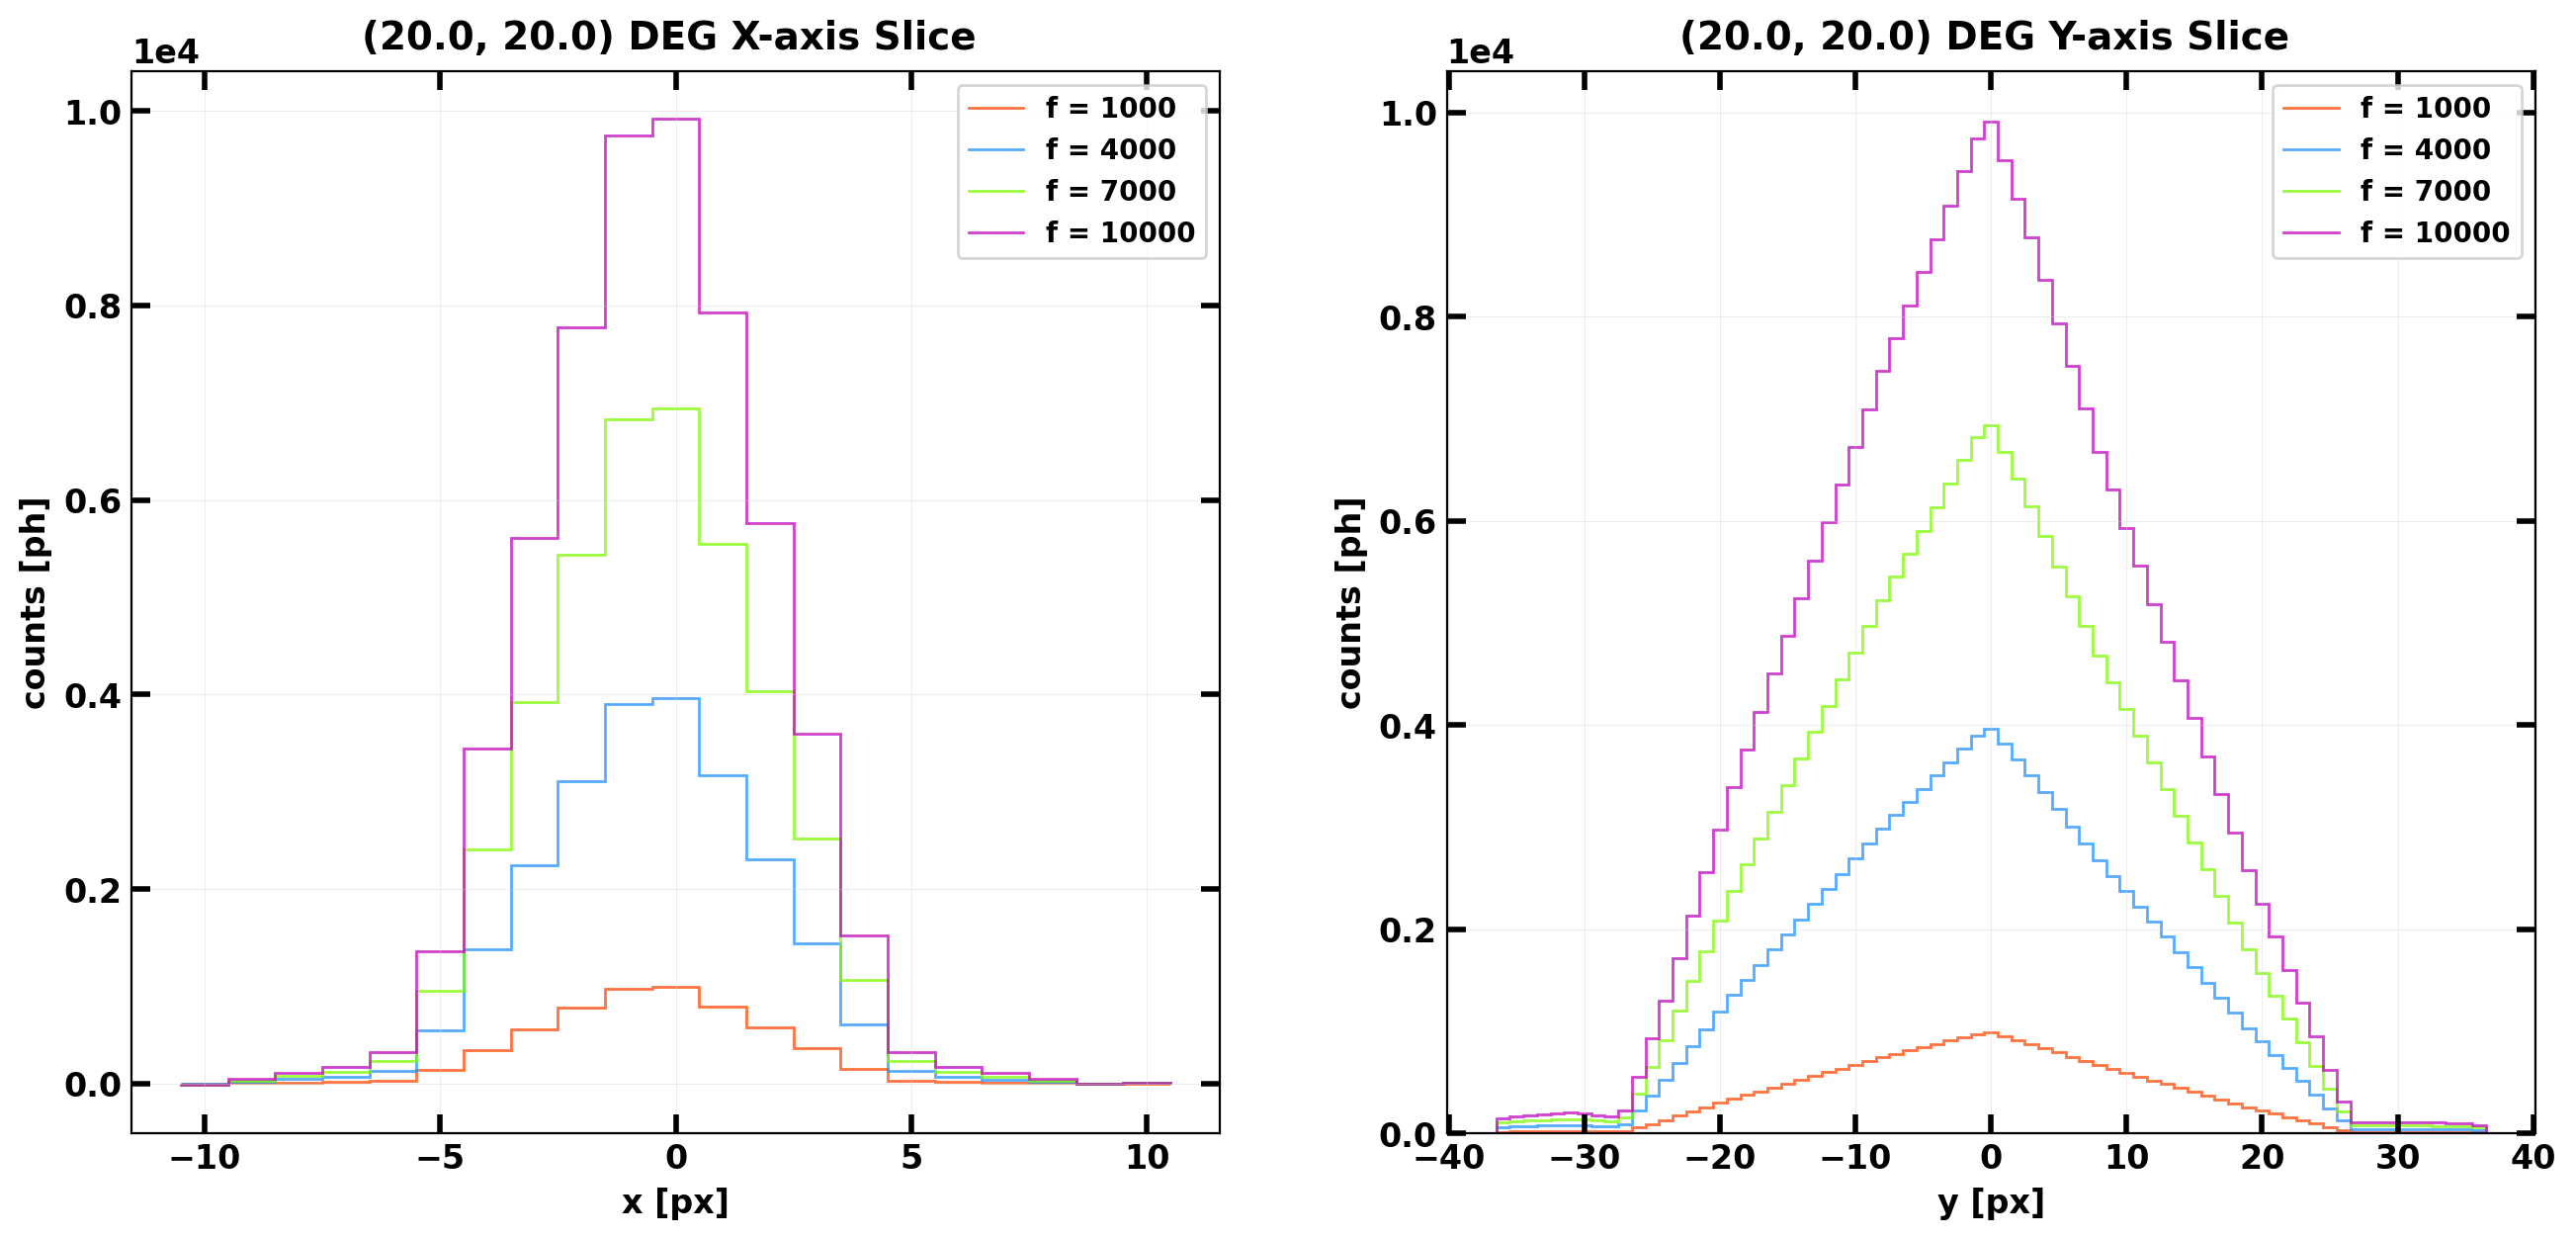

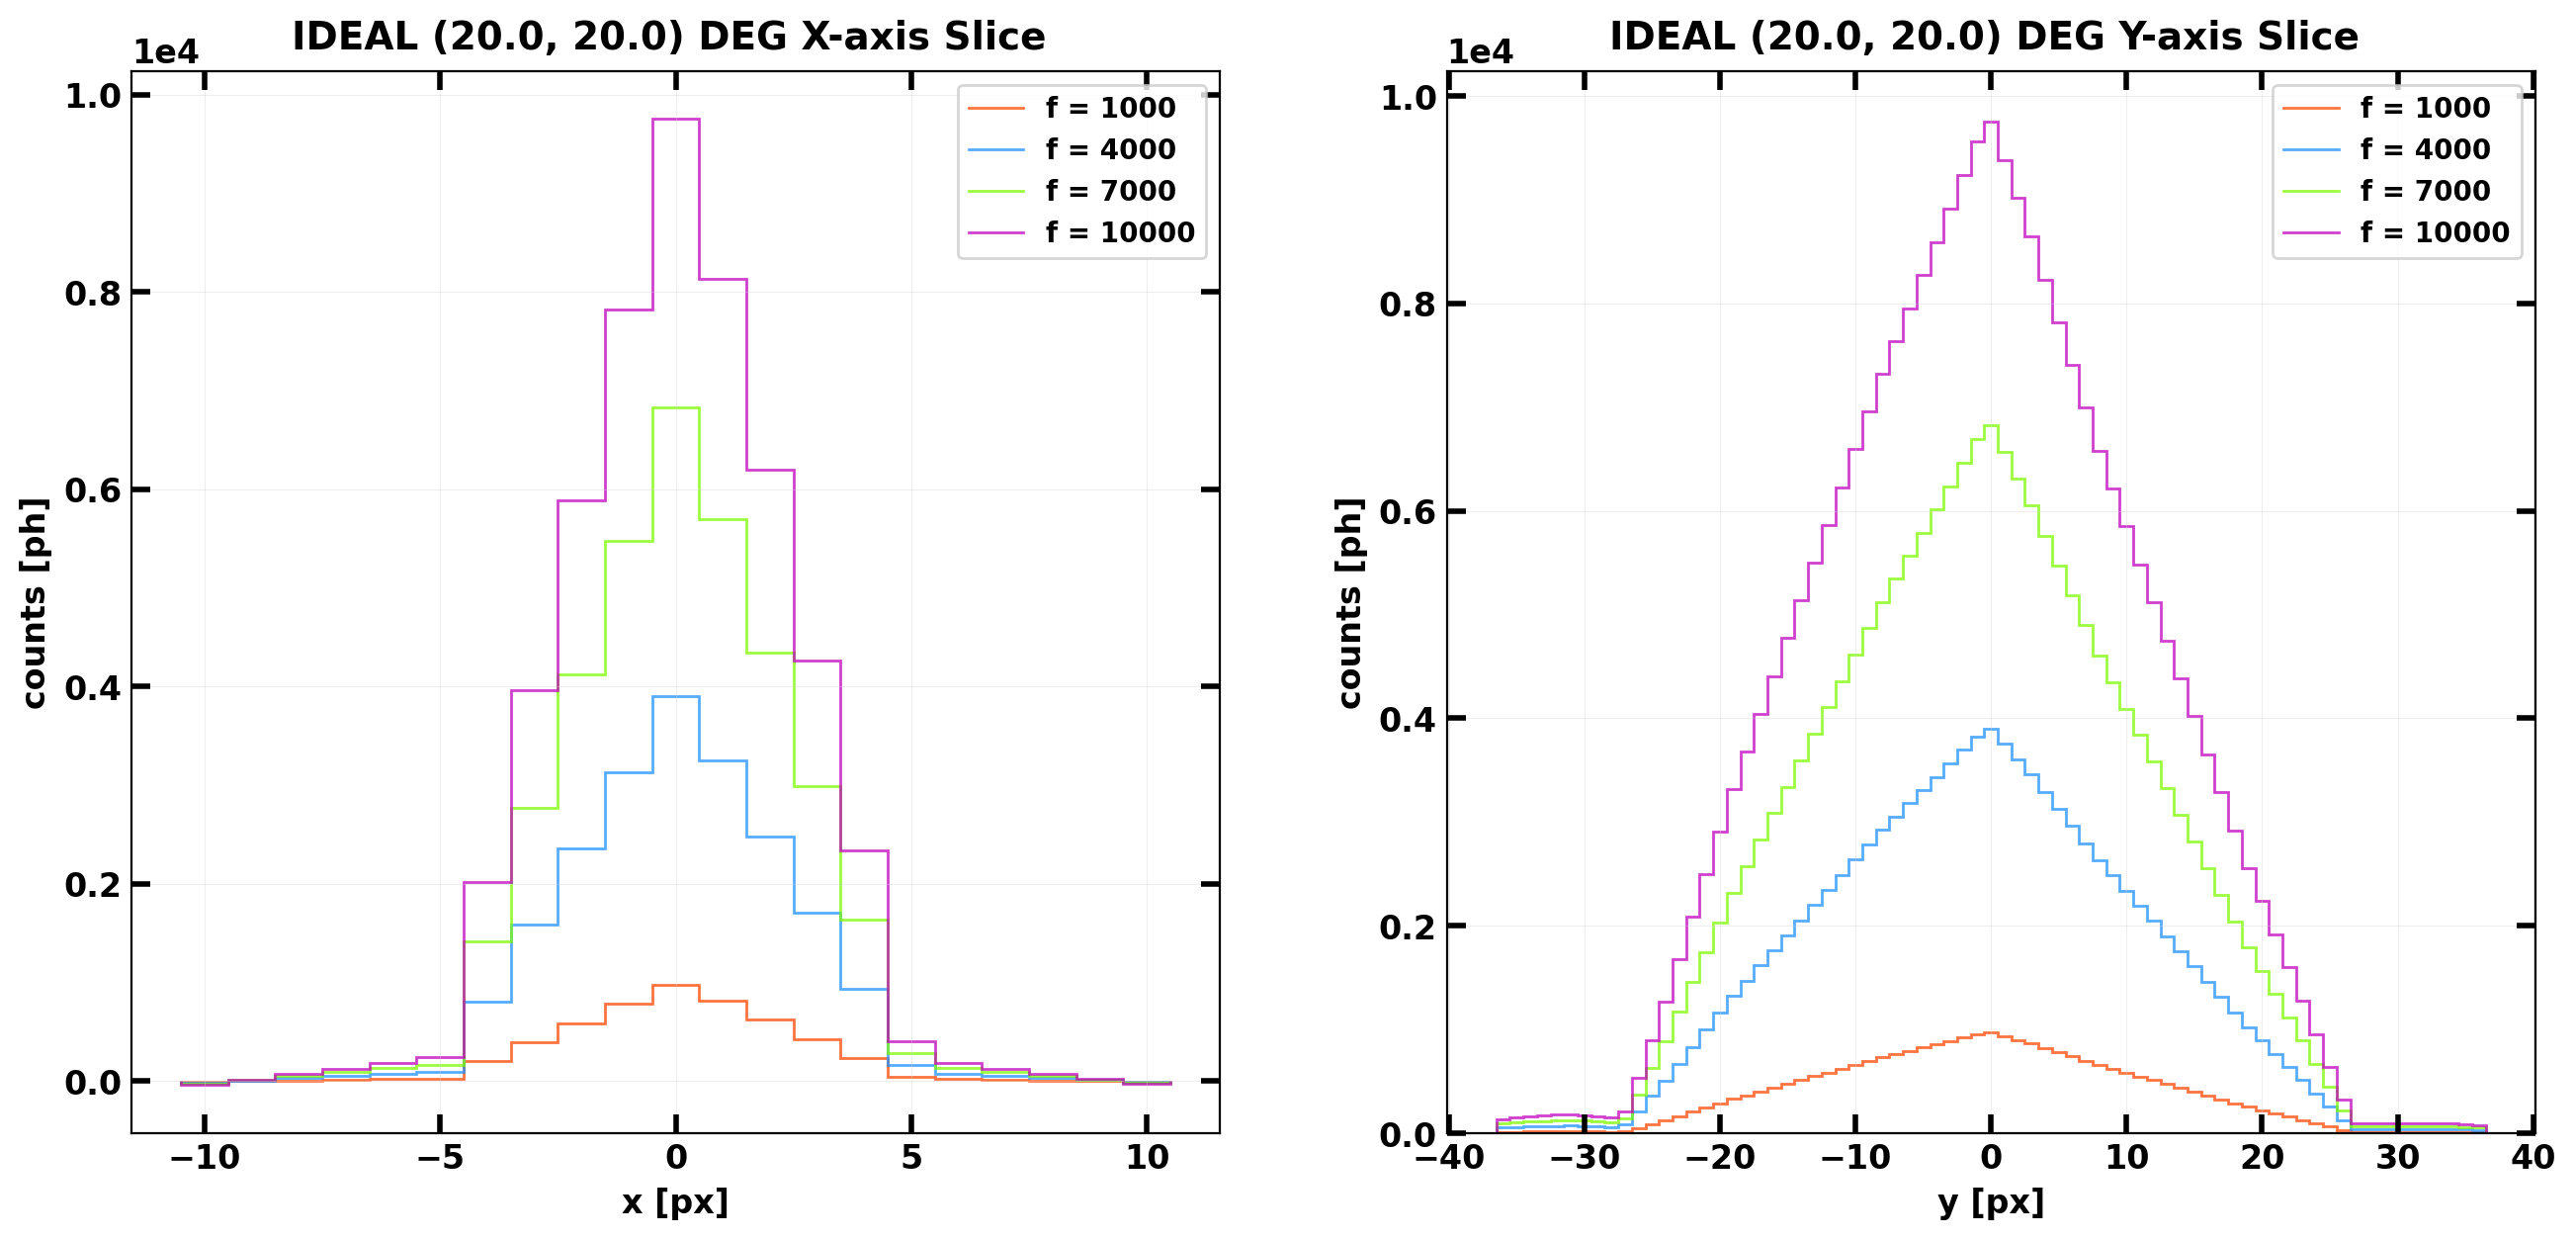

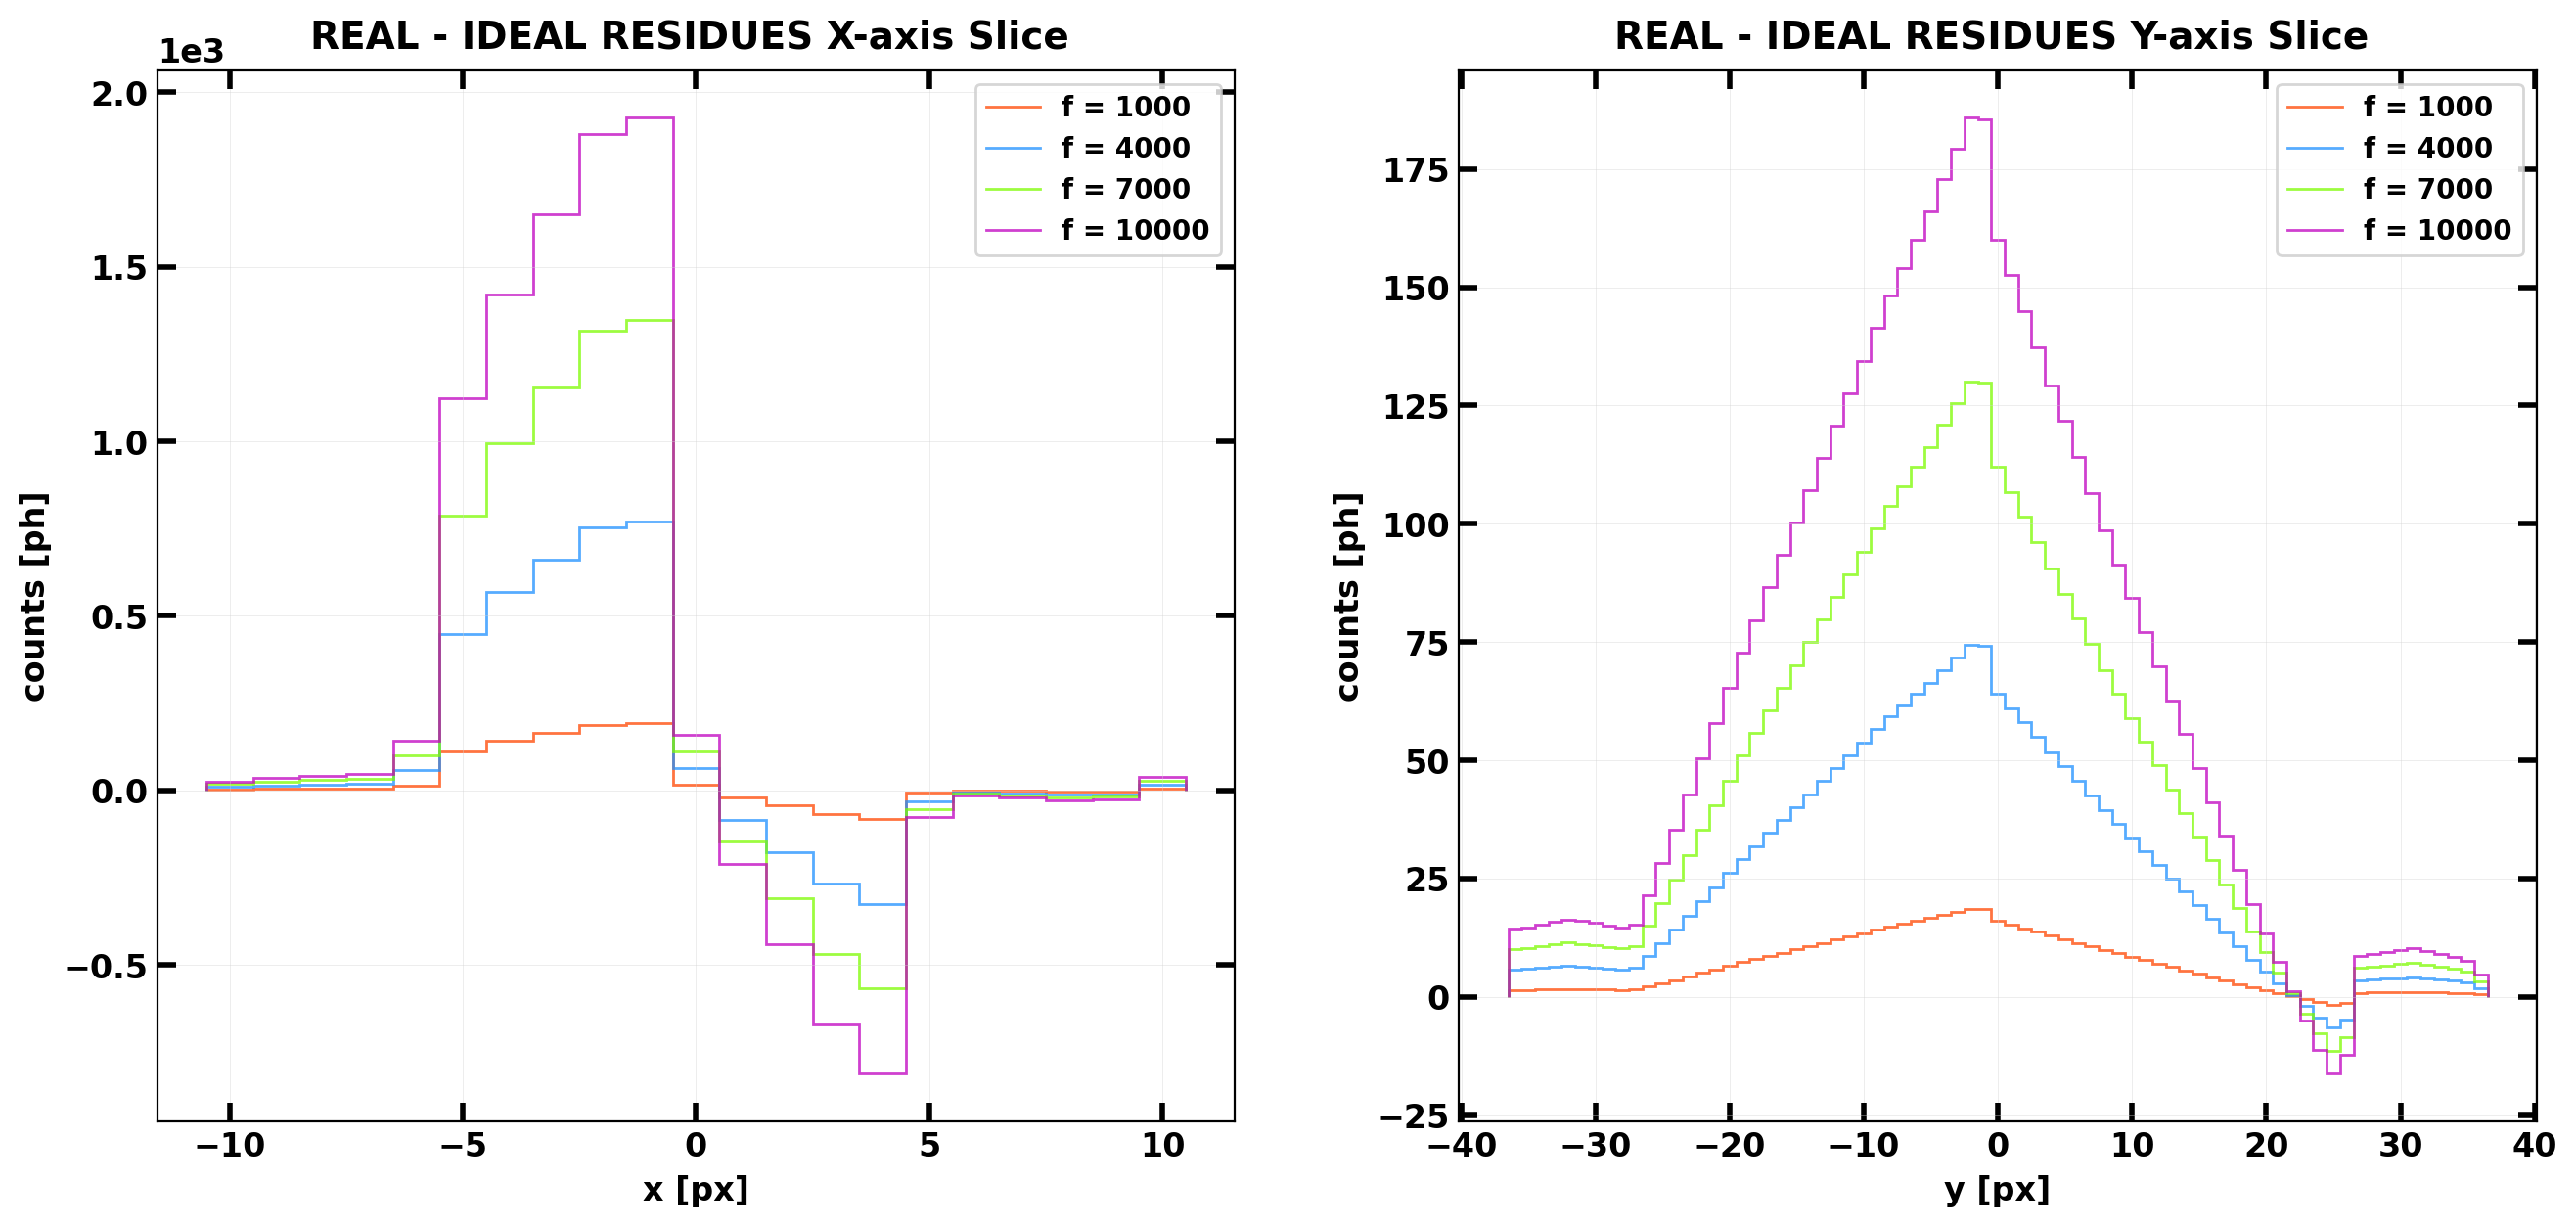

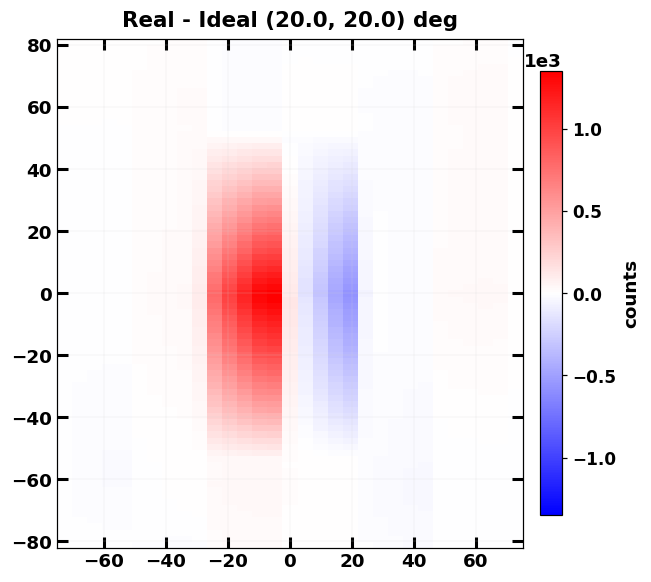

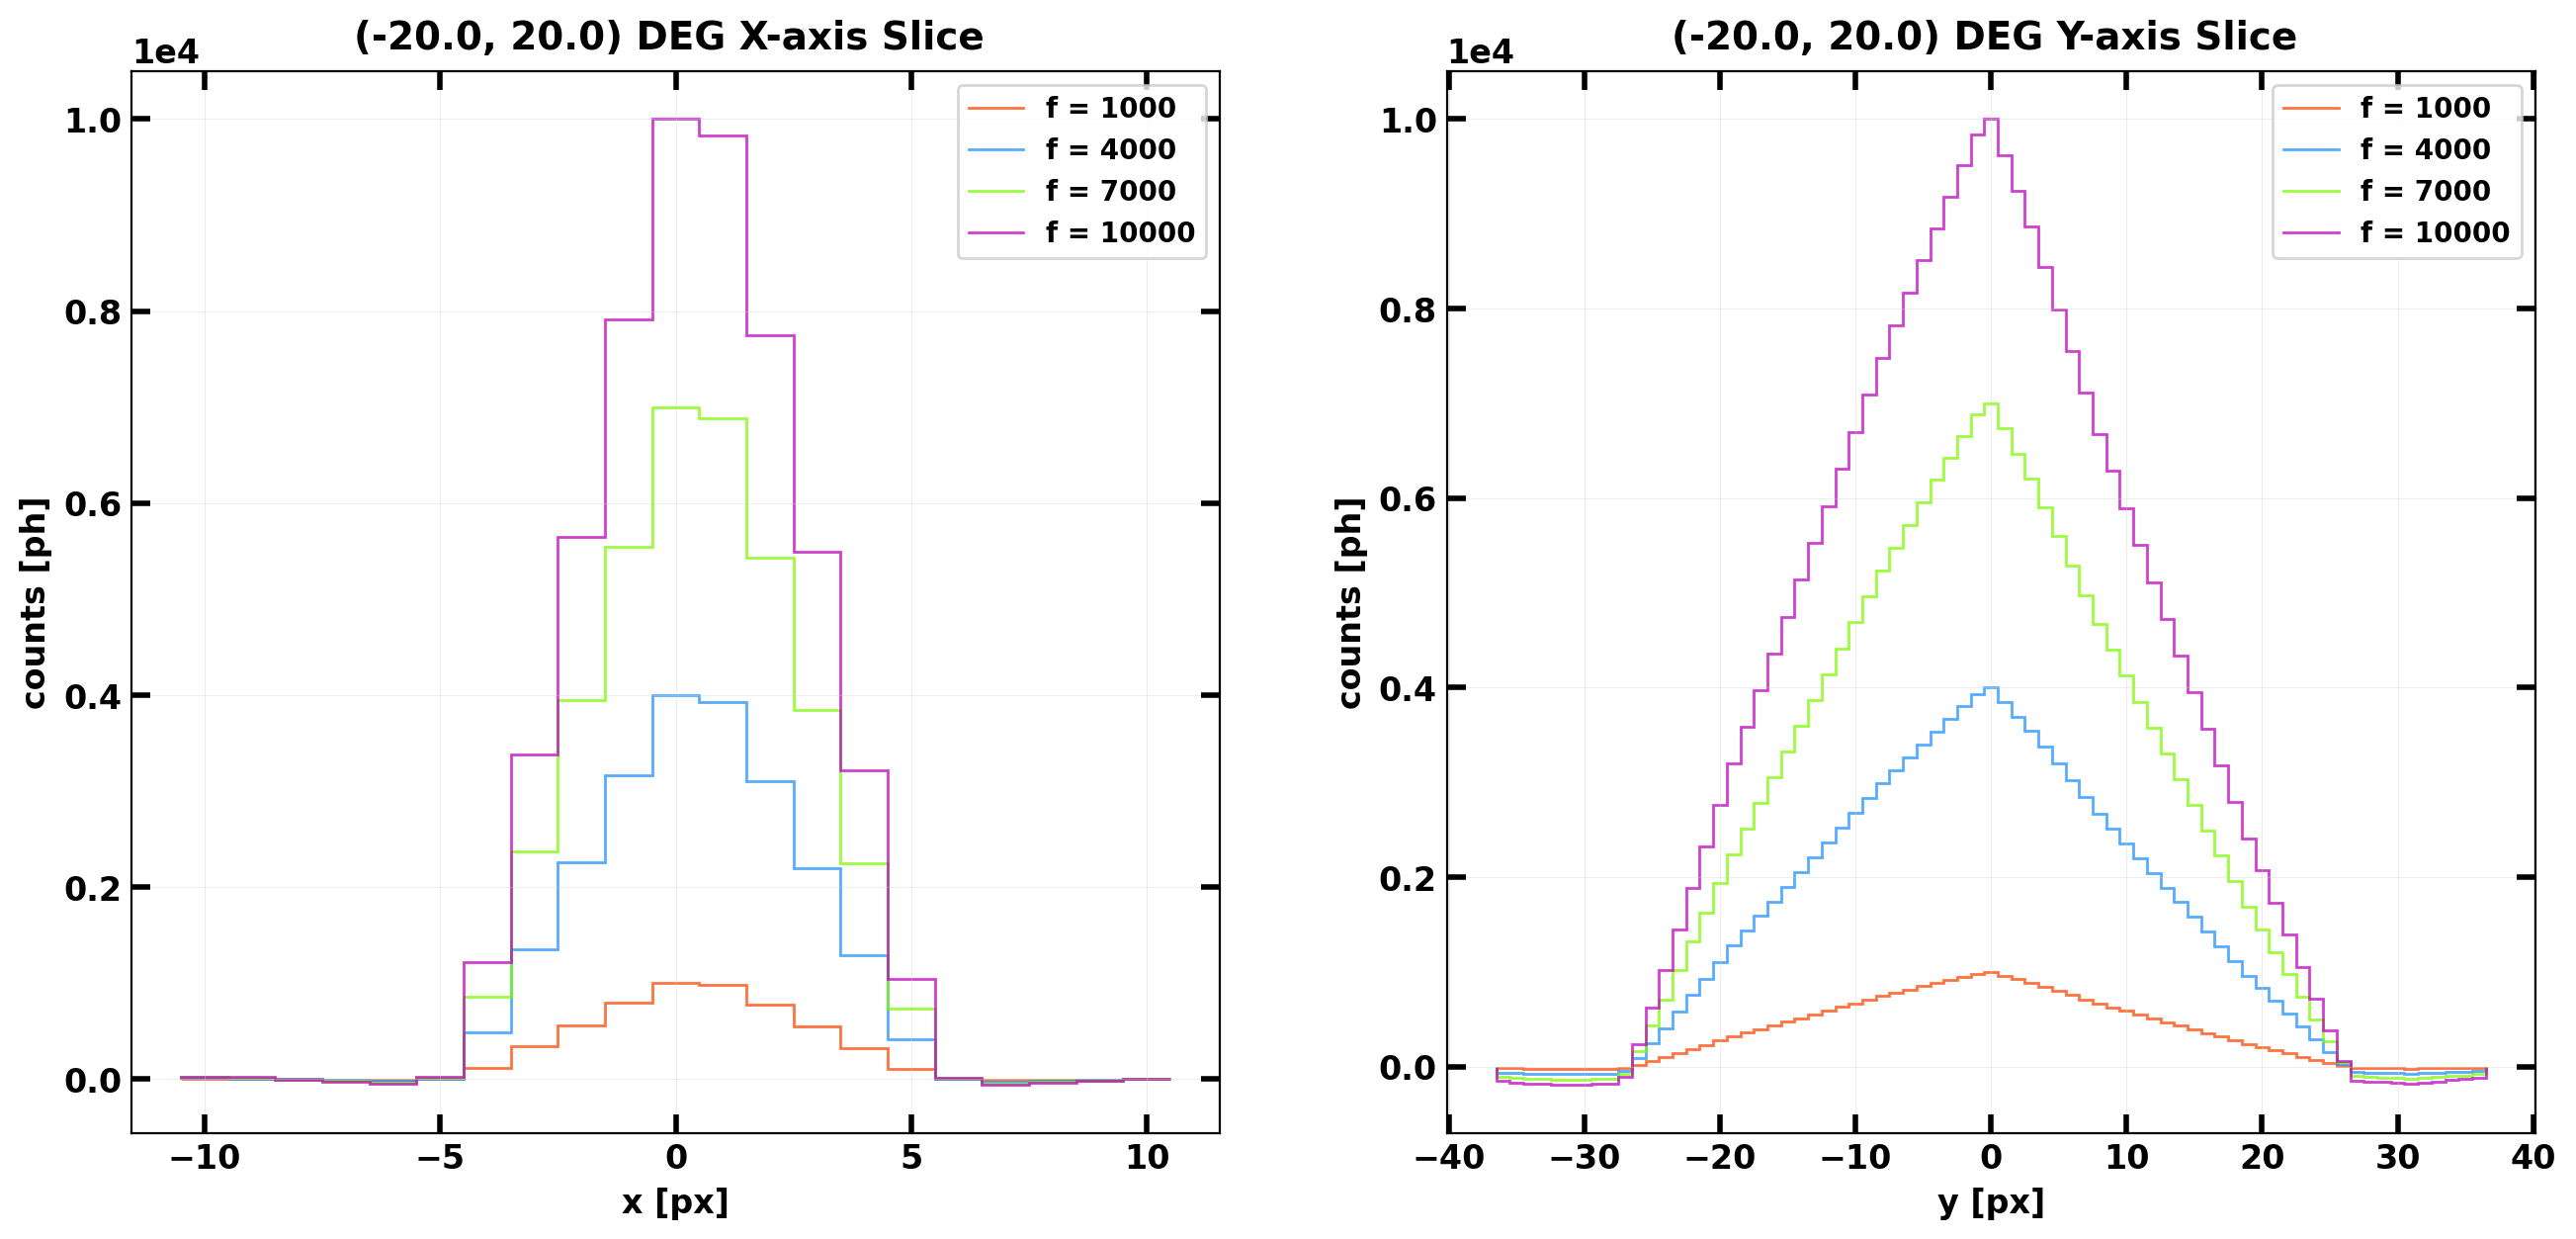

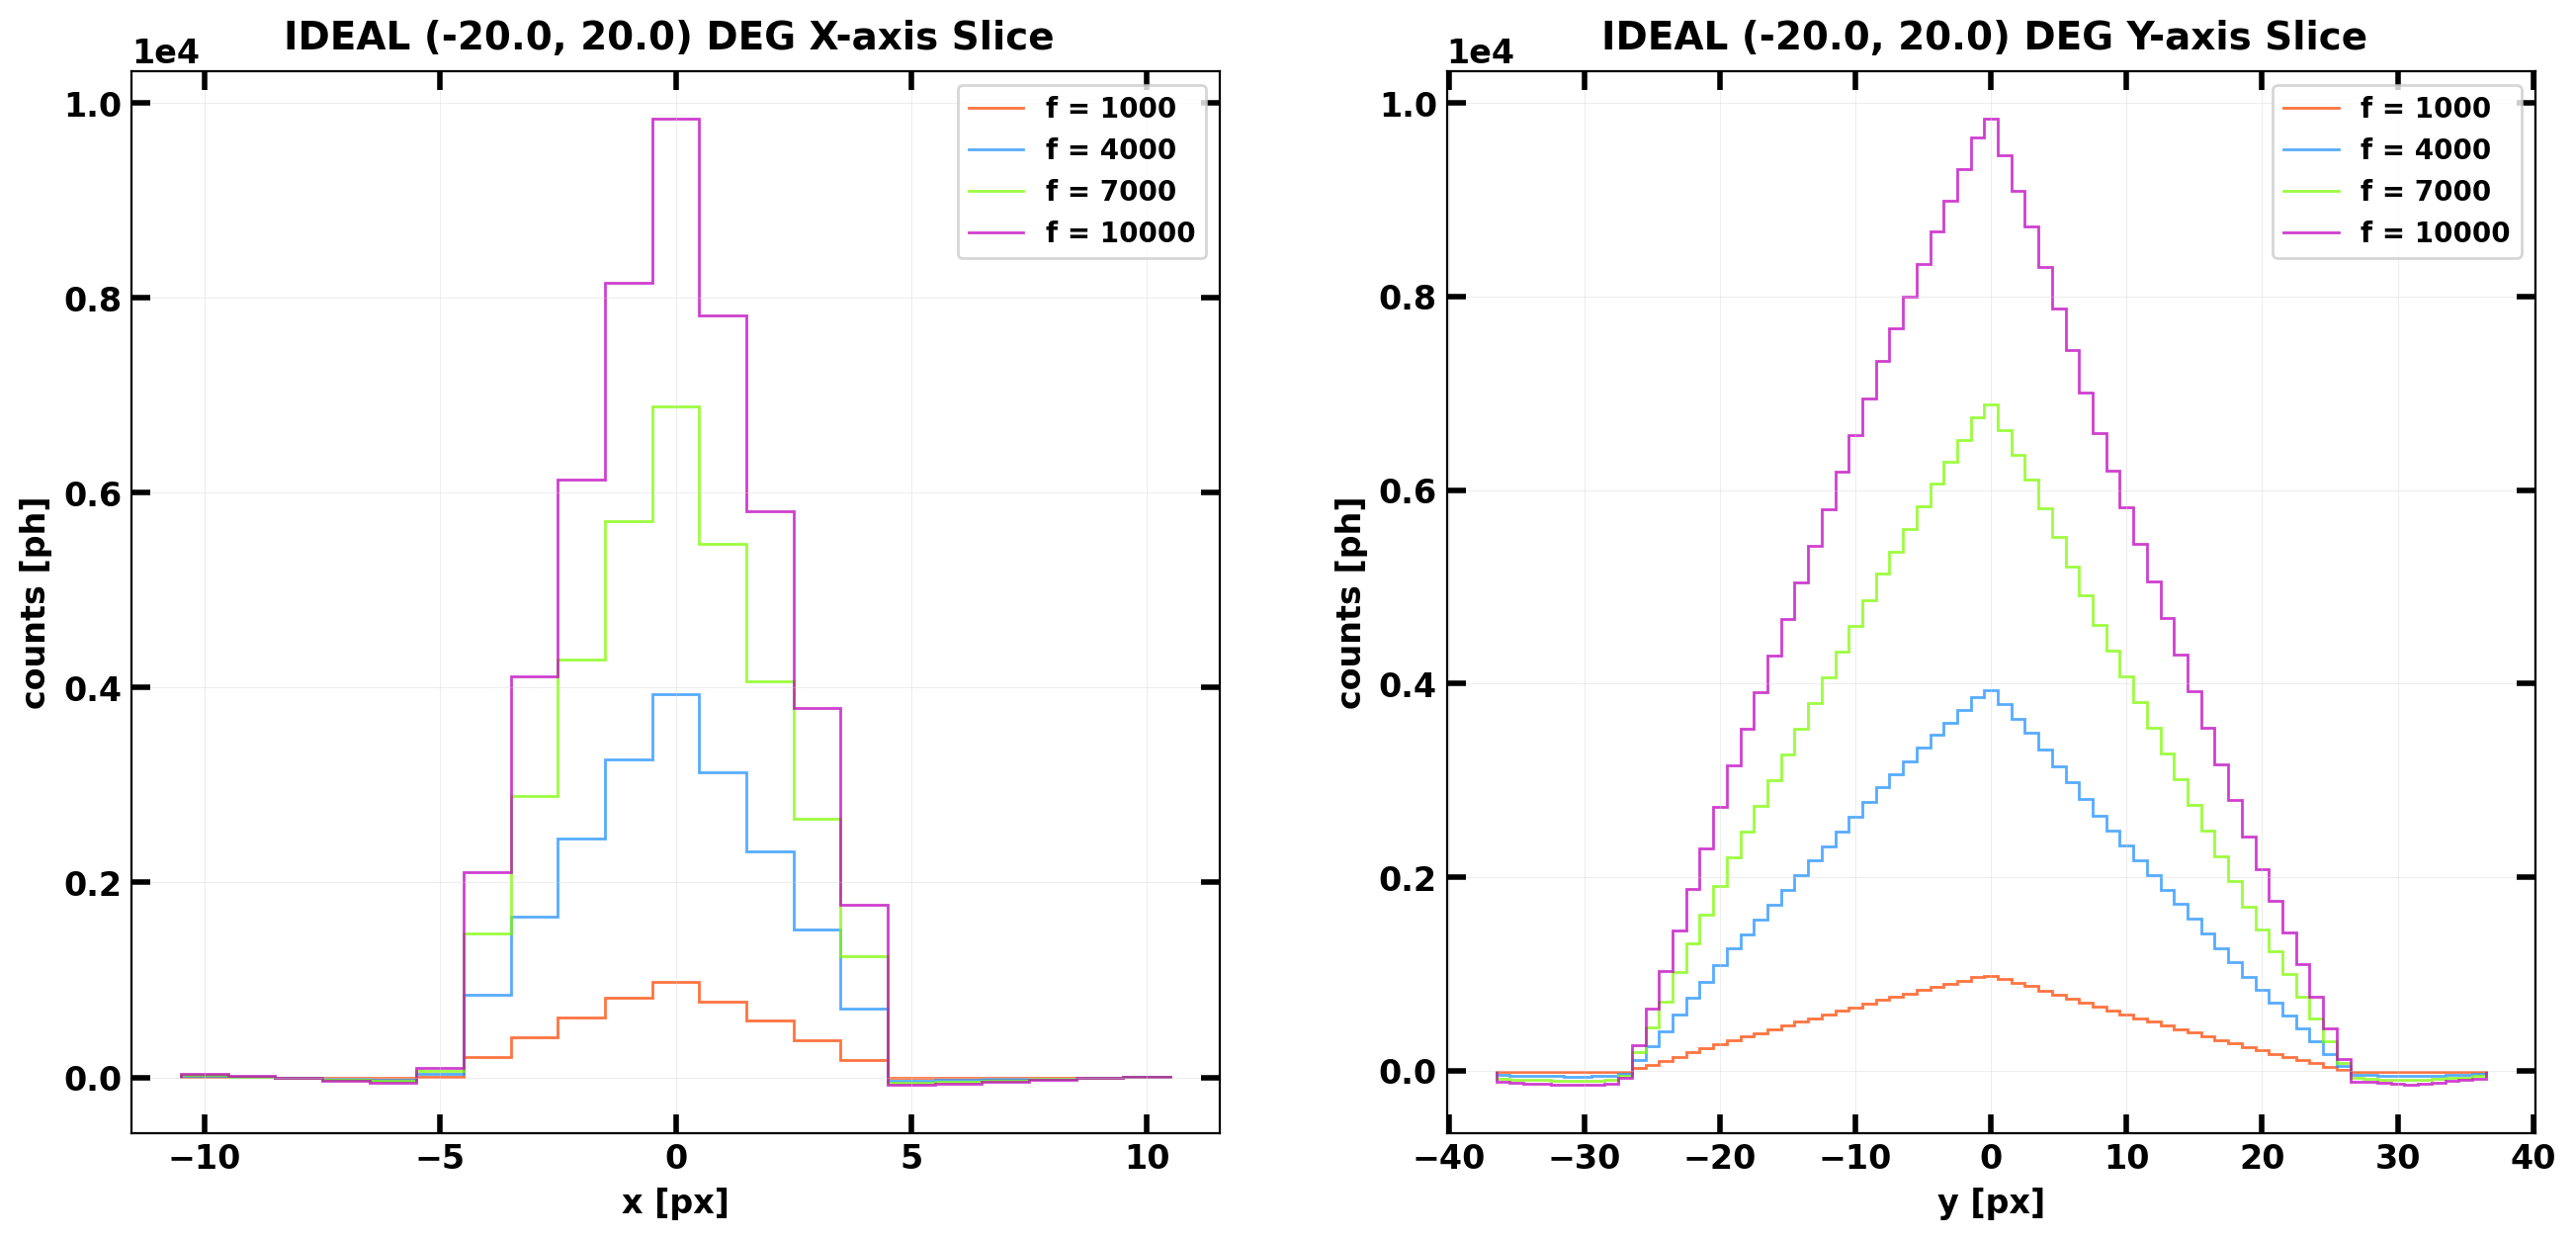

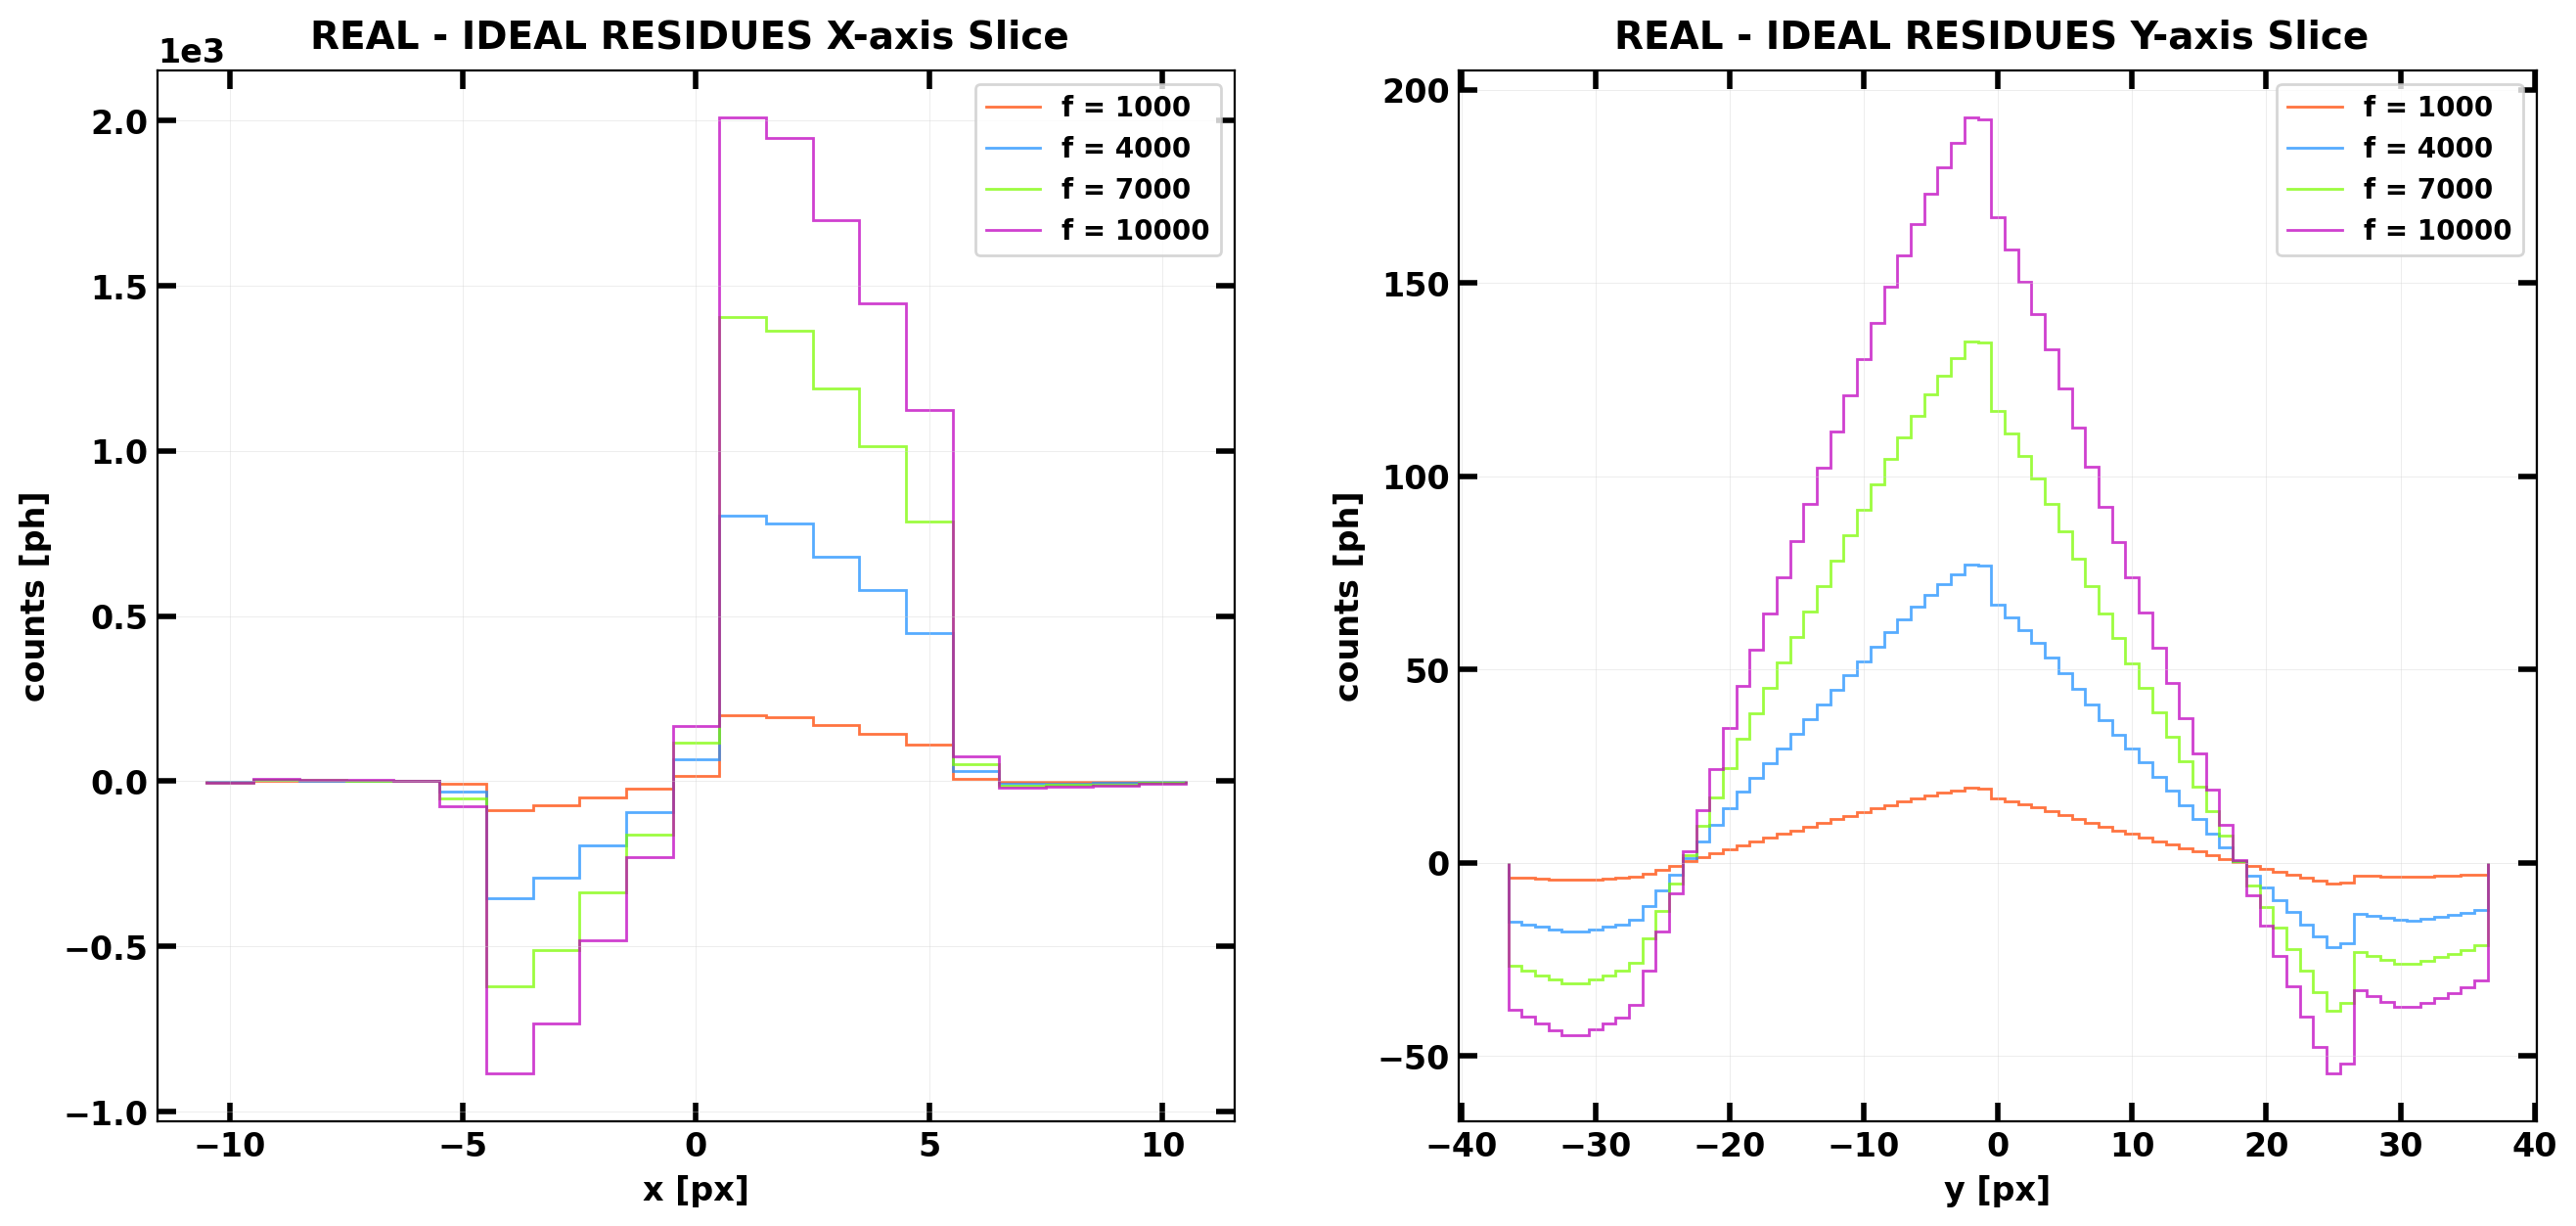

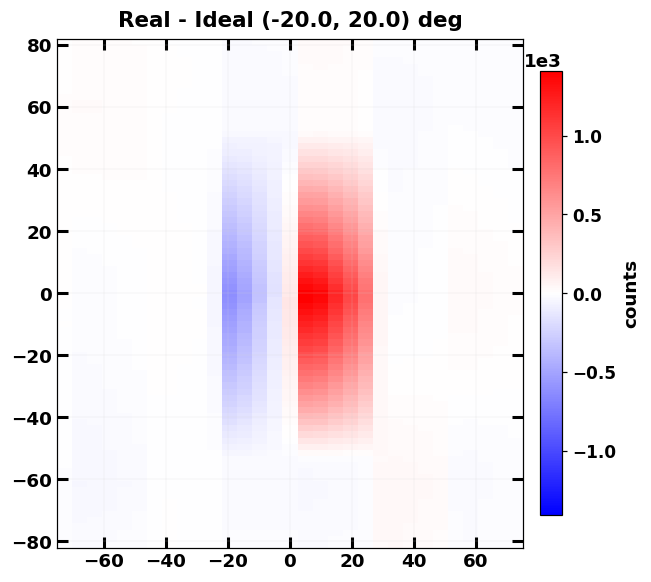

In [1]:
#assert False

#### test source profiles wrt fluence and vignetting effect

from numpy.typing import NDArray
import numpy as np

from bloodmoon.coords import angle2shift, shift2pos
from bloodmoon.mask import CodedMaskCamera, codedmask, decode
#from bloodmoon.optim import model_sky

import darksun as ds

from fract_shift2 import model_shadowgram


def model_sky(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    fluence: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """
    Generate a model of the reconstructed sky image for a point source.
    """
    return decode(camera, model_shadowgram(camera, shift_x, shift_y, vignetting=vignetting, psfy=psfy)) * fluence


def sources_profiles(
    shift_x: float,
    shift_y: float,
    fluence: float | tuple[float, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> tuple[NDArray]:
    """
    Computes sources models for input fluences.
    """
    skies = []
    fluence_ = (fluence,) if isinstance(fluence, float) else fluence

    for f in fluence_:
        sky = model_sky(
            camera, shift_x, shift_y, f, vignetting, psfy,
        )
        skies.append(sky)
    
    return tuple(skies)


mask_path = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask_NTHT_20250725.fits'
#mask_path = '/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask_NTHT_20250725.fits'
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

VIGNETTING = True
PSFY = False

CUT = (
    int(wfm.specs['slit_deltay'] * UPY / wfm.specs['mask_deltay']) + 10,
    int(wfm.specs['slit_deltax'] * UPX / wfm.specs['mask_deltax']) + 10,
)
F_UPY, F_UPX = 2, 5


angles_x, angles_y = (
    (0.0, -20.0, 20.0, 20.0, -20.0),
    (0.0, -20.0, -20.0, 20.0, 20.0),
)

for tx, ty in zip(
    angles_x, angles_y,
):
    shift_x, shift_y = map(
        lambda x: angle2shift(wfm, x),
        (tx, ty),
    )
    fluences = (
        1e3, 4e3, 7e3, 1e4
    )
    #fluences = 1e4
    #print(f'#### Pos (x, y): {tx, ty} deg')
    #print('## Vignetted Skies')
    skies = sources_profiles(shift_x, shift_y, fluences, wfm, VIGNETTING, PSFY)
    #print('\n## Ideal Skies')    
    skies_ideal = sources_profiles(shift_x, shift_y, fluences, wfm, False, False)
    #print('\n\n')

    crp = (
        int(wfm.specs['slit_deltay'] * wfm.upscale_f.y / wfm.specs['mask_deltay'] + 5),
        int(wfm.specs['slit_deltax'] * wfm.upscale_f.x / wfm.specs['mask_deltax'] + 5),
    )
    pos = shift2pos(wfm, shift_x, shift_y)
    tx_, ty_ = map(int, (tx, ty))
    ds.slices_plot(
        sky=skies,
        pos=pos,
        crp=crp,
        source=f'({tx}, {ty}) deg',
        labels=tuple(
            f'f = {int(f)}' for f in fluences
        ),
        #save_to=f'/home/edoardo/Desktop/PSF_test_imgs_new_modelSG/profiles_vignetting{tx_}{ty_}.png',
    )
    ds.slices_plot(
        sky=skies_ideal,
        pos=pos,
        crp=crp,
        source=f'IDEAL ({tx}, {ty}) deg',
        labels=tuple(
            f'f = {int(f)}' for f in fluences
        ),
        #save_to=f'/home/edoardo/Desktop/PSF_test_imgs_new_modelSG/profiles_ideal{tx_}{ty_}.png',
    )
    ds.slices_plot(
        sky=tuple(
            s - s_ideal for s_ideal, s in zip(skies_ideal, skies)
        ),
        pos=pos,
        crp=crp,
        source=f'Real - Ideal Residues',
        labels=tuple(
            f'f = {int(f)}' for f in fluences
        ),
        #save_to=f'/home/edoardo/Desktop/PSF_test_imgs_new_modelSG/profiles_residues{tx_}{ty_}.png',
    )
    
    IDX_ = 2
    vignetted, ideal = map(
        lambda x: ds.crop(x, pos=pos, crp=CUT, strict=False),
        (skies[IDX_], skies_ideal[IDX_]),
    )
    source_res = vignetted - ideal
    LIM = np.max(np.abs(source_res))
    ds.image_plot(
        dmaps=ds.map4image(
            img=ds.upscale(source_res, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'Real - Ideal ({tx}, {ty}) deg',
            cbarlabel='counts',
            img_kwargs={
                'vmin': -LIM,
                'vmax': LIM,
                'cmap': 'bwr',
                'extent': (-CUT[1] * F_UPX, CUT[1] * F_UPX, -CUT[0] * F_UPY, CUT[0] * F_UPY),
            },
        ),
        #save_to=f'/home/edoardo/Desktop/PSF_test_imgs_new_modelSG/HM_residues{tx_}{ty_}.png',
    )